# 基于QRF分布预测的科技类ETF轮动策略 复现笔记

本笔记尝试复现中国银河证券2025年12月发布的研究报告：
**《基于QRF分布预测的科技类ETF轮动策略》**

## 策略概述
1. **数据层**：科技与制造大类行业指数周度收益率 + Fama-French五因子
2. **预测层**：分位数随机森林（QRF）预测各指数未来一周收益率分布
3. **选股层**：基于预测分布构建7个复合指标，选出Top5指数
4. **仓位层**：MACD死叉 + 波动率分位控制整体仓位
5. **优化层**：GARCH标准化残差 + 二阶随机占优（SSD）优化权重
6. **对冲层**：非科技仓位配置华安黄金ETF

## 免责声明
本笔记仅供学习研究，不构成任何投资建议。

## 环境依赖

| 库 | 用途 |
|----|------|
| `pandas` / `numpy` | 数据处理 |
| `quantile-forest` | 分位数随机森林（QRF） |
| `arch` | GARCH模型 |
| `cvxpy` | 二阶随机占优优化（线性规划） |
| `scipy` | 统计工具、分布拟合 |
| `scikit-learn` | 数据预处理、模型评估 |
| `matplotlib` / `seaborn` | 可视化 |
| `tqdm` | 进度条（滚动回归耗时较长） |

安装命令：
```bash
pip install quantile-forest arch cvxpy scipy scikit-learn matplotlib seaborn tqdm pandas numpy
```

In [1]:
pip install quantile-forest arch cvxpy scipy scikit-learn matplotlib seaborn tqdm pandas numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# 基础库
# ============================================================
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 机器学习
# ============================================================
from quantile_forest import RandomForestQuantileRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ============================================================
# 时间序列 / 金融模型
# ============================================================
from arch import arch_model                        # GARCH
from scipy import stats
from scipy.stats import spearmanr, rankdata

# ============================================================
# 优化
# ============================================================
import cvxpy as cp

# ============================================================
# 可视化
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

# ============================================================
# 进度条
# ============================================================
from tqdm import tqdm

# ============================================================
# 版本检查
# ============================================================
print("环境检查：")
print(f"  numpy           : {np.__version__}")
print(f"  pandas          : {pd.__version__}")

import quantile_forest
print(f"  quantile-forest : {quantile_forest.__version__}")

import arch
print(f"  arch            : {arch.__version__}")

import cvxpy
print(f"  cvxpy           : {cvxpy.__version__}")

import sklearn
print(f"  scikit-learn    : {sklearn.__version__}")

print("\n✅ 所有库导入成功")

环境检查：
  numpy           : 2.3.5
  pandas          : 2.3.3
  quantile-forest : 1.4.1
  arch            : 8.0.0
  cvxpy           : 1.9.1
  scikit-learn    : 1.8.0

✅ 所有库导入成功


In [3]:
import os
os.makedirs('plot', exist_ok=True)
PLOT_DIR = 'plot/'

## 全局参数配置

以下参数直接对应报告原文设定，后续所有模块均从此处读取，
修改参数只需改动本单元格。

In [4]:
# ============================================================
# 全局参数配置（对应报告原文）
# ============================================================

# --- 回测区间 ---
BACKTEST_START = '2020-01-02'
BACKTEST_END   = '2025-12-12'

# --- QRF参数 ---
QRF_WINDOW       = 104          # 滚动训练窗口（周）
QRF_QUANTILES    = np.arange(0.05, 1.00, 0.05).tolist()   # 5%~95%，步长5%
QRF_N_ESTIMATORS = 200          # 决策树棵数
QRF_N_SIMULATIONS = 10_000      # 分布模拟抽样次数
QRF_MIN_HISTORY  = 104          # 指数最少上市周数（不足则用最长窗口）

# --- 指数筛选参数 ---
MIN_LISTING_DAYS_SHORT  = 63    # ETF有效性筛选：最短上市交易日
MIN_LISTING_DAYS_LONG   = 273   # 纳入仓位管理：最短上市交易日
MIN_AVG_TURNOVER        = 300   # 万元，近21日日均成交额下限
LOOKBACK_TURNOVER_DAYS  = 21    # 换手率计算窗口（交易日）

# --- 指数选择参数 ---
TOP_N_INDEX      = 5            # 每期选取指数数量
MIN_WEIGHT       = 0.05         # SSD优化中单个ETF最低权重（相对科技总仓位）

# --- MACD参数 ---
MACD_SHORT  = 12
MACD_LONG   = 26
MACD_SIGNAL = 9

# --- 波动率分位参数 ---
VOL_WINDOW        = 252         # 波动率历史分位计算窗口（交易日）
VOL_ROLL_WINDOW   = 21          # 滚动标准差窗口（交易日）
VOL_THRESHOLD     = 0.50        # 波动率分位阈值

# --- SSD优化参数 ---
SSD_N_SIMULATIONS = 500         # 联合分布模拟样本数
SSD_N_GRID        = 10          # 离散化x取值个数
SSD_ITERATIONS    = 3           # 循环优化次数
GARCH_WINDOW      = 8 * 5       # GARCH估计窗口（近8周 × 5交易日）

# --- 交易成本 ---
TRANSACTION_COST  = 0.0003      # 0.03%

# --- 对冲ETF ---
HEDGE_ETF_CODE    = '518880.SH' # 华安黄金ETF

# --- 复合指标权重（对应表10）---
INDICATOR_WEIGHTS = {
    'quantile_50'  : 1,
    'quantile_75'  : 1,
    'mean_return'  : 1,
    'sharpe'       : 2,
    'sortino'      : 1,
    'omega'        : 1,
    'win_rate'     : 1,
}

print("✅ 全局参数配置完成")
print(f"   回测区间  : {BACKTEST_START} → {BACKTEST_END}")
print(f"   QRF窗口  : {QRF_WINDOW} 周")
print(f"   分位点数量: {len(QRF_QUANTILES)} 个（{QRF_QUANTILES[0]:.0%} ~ {QRF_QUANTILES[-1]:.0%}）")
print(f"   每期选指数: Top {TOP_N_INDEX}")

✅ 全局参数配置完成
   回测区间  : 2020-01-02 → 2025-12-12
   QRF窗口  : 104 周
   分位点数量: 19 个（5% ~ 95%）
   每期选指数: Top 5


## 第一部分：数据层

本策略需要以下几类数据：

| 数据类型 | 来源 | 频率 | 说明 |
|---------|------|------|------|
| 科技与制造大类行业指数收盘价 | Wind | 日频 | 共111支，用于计算周度收益率、波动率、MACD |
| 科技与制造大类ETF收盘价 | Wind | 日频 | 每支指数对应多个ETF，选近21日均换收益率最大者 |
| ETF日均成交额 | Wind | 日频 | 用于筛选有效ETF（近21日日均 > 300万元） |
| Fama-French五因子 | 自行计算 / Wind | 日频→周频 | MKT, SMB, HML, RMW, CMA |
| 指数-ETF映射关系 | Wind | 静态 | 每支指数追踪哪些ETF，以及行业归属 |

### Wind提取字段参考
- 指数收盘价：`w.wsd(code, "close", start, end)`
- ETF收盘价 + 成交额：`w.wsd(code, "close,amt", start, end)`
- 指数成分股（用于计算FF因子）：`w.wset("sectorconstituent", ...)`
- 个股市值、PB、营业利润、ROE：`w.wsd(code, "mkt_cap_ard,pb_lf,ebit,roe", ...)`

## 数据清洗（待补充）

> ⚠️ 本节在Wind账号开通后补充完整，以下为清洗逻辑的占位框架。

### 指数收盘价清洗
- 剔除上市不足1个交易日的数据点
- 前向填充（ffill）处理停牌/节假日缺失值
- 对齐所有指数的日期索引（取交集或并集，缺失用NaN标记）

### ETF成交额清洗
- 单位统一（Wind返回单位为元，需转换为万元）
- 剔除成交额为0或异常值的交易日
- 计算近21日滚动日均成交额

### Fama-French五因子清洗
- 剔除风险警示板（ST/*ST）股票
- 剔除最近报告期每股净利润为负的股票
- 缺失财务数据的个股从当期截面剔除
- 因子值做3σ截尾处理，防止极端值污染

### 行业分类清洗
- 核对每支ETF追踪指数的行业归属（按报告分类方法）
- 每年6月和12月底重新分类，记录分类变更时间节点

### 周频数据对齐
- 以每周最后一个交易日收盘价计算周度收益率
- FF五因子日频值在每周内加总得到周频因子收益率
- 确保指数收益率与因子数据在时间轴上严格对齐（Y_{t+1} 对应 X_t）

## 模拟数据生成（Wind开通前占位）

在Wind数据到位之前，我们生成结构完全一致的模拟数据，
确保后续所有模块的代码逻辑可以完整运行和调试。

模拟数据的设计原则：
- **数据结构**与真实数据完全一致（列名、索引、数据类型）
- **统计特性**尽量贴近真实市场（科技股高波动、因子间相关性等）
- **指数数量**：使用30支模拟指数（真实为111支，缩减以节省运行时间）
- **时间范围**：与全局参数保持一致（2020-01-02 至 2025-12-12）

In [5]:
# ============================================================
# 模拟数据 Part 1：指数基础信息表
# ============================================================

np.random.seed(42)

# 模拟30支科技与制造大类行业指数
N_INDEX = 30

# 中信一级行业（对应科技与制造大类）
CITIC_L1 = ['电子', '通信', '计算机', '电力设备及新能源', '机械', '汽车', '国防军工', '建材']

# 模拟指数代码和名称
index_codes = [f'{800001 + i}.CSI' for i in range(N_INDEX)]
index_names = (
    ['半导体主题', '消费电子主题', '芯片设计', '光电子主题', '电子元器件主题'] +
    ['5G通信', '通信设备主题', '卫星通信', '通信基础设施', '物联网主题'] +
    ['软件开发', '云计算主题', '人工智能', '大数据产业', '金融科技'] +
    ['光伏产业', '新能源车电池', '电网设备主题', '储能主题', '创业板新能源'] +
    ['工程机械主题', '机器人产业', '高端制造', '工业自动化', '精密仪器'] +
    ['新能源汽车', '汽车零部件', '军工龙头', '航空航天', '建筑材料']
)

# 行业归属
citic_l1_mapping = (
    ['电子'] * 5 +
    ['通信'] * 5 +
    ['计算机'] * 5 +
    ['电力设备及新能源'] * 5 +
    ['机械'] * 5 +
    ['汽车'] * 2 + ['国防军工'] * 2 + ['建材'] * 1
)

# 模拟上市日期（部分指数上市较晚，测试动态筛选逻辑）
listing_dates = pd.to_datetime(
    ['2018-01-01'] * 15 +          # 早期上市
    ['2019-06-01'] * 8  +          # 中期上市
    ['2021-03-01'] * 4  +          # 较晚上市（QRF窗口不足104周）
    ['2022-09-01'] * 3             # 最晚上市
)

index_info = pd.DataFrame({
    'index_code'   : index_codes,
    'index_name'   : index_names,
    'citic_l1'     : citic_l1_mapping,
    'listing_date' : listing_dates,
})

index_info.set_index('index_code', inplace=True)

print(f"✅ 指数基础信息表生成完毕：{len(index_info)} 支指数")
print(index_info.head(10))

✅ 指数基础信息表生成完毕：30 支指数
           index_name citic_l1 listing_date
index_code                                 
800001.CSI      半导体主题       电子   2018-01-01
800002.CSI     消费电子主题       电子   2018-01-01
800003.CSI       芯片设计       电子   2018-01-01
800004.CSI      光电子主题       电子   2018-01-01
800005.CSI    电子元器件主题       电子   2018-01-01
800006.CSI       5G通信       通信   2018-01-01
800007.CSI     通信设备主题       通信   2018-01-01
800008.CSI       卫星通信       通信   2018-01-01
800009.CSI     通信基础设施       通信   2018-01-01
800010.CSI      物联网主题       通信   2018-01-01


In [6]:
# ============================================================
# 模拟数据 Part 2：日频收盘价
# ============================================================

# 生成交易日历（剔除周末，不处理节假日）
all_dates = pd.bdate_range(start='2018-01-01', end=BACKTEST_END)

# 每支指数用GBM（几何布朗运动）模拟价格序列
# 科技股参数：年化波动率约35%~55%，年化漂移约5%~25%

def simulate_price_gbm(n_days, mu_annual=0.10, sigma_annual=0.40,
                        s0=1000.0, seed=None):
    """几何布朗运动模拟价格序列"""
    if seed is not None:
        np.random.seed(seed)
    dt = 1 / 252
    daily_returns = np.random.normal(
        loc   = (mu_annual - 0.5 * sigma_annual**2) * dt,
        scale = sigma_annual * np.sqrt(dt),
        size  = n_days
    )
    prices = s0 * np.exp(np.cumsum(daily_returns))
    prices = np.insert(prices, 0, s0)[:-1]
    return prices

price_dict = {}
for i, code in enumerate(index_codes):
    mu    = np.random.uniform(0.05, 0.20)
    sigma = np.random.uniform(0.30, 0.55)   # 科技股高波动
    prices = simulate_price_gbm(
        n_days=len(all_dates),
        mu_annual=mu,
        sigma_annual=sigma,
        s0=np.random.uniform(500, 2000),
        seed=i
    )
    price_dict[code] = prices

index_price_daily = pd.DataFrame(price_dict, index=all_dates)

# 只保留各指数上市日期之后的数据（上市前设为NaN）
for code in index_codes:
    listing = index_info.loc[code, 'listing_date']
    index_price_daily.loc[index_price_daily.index < listing, code] = np.nan

print(f"✅ 日频收盘价生成完毕")
print(f"   日期范围 : {index_price_daily.index[0].date()} → {index_price_daily.index[-1].date()}")
print(f"   指数数量 : {index_price_daily.shape[1]}")
print(f"   数据形状 : {index_price_daily.shape}")
print(index_price_daily.iloc[:3, :5])

✅ 日频收盘价生成完毕
   日期范围 : 2018-01-01 → 2025-12-12
   指数数量 : 30
   数据形状 : (2075, 30)
             800001.CSI   800002.CSI   800003.CSI   800004.CSI   800005.CSI
2018-01-01  1597.990913  1370.120396  1496.226223   981.259178  1725.929901
2018-01-02  1696.121814  1427.602168  1475.541714  1040.297313  1728.235137
2018-01-03  1719.005036  1406.552965  1472.806579  1055.034128  1752.151117


In [7]:
# ============================================================
# 模拟数据 Part 3：Fama-French五因子（日频 + 周频）
# ============================================================

def simulate_ff_factors(dates, seed=99):
    """
    模拟日频FF五因子收益率
    参数参考A股实证研究中的典型统计特征：
      MKT: 均值略正，波动最大
      SMB: 均值接近0，中等波动
      HML: 近3年表现较好（报告图14）
      RMW: 表现最差（报告图14）
      CMA: 中等
    """
    np.random.seed(seed)
    n = len(dates)

    # 因子间相关矩阵（简化设定）
    corr = np.array([
        [1.00,  0.30,  0.10,  0.05,  0.05],
        [0.30,  1.00,  0.05,  0.10,  0.00],
        [0.10,  0.05,  1.00, -0.20,  0.10],
        [0.05,  0.10, -0.20,  1.00, -0.05],
        [0.05,  0.00,  0.10, -0.05,  1.00],
    ])
    L = np.linalg.cholesky(corr)

    # 日频参数
    params = {
        'MKT': {'mu': 0.0003, 'sigma': 0.012},
        'SMB': {'mu': 0.0001, 'sigma': 0.006},
        'HML': {'mu': 0.0004, 'sigma': 0.005},
        'RMW': {'mu': 0.0000, 'sigma': 0.004},
        'CMA': {'mu': 0.0002, 'sigma': 0.004},
    }
    factor_names = list(params.keys())

    # 生成相关随机数
    Z = np.random.randn(n, 5) @ L.T

    factor_daily = {}
    for j, name in enumerate(factor_names):
        mu    = params[name]['mu']
        sigma = params[name]['sigma']
        factor_daily[name] = mu + sigma * Z[:, j]

    ff_daily = pd.DataFrame(factor_daily, index=dates)

    # 周频：每周内日频因子加总
    ff_weekly = ff_daily.resample('W-FRI').sum()

    # 只保留回测区间
    ff_daily  = ff_daily.loc[BACKTEST_START : BACKTEST_END]
    ff_weekly = ff_weekly.loc[BACKTEST_START : BACKTEST_END]

    return ff_daily, ff_weekly

ff_daily, ff_weekly = simulate_ff_factors(all_dates)

print(f"✅ FF五因子生成完毕")
print(f"\n日频因子（前3行）：")
print(ff_daily.head(3).round(5))
print(f"\n周频因子（前3行）：")
print(ff_weekly.head(3).round(5))
print(f"\n周频因子描述统计：")
print(ff_weekly.describe().round(5))

✅ FF五因子生成完毕

日频因子（前3行）：
                MKT      SMB      HML      RMW      CMA
2020-01-02 -0.00749  0.00685 -0.00088 -0.00219  0.00008
2020-01-03  0.00683 -0.00955 -0.00533  0.01142  0.00038
2020-01-06  0.02416 -0.00545  0.00639  0.00144 -0.00217

周频因子（前3行）：
                MKT      SMB      HML      RMW      CMA
2020-01-03 -0.00342 -0.02139  0.01060  0.01396  0.00190
2020-01-10  0.07436  0.00310 -0.00718 -0.00082  0.01079
2020-01-17  0.02214  0.01569 -0.00707 -0.00119  0.00021

周频因子描述统计：
             MKT        SMB        HML        RMW        CMA
count  311.00000  311.00000  311.00000  311.00000  311.00000
mean     0.00376    0.00018    0.00321    0.00043    0.00136
std      0.02753    0.01331    0.01150    0.00866    0.00884
min     -0.07277   -0.03860   -0.02832   -0.02605   -0.02428
25%     -0.01288   -0.00895   -0.00485   -0.00505   -0.00481
50%      0.00505   -0.00021    0.00267    0.00036    0.00098
75%      0.02113    0.00908    0.01098    0.00622    0.00748
max      0.07436 

In [8]:
# ============================================================
# 模拟数据 Part 4：周频收益率 + ETF映射表
# ============================================================

# --- 4a. 周频收益率（以每周最后一个交易日收盘价计算）---
index_price_weekly = index_price_daily.resample('W-FRI').last()

index_return_weekly = index_price_weekly.pct_change()

# 裁剪到回测区间
index_return_weekly = index_return_weekly.loc[BACKTEST_START : BACKTEST_END]
index_price_weekly  = index_price_weekly.loc[BACKTEST_START  : BACKTEST_END]

print(f"✅ 周频收益率生成完毕")
print(f"   周期数  : {len(index_return_weekly)}")
print(f"   指数数  : {index_return_weekly.shape[1]}")

# --- 4b. ETF-指数映射表 ---
# 真实情况：一支指数可能有多个ETF追踪
# 这里每支指数模拟2~3个追踪ETF
etf_records = []
for i, idx_code in enumerate(index_codes):
    n_etf = np.random.choice([2, 3])
    for j in range(n_etf):
        etf_code = f'{'5' if j % 2 == 0 else '1'}{str(10000 + i * 3 + j).zfill(5)}.{"SH" if j % 2 == 0 else "SZ"}'
        etf_records.append({
            'etf_code'   : etf_code,
            'index_code' : idx_code,
            'index_name' : index_info.loc[idx_code, 'index_name'],
            'citic_l1'   : index_info.loc[idx_code, 'citic_l1'],
        })

etf_mapping = pd.DataFrame(etf_records)
etf_codes_all = etf_mapping['etf_code'].tolist()

# --- 4c. 模拟ETF日频收盘价（在指数价格上加小幅跟踪误差）---
etf_price_dict = {}
for _, row in etf_mapping.iterrows():
    base = index_price_daily[row['index_code']].values
    tracking_error = np.random.normal(0, 0.001, len(base))
    etf_price_dict[row['etf_code']] = base * (1 + np.cumsum(tracking_error) * 0.01)

etf_price_daily = pd.DataFrame(etf_price_dict, index=all_dates)

# --- 4d. 模拟ETF日均成交额（万元）---
etf_turnover_dict = {}
for etf_code in etf_codes_all:
    # 大型ETF成交额更高，加入随机波动
    base_turnover = np.random.uniform(500, 5000)
    noise = np.random.lognormal(0, 0.3, len(all_dates))
    etf_turnover_dict[etf_code] = base_turnover * noise

etf_turnover_daily = pd.DataFrame(etf_turnover_dict, index=all_dates)

print(f"\n✅ ETF映射表生成完毕：{len(etf_mapping)} 条记录（{len(etf_codes_all)} 支ETF）")
print(etf_mapping.head(6))

print(f"\n✅ ETF日频收盘价形状 : {etf_price_daily.shape}")
print(f"✅ ETF日均成交额形状 : {etf_turnover_daily.shape}")

✅ 周频收益率生成完毕
   周期数  : 311
   指数数  : 30

✅ ETF映射表生成完毕：78 条记录（78 支ETF）
    etf_code  index_code index_name citic_l1
0  510000.SH  800001.CSI      半导体主题       电子
1  110001.SZ  800001.CSI      半导体主题       电子
2  510003.SH  800002.CSI     消费电子主题       电子
3  110004.SZ  800002.CSI     消费电子主题       电子
4  510005.SH  800002.CSI     消费电子主题       电子
5  510006.SH  800003.CSI       芯片设计       电子

✅ ETF日频收盘价形状 : (2075, 78)
✅ ETF日均成交额形状 : (2075, 78)


## 真实数据导入

替换以下模拟数据，导入Wind拉取的真实数据。
导入完成后，以上的模拟数据生成部分跳过不运行，
直接从数据完整性检查继续往下跑。

data/文件夹结构：

data/

├── index_info.csv            # 指数基础信息

├── index_price_daily.csv     # 指数日频收盘价

├── etf_mapping.csv           # ETF-指数映射

├── etf_price_daily.csv       # ETF日频收盘价

├── etf_turnover_daily.csv    # ETF日均成交额

├── ff_daily.csv              # FF五因子日频

├── kcb50_price.csv           # 科创50收盘价

└── gold_etf_price.csv        # 华安黄金ETF收盘价

In [ ]:
# ============================================================
# 真实数据导入
# 把Wind导出的文件放在 data/ 文件夹下
# ============================================================

import os
DATA_DIR = 'data/...'  # 请替换为实际路径

# ---- 1. 指数基础信息 ----
# 列要求：index_code(索引), index_name, citic_l1, listing_date
index_info = pd.read_csv(
    os.path.join(DATA_DIR, 'index_info.csv'),
    index_col='index_code',
    parse_dates=['listing_date'],
    encoding='utf-8'
)
index_codes = index_info.index.tolist()
N_INDEX     = len(index_codes)
print(f"✅ 指数基础信息：{N_INDEX} 支")

# ---- 2. 指数日频收盘价 ----
# 行：日期，列：指数代码，值：收盘价
index_price_daily = pd.read_csv(
    os.path.join(DATA_DIR, 'index_price_daily.csv'),
    index_col=0,
    parse_dates=True,
    encoding='utf-8'
)
print(f"✅ 指数日频收盘价：{index_price_daily.shape}")

# ---- 3. ETF-指数映射表 ----
# 列要求：etf_code, index_code, index_name, citic_l1
etf_mapping = pd.read_csv(
    os.path.join(DATA_DIR, 'etf_mapping.csv'),
    encoding='utf-8'
)
etf_codes_all = etf_mapping['etf_code'].tolist()
print(f"✅ ETF映射表：{len(etf_mapping)} 条（{len(etf_codes_all)} 支ETF）")

# ---- 4. ETF日频收盘价 ----
etf_price_daily = pd.read_csv(
    os.path.join(DATA_DIR, 'etf_price_daily.csv'),
    index_col=0,
    parse_dates=True,
    encoding='utf-8'
)
print(f"✅ ETF日频收盘价：{etf_price_daily.shape}")

# ---- 5. ETF日均成交额（万元）----
etf_turnover_daily = pd.read_csv(
    os.path.join(DATA_DIR, 'etf_turnover_daily.csv'),
    index_col=0,
    parse_dates=True,
    encoding='utf-8'
)
# Wind导出成交额单位为元，转换为万元
etf_turnover_daily = etf_turnover_daily / 10_000
print(f"✅ ETF日均成交额：{etf_turnover_daily.shape}")

# ---- 6. FF五因子日频 ----
ff_daily = pd.read_csv(
    os.path.join(DATA_DIR, 'ff_daily.csv'),
    index_col=0,
    parse_dates=True,
    encoding='utf-8'
)
# 周频：每周内日频加总
ff_weekly = ff_daily.resample('W-FRI').sum()
ff_weekly = ff_weekly.loc[BACKTEST_START:BACKTEST_END]
ff_daily  = ff_daily.loc[BACKTEST_START:BACKTEST_END]
print(f"✅ FF五因子日频：{ff_daily.shape}")
print(f"✅ FF五因子周频：{ff_weekly.shape}")

# ---- 7. 科创50基准 ----
kcb50_price_daily = pd.read_csv(
    os.path.join(DATA_DIR, 'kcb50_price.csv'),
    index_col=0,
    parse_dates=True,
    encoding='utf-8'
).squeeze()
kcb50_price_daily.name = '000688.SH'
kcb50_return_weekly = (
    kcb50_price_daily.resample('W-FRI').last().pct_change()
)
kcb50_return_weekly = kcb50_return_weekly.loc[BACKTEST_START:BACKTEST_END]
print(f"✅ 科创50基准：{len(kcb50_price_daily)} 个交易日")

# ---- 8. 黄金ETF ----
gold_price_daily = pd.read_csv(
    os.path.join(DATA_DIR, 'gold_etf_price.csv'),
    index_col=0,
    parse_dates=True,
    encoding='utf-8'
).squeeze()
gold_price_daily.name = HEDGE_ETF_CODE
gold_price_daily    = gold_price_daily.loc[BACKTEST_START:BACKTEST_END]
gold_return_weekly  = (
    gold_price_daily.resample('W-FRI').last().pct_change()
)
print(f"✅ 黄金ETF：{len(gold_price_daily)} 个交易日")

# ---- 统一日期索引 ----
all_dates = index_price_daily.index

print("\n✅ 全部真实数据导入完成，从检查数据完整性继续运行")

In [9]:
# ============================================================
# 数据完整性检查
# ============================================================

print("=" * 55)
print("数据完整性检查")
print("=" * 55)

datasets = {
    '指数日频收盘价'  : index_price_daily.loc[BACKTEST_START:BACKTEST_END],
    '指数周频收益率'  : index_return_weekly,
    'FF五因子（日频）': ff_daily,
    'FF五因子（周频）': ff_weekly,
    'ETF日频收盘价'   : etf_price_daily.loc[BACKTEST_START:BACKTEST_END],
    'ETF日均成交额'   : etf_turnover_daily.loc[BACKTEST_START:BACKTEST_END],
}

for name, df in datasets.items():
    nan_pct = df.isna().mean().mean() * 100
    print(f"  {name:<20} | shape: {str(df.shape):<15} | NaN占比: {nan_pct:.1f}%")

print()
print(f"  指数基础信息表        | shape: {str(index_info.shape):<15}")
print(f"  ETF-指数映射表        | shape: {str(etf_mapping.shape):<15}")

# 检查时间轴对齐
weekly_dates = index_return_weekly.index
ff_dates     = ff_weekly.index
overlap      = weekly_dates.intersection(ff_dates)
print(f"\n  指数收益率 ∩ FF因子 周频对齐: {len(overlap)} 个交易周")
print(f"  起始: {overlap[0].date()}  截止: {overlap[-1].date()}")

print("\n✅ 数据完整性检查通过，可进入下一模块")

数据完整性检查
  指数日频收盘价              | shape: (1552, 30)      | NaN占比: 7.1%
  指数周频收益率              | shape: (311, 30)       | NaN占比: 7.2%
  FF五因子（日频）            | shape: (1552, 5)       | NaN占比: 0.0%
  FF五因子（周频）            | shape: (311, 5)        | NaN占比: 0.0%
  ETF日频收盘价             | shape: (1552, 78)      | NaN占比: 7.9%
  ETF日均成交额             | shape: (1552, 78)      | NaN占比: 0.0%

  指数基础信息表        | shape: (30, 3)        
  ETF-指数映射表        | shape: (78, 4)        

  指数收益率 ∩ FF因子 周频对齐: 311 个交易周
  起始: 2020-01-03  截止: 2025-12-12

✅ 数据完整性检查通过，可进入下一模块


## 第二部分：Fama-French五因子构建

### 因子定义（对应报告表5）

| 因子 | 名称 | 构建方法 |
|------|------|---------|
| MKT | 市场因子 | 全A股（剔除ST、净利润为负）市值加权收益率 − 当日银行间同业拆借利率 |
| SMB | 市值因子 | 总市值最小10%组合 − 总市值最大10%组合（市值加权） |
| HML | 价值因子 | PB-LF最大10%组合 − PB-LF最小10%组合（市值加权） |
| RMW | 盈利因子 | 营业利润最大10%组合 − 营业利润最小10%组合（市值加权） |
| CMA | 投资因子 | ROE最小10%组合 − ROE最大10%组合（市值加权） |

> 注意：CMA的方向是**投资保守**（低ROE）做多、**投资激进**（高ROE）做空，
> 与Fama原版略有差异，这里遵循报告原文的简易计算方法。

### 计算频率
- 基础计算单位：**日频**
- 策略使用单位：**周频**（每周内日频因子值加总）
- 回归窗口对齐：确保 $X_t$（本周因子）预测 $Y_{t+1}$（下周收益率）

### 股票池筛选规则（每个交易日动态更新）
1. A股全量股票
2. 剔除前一交易日处于风险警示板的股票（ST / \*ST）
3. 剔除最近报告期每股净利润（EPS）为负的股票
4. 剔除当日无市值数据的股票

## Wind数据获取（待补充）

> ⚠️ 以下代码块在Wind账号开通后取消注释运行。
> 当前跳过，直接使用Cell 11中生成的模拟因子数据。

In [ ]:
# ============================================================
# Wind因子计算（占位）
# 开通Wind后取消注释，替换模拟数据
# ============================================================

# from WindPy import w
# w.start()

# def get_stock_pool(date_str):
#     """获取当日有效股票池（剔除ST、净利润为负）"""
#     # 获取A股全量
#     data = w.wset("sectorconstituent",
#                   f"date={date_str};sectorid=a001010100000000")
#     all_stocks = data.Data[1]  # 股票代码列表
#
#     # 获取ST标记
#     st_data = w.wsd(all_stocks, "trade_status", date_str, date_str)
#     valid = [s for s, status in zip(all_stocks, st_data.Data[0])
#              if status not in ['停牌', 'ST', '*ST']]
#
#     # 获取EPS
#     eps_data = w.wsd(valid, "eps_ttm", date_str, date_str)
#     valid = [s for s, eps in zip(valid, eps_data.Data[0])
#              if eps is not None and eps > 0]
#     return valid

# def calc_factor_one_day(date_str, prev_date_str):
#     """计算单日五因子值"""
#     stocks = get_stock_pool(prev_date_str)   # 用前一日股票池
#
#     # 拉取所需字段
#     fields = "pct_chg,mkt_cap_ard,pb_lf,ebit,roe"
#     raw = w.wsd(stocks, fields, date_str, date_str)
#     df = pd.DataFrame({
#         'ret'    : raw.Data[0],
#         'mktcap' : raw.Data[1],
#         'pb'     : raw.Data[2],
#         'ebit'   : raw.Data[3],
#         'roe'    : raw.Data[4],
#     }, index=stocks).dropna()
#
#     def long_short_factor(df, col, ascending=True):
#         """做多低分位、做空高分位（或反之），市值加权"""
#         df_sorted = df.dropna(subset=[col]).copy()
#         n = len(df_sorted)
#         cut = max(1, n // 10)
#         df_sorted = df_sorted.sort_values(col, ascending=ascending)
#         long_  = df_sorted.iloc[:cut]
#         short_ = df_sorted.iloc[-cut:]
#         long_ret  = np.average(long_['ret'],  weights=long_['mktcap'])
#         short_ret = np.average(short_['ret'], weights=short_['mktcap'])
#         return (long_ret - short_ret) / 100   # pct_chg转为小数
#
#     mkt = np.average(df['ret'], weights=df['mktcap']) / 100  # 简化：不减无风险
#     smb = long_short_factor(df, 'mktcap', ascending=True)
#     hml = long_short_factor(df, 'pb',     ascending=False)   # 高PB做空
#     rmw = long_short_factor(df, 'ebit',   ascending=False)   # 高盈利做多
#     cma = long_short_factor(df, 'roe',    ascending=True)    # 低ROE做多
#
#     return {'MKT': mkt, 'SMB': smb, 'HML': hml, 'RMW': rmw, 'CMA': cma}

# # 遍历所有交易日计算
# trading_days = pd.bdate_range(BACKTEST_START, BACKTEST_END)
# records = []
# for i in tqdm(range(1, len(trading_days))):
#     row = calc_factor_one_day(
#         trading_days[i].strftime('%Y-%m-%d'),
#         trading_days[i-1].strftime('%Y-%m-%d')
#     )
#     row['date'] = trading_days[i]
#     records.append(row)
#
# ff_daily_real = pd.DataFrame(records).set_index('date')
# ff_weekly_real = ff_daily_real.resample('W-FRI').sum()
# ff_daily_real.to_parquet('data/ff_daily.parquet')
# ff_weekly_real.to_parquet('data/ff_weekly.parquet')

print("⚠️  Wind因子计算模块（占位）——当前使用模拟数据")
print("   开通Wind后取消注释本Cell即可替换")

## 因子质量验证

对生成的五因子进行以下验证：
1. **累计收益率走势**：对应报告图14，HML近3年表现应最优，RMW最差
2. **因子间相关性**：检查多重共线性风险
3. **因子自相关**：检查周频因子的时序平稳性
4. **描述统计**：均值、标准差、偏度、峰度

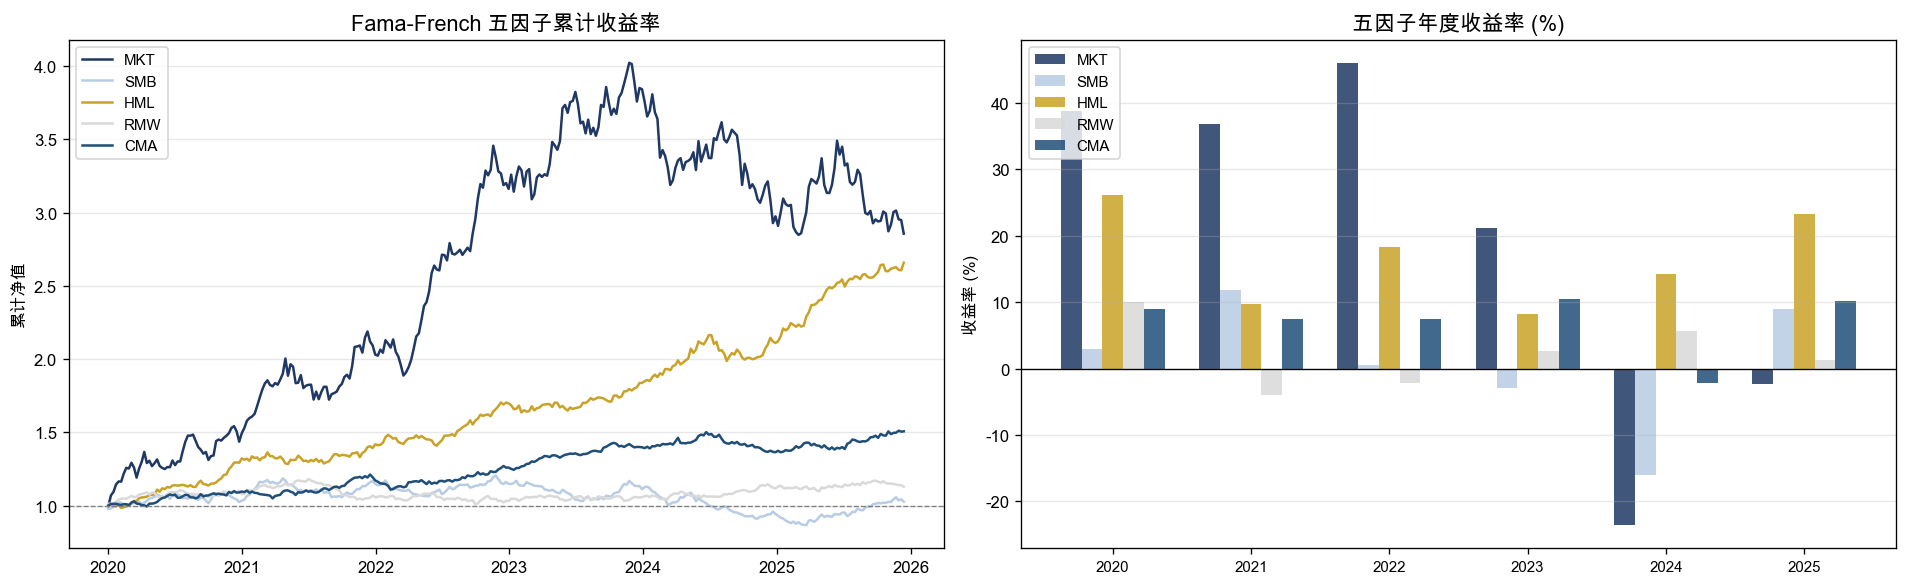

✅ 图14对应图表已生成


In [10]:
# ============================================================
# 因子可视化 1：累计收益率（对应报告图14）
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- 左图：累计收益率 ---
factor_cumret = (1 + ff_weekly).cumprod()

colors = {
    'MKT': '#1f3864',   # 深海军蓝
    'SMB': '#b8cce4',   # 浅蓝灰
    'HML': '#c9a227',   # 金棕色
    'RMW': '#d9d9d9',   # 浅灰
    'CMA': '#1f4e79',   # 中深蓝
}

ax = axes[0]
for col in ['MKT', 'SMB', 'HML', 'RMW', 'CMA']:
    ax.plot(factor_cumret.index,
            factor_cumret[col],
            label=col,
            color=colors[col],
            linewidth=1.5)

ax.axhline(1.0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Fama-French 五因子累计收益率', fontsize=13)
ax.set_ylabel('累计净值')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(axis='y', alpha=0.3)

# --- 右图：年度收益率柱状图 ---
ax2 = axes[1]
ff_annual = ff_weekly.resample('Y').sum()
ff_annual.index = ff_annual.index.year

x = np.arange(len(ff_annual))
width = 0.15
factor_list = ['MKT', 'SMB', 'HML', 'RMW', 'CMA']

for i, col in enumerate(factor_list):
    bars = ax2.bar(x + i * width,
                   ff_annual[col] * 100,
                   width,
                   label=col,
                   color=colors[col],
                   alpha=0.85)

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('五因子年度收益率 (%)', fontsize=13)
ax2.set_ylabel('收益率 (%)')
ax2.set_xticks(x + width * 2)
ax2.set_xticklabels(ff_annual.index, fontsize=9)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'ff_cumret.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 图14对应图表已生成")

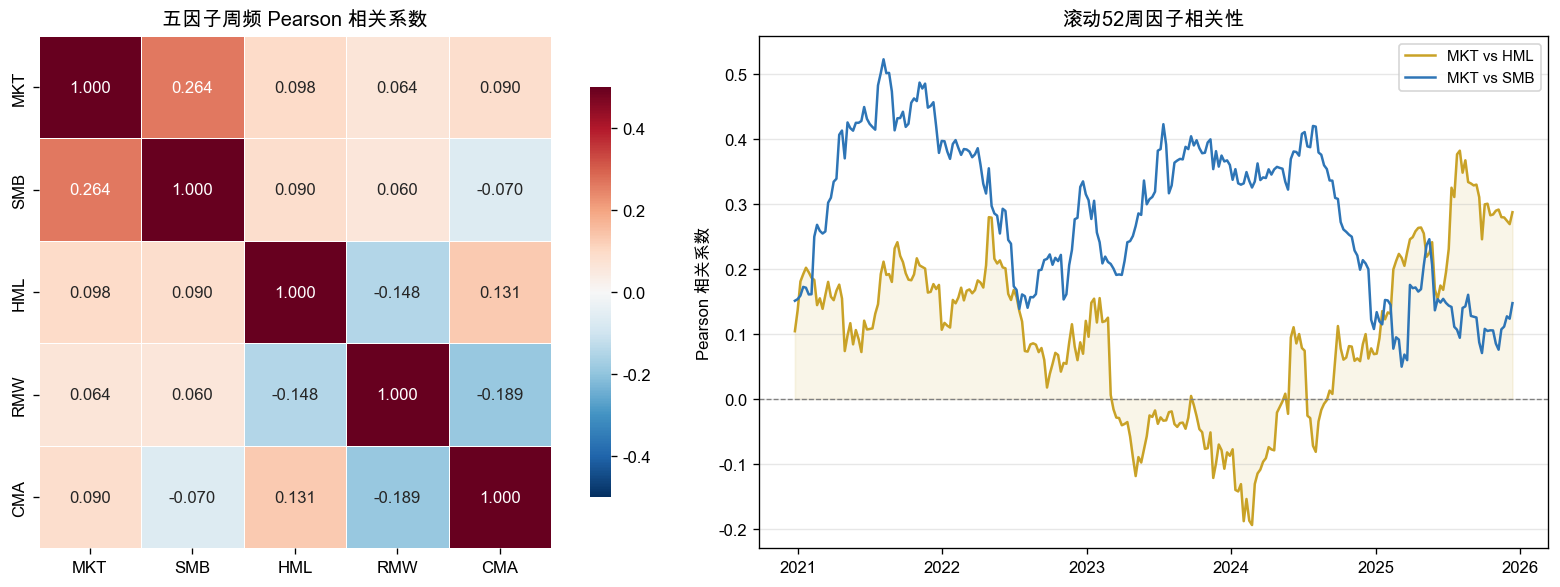

✅ 因子相关性图已生成


In [ ]:
# ============================================================
# 因子可视化 2：相关性矩阵
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左图：Pearson相关系数 ---
corr_matrix = ff_weekly.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    vmin=-0.5, vmax=0.5,
    square=True,
    ax=axes[0],
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('五因子周频 Pearson 相关系数', fontsize=12)

# --- 右图：滚动52周相关性（MKT vs HML）---
ax2 = axes[1]
roll_corr_mkt_hml = ff_weekly['MKT'].rolling(52).corr(ff_weekly['HML'])
roll_corr_mkt_smb = ff_weekly['MKT'].rolling(52).corr(ff_weekly['SMB'])

ax2.plot(roll_corr_mkt_hml.index, roll_corr_mkt_hml,
         label='MKT vs HML', color=colors['HML'], linewidth=1.5)
ax2.plot(roll_corr_mkt_smb.index, roll_corr_mkt_smb,
         label='MKT vs SMB', color=colors['SMB'], linewidth=1.5)
ax2.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax2.fill_between(roll_corr_mkt_hml.index, roll_corr_mkt_hml, 0,
                 alpha=0.1, color=colors['HML'])
ax2.set_title('滚动52周因子相关性', fontsize=12)
ax2.set_ylabel('Pearson 相关系数')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'ff_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 因子相关性图已生成")

In [14]:
# ============================================================
# 因子描述统计（周频）
# ============================================================

from scipy.stats import skew, kurtosis

desc_rows = []
for col in ['MKT', 'SMB', 'HML', 'RMW', 'CMA']:
    s = ff_weekly[col].dropna()
    desc_rows.append({
        '因子'       : col,
        '周均值'     : f"{s.mean()*100:.4f}%",
        '年化收益'   : f"{s.mean()*52*100:.2f}%",
        '周波动率'   : f"{s.std()*100:.4f}%",
        '年化波动'   : f"{s.std()*np.sqrt(52)*100:.2f}%",
        '偏度'       : f"{skew(s):.3f}",
        '峰度'       : f"{kurtosis(s):.3f}",
        '最小值'     : f"{s.min()*100:.2f}%",
        '最大值'     : f"{s.max()*100:.2f}%",
    })

desc_df = pd.DataFrame(desc_rows).set_index('因子')
print("=" * 70)
print("Fama-French 五因子 周频描述统计")
print("=" * 70)
print(desc_df.to_string())
print()

# 计算Sharpe（年化）
print("因子年化Sharpe比率（无风险利率=0）：")
for col in ['MKT', 'SMB', 'HML', 'RMW', 'CMA']:
    s = ff_weekly[col].dropna()
    sharpe = s.mean() / s.std() * np.sqrt(52)
    print(f"  {col} : {sharpe:.3f}")

print("\n✅ 因子统计分析完成")

Fama-French 五因子 周频描述统计
         周均值    年化收益     周波动率    年化波动      偏度      峰度     最小值    最大值
因子                                                                  
MKT  0.3758%  19.54%  2.7527%  19.85%  -0.131  -0.244  -7.28%  7.44%
SMB  0.0177%   0.92%  1.3311%   9.60%  -0.030  -0.291  -3.86%  3.73%
HML  0.3214%  16.71%  1.1500%   8.29%  -0.097  -0.091  -2.83%  3.41%
RMW  0.0432%   2.24%  0.8658%   6.24%  -0.175  -0.024  -2.61%  2.44%
CMA  0.1361%   7.08%  0.8841%   6.38%   0.039  -0.069  -2.43%  2.69%

因子年化Sharpe比率（无风险利率=0）：
  MKT : 0.984
  SMB : 0.096
  HML : 2.015
  RMW : 0.359
  CMA : 1.110

✅ 因子统计分析完成


In [15]:
# ============================================================
# 数据对齐：确保 X_t 对应 Y_{t+1}（预测下一期收益率）
# ============================================================

# 将因子和收益率对齐到共同日期索引
common_weeks = ff_weekly.index.intersection(index_return_weekly.index)

X_all = ff_weekly.loc[common_weeks].copy()          # 自变量：当期因子
Y_all = index_return_weekly.loc[common_weeks].copy() # 因变量：当期收益率

# 构造滞后结构：用 t 期因子预测 t+1 期收益率
# X_lag[t] = 因子值(t)，Y_lead[t] = 收益率(t+1)
X_lag  = X_all.iloc[:-1].copy()
Y_lead = Y_all.iloc[1:].copy()

# 确保索引一致
X_lag.index  = range(len(X_lag))
Y_lead.index = range(len(Y_lead))

# 还原日期用于后续回测定位
week_dates = common_weeks[1:]   # 预测目标周的日期

print("✅ 因子-收益率对齐完成")
print(f"   X_lag  shape : {X_lag.shape}   （因子，用于预测）")
print(f"   Y_lead shape : {Y_lead.shape}  （下周收益率，预测目标）")
print(f"   有效预测周数  : {len(week_dates)}")
print(f"   起始预测周    : {week_dates[0].date()}")
print(f"   截止预测周    : {week_dates[-1].date()}")

# 快速检查：因子与收益率的截面相关性（全样本，仅供参考）
print("\n各因子与所有指数收益率的平均Pearson相关系数（全样本参考）：")
for col in ['MKT', 'SMB', 'HML', 'RMW', 'CMA']:
    corrs = []
    for idx_code in index_codes:
        valid = Y_lead[idx_code].dropna()
        if len(valid) > 30:
            x_valid = X_lag.loc[valid.index, col]
            r, _ = stats.pearsonr(x_valid, valid)
            corrs.append(r)
    print(f"  {col} : {np.mean(corrs):.4f}  (n={len(corrs)}支指数)")

✅ 因子-收益率对齐完成
   X_lag  shape : (310, 5)   （因子，用于预测）
   Y_lead shape : (310, 30)  （下周收益率，预测目标）
   有效预测周数  : 310
   起始预测周    : 2020-01-10
   截止预测周    : 2025-12-12

各因子与所有指数收益率的平均Pearson相关系数（全样本参考）：
  MKT : 0.0136  (n=30支指数)
  SMB : -0.0027  (n=30支指数)
  HML : 0.0100  (n=30支指数)
  RMW : 0.0110  (n=30支指数)
  CMA : 0.0052  (n=30支指数)


## 第三部分：分位数随机森林（QRF）分布预测

### 模块目标

对每一个调仓日，对每一支有效指数，用过去104周的历史数据训练QRF模型，
预测该指数**下一周收益率分布**的19个分位数（5%, 10%, ..., 95%），
再通过分位数近似方法生成10000次模拟抽样，得到完整的收益率分布。

### 输入输出

| 项目 | 说明 |
|------|------|
| **输入X** | 当期Fama-French五因子周频收益率（5维） |
| **输入Y** | 下一期指数周度收益率（标量） |
| **训练窗口** | 近104周（不足则用最长可用窗口，最少30周） |
| **输出** | 19个分位数值 + 10000次模拟样本 |

### 滚动预测逻辑
for 每个调仓日 t:

for 每支有效指数 i:

取 [t-104, t-1] 的 (X, Y) 作为训练集

训练 QRF

用 X[t] 预测分位数 → 生成模拟分布

计算7个指标

### 计算量说明
- 调仓日数量：约300个（2020-2025）
- 每期有效指数：约20-30支
- 每次QRF训练：200棵树 × 104样本
- 预计总训练次数：~8000次
- 建议：生产环境可用 `n_jobs=-1` 并行加速

### 分位数近似生成分布的方法

对应报告第11页的描述：

1. 以5%为间隔选取分位点 α = {5%, 10%, ..., 95%}
2. QRF预测对应的19个分位数值 $y_1, ..., y_{19}$
3. 在相邻分位数之间填充均匀分布
4. 以两个相邻分位数的**中点**作为均匀分布概率密度的表征点
5. 连线得到近似概率密度函数
6. 从该近似分布中进行10000次模拟抽样

**边界处理：**
- 0%分位数（左尾）：用 $y_1 - (y_2 - y_1)$ 外推
- 100%分位数（右尾）：用 $y_{19} + (y_{19} - y_{18})$ 外推

In [17]:
# ============================================================
# QRF Part 1：分位数近似 → 模拟抽样
# ============================================================

def quantile_to_samples(quantile_values, quantile_points,
                         n_samples=10_000, seed=None):
    """
    将QRF预测的分位数近似为连续分布并进行模拟抽样。

    Parameters
    ----------
    quantile_values : array-like, shape (n_quantiles,)
        QRF预测的分位数值，例如 [q05, q10, ..., q95]
    quantile_points : array-like, shape (n_quantiles,)
        对应的分位点，例如 [0.05, 0.10, ..., 0.95]
    n_samples : int
        模拟抽样次数
    seed : int or None

    Returns
    -------
    samples : np.ndarray, shape (n_samples,)
        模拟收益率样本
    """
    if seed is not None:
        np.random.seed(seed)

    q_vals   = np.array(quantile_values)
    q_points = np.array(quantile_points)

    # 边界外推（处理0%和100%分位数）
    left_ext  = q_vals[0]  - (q_vals[1]  - q_vals[0])
    right_ext = q_vals[-1] + (q_vals[-1] - q_vals[-2])

    # 完整分位数序列（含0%和100%外推）
    q_full = np.concatenate([[left_ext], q_vals, [right_ext]])
    p_full = np.concatenate([[0.0], q_points, [1.0]])

    # 每个区间的概率质量
    prob_mass = np.diff(p_full)           # shape: (n_intervals,)
    intervals = list(zip(q_full[:-1], q_full[1:]))   # (left, right)

    # 按概率质量分配抽样数量
    n_per_interval = np.round(prob_mass * n_samples).astype(int)
    # 修正舍入误差
    diff = n_samples - n_per_interval.sum()
    n_per_interval[np.argmax(prob_mass)] += diff

    # 在每个区间内均匀抽样
    samples = []
    for (left, right), n in zip(intervals, n_per_interval):
        if n > 0:
            s = np.random.uniform(left, right, n)
            samples.append(s)

    return np.concatenate(samples)


def compute_distribution_metrics(samples, risk_free=0.0):
    """
    从模拟样本中计算7个指标。

    Parameters
    ----------
    samples : np.ndarray
        收益率模拟样本
    risk_free : float
        无风险利率（默认0）

    Returns
    -------
    dict : 包含7个指标的字典
    """
    s = samples
    mean_ret = np.mean(s)
    std_ret  = np.std(s)

    # 下行样本
    downside = s[s < risk_free]
    upside   = s[s >= risk_free]

    # 下行标准差
    downside_std = np.std(downside) if len(downside) > 1 else 1e-8

    # 胜率
    win_rate = np.mean(s > risk_free)

    # Sharpe
    sharpe = (mean_ret - risk_free) / std_ret if std_ret > 1e-8 else 0.0

    # Sortino
    sortino = (mean_ret - risk_free) / downside_std if downside_std > 1e-8 else 0.0

    # Omega
    avg_up   = np.mean(upside)   if len(upside)   > 0 else 0.0
    avg_down = np.abs(np.mean(downside)) if len(downside) > 0 else 1e-8
    p_up     = win_rate
    p_down   = 1 - win_rate
    omega = (avg_up * p_up) / (avg_down * p_down) if (avg_down * p_down) > 1e-8 else 0.0

    return {
        'quantile_50' : np.percentile(s, 50),
        'quantile_75' : np.percentile(s, 75),
        'mean_return' : mean_ret,
        'sharpe'      : sharpe,
        'sortino'     : sortino,
        'omega'       : omega,
        'win_rate'    : win_rate,
    }


# --- 快速单元测试 ---
test_q_vals   = np.percentile(np.random.randn(1000) * 0.02, 
                               [5,10,15,20,25,30,35,40,45,50,
                                55,60,65,70,75,80,85,90,95])
test_q_points = QRF_QUANTILES

test_samples  = quantile_to_samples(test_q_vals, test_q_points,
                                     n_samples=10_000, seed=0)
test_metrics  = compute_distribution_metrics(test_samples)

print("✅ 分位数抽样函数单元测试通过")
print(f"   样本数    : {len(test_samples)}")
print(f"   样本均值  : {test_samples.mean():.5f}")
print(f"   样本标准差: {test_samples.std():.5f}")
print("\n7个指标计算结果（测试）：")
for k, v in test_metrics.items():
    print(f"  {k:<15}: {v:.5f}")

✅ 分位数抽样函数单元测试通过
   样本数    : 10000
   样本均值  : -0.00005
   样本标准差: 0.01826

7个指标计算结果（测试）：
  quantile_50    : -0.00029
  quantile_75    : 0.01283
  mean_return    : -0.00005
  sharpe         : -0.00289
  sortino        : -0.00498
  omega          : 0.99290
  win_rate       : 0.49280


In [18]:
# ============================================================
# QRF Part 2：单指数训练+预测函数
# ============================================================

def train_predict_qrf(X_train, y_train, X_pred,
                       quantile_points=None,
                       n_estimators=200,
                       n_simulations=10_000,
                       random_state=42):
    """
    训练QRF并对单个预测点输出分位数 + 模拟样本 + 7指标。

    Parameters
    ----------
    X_train : np.ndarray, shape (n_train, 5)
        训练集因子数据
    y_train : np.ndarray, shape (n_train,)
        训练集收益率
    X_pred  : np.ndarray, shape (1, 5) 或 (5,)
        预测点因子数据
    quantile_points : list
        分位点列表
    n_estimators : int
        决策树数量
    n_simulations : int
        模拟抽样次数

    Returns
    -------
    result : dict
        quantiles   : 分位数值数组
        samples     : 模拟样本数组
        metrics     : 7个指标字典
        success     : bool
    """
    if quantile_points is None:
        quantile_points = QRF_QUANTILES

    result = {
        'quantiles' : None,
        'samples'   : None,
        'metrics'   : None,
        'success'   : False,
    }

    try:
        # 数据校验
        if len(X_train) < 30:
            return result
        if np.any(np.isnan(X_train)) or np.any(np.isnan(y_train)):
            mask = ~(np.isnan(X_train).any(axis=1) | np.isnan(y_train))
            X_train = X_train[mask]
            y_train = y_train[mask]
        if len(X_train) < 30:
            return result

        X_pred_2d = X_pred.reshape(1, -1)

        # 训练QRF
        qrf = RandomForestQuantileRegressor(
            n_estimators  = n_estimators,
            random_state  = random_state,
            n_jobs        = -1,
            min_samples_leaf = 5,
        )
        qrf.fit(X_train, y_train)

        # 预测分位数
        q_values = qrf.predict(
            X_pred_2d,
            quantiles=quantile_points
        ).flatten()

        # 确保分位数单调递增（偶尔会出现轻微违反）
        q_values = np.maximum.accumulate(q_values)

        # 生成模拟样本
        samples = quantile_to_samples(
            q_values, quantile_points,
            n_samples=n_simulations
        )

        # 计算7个指标
        metrics = compute_distribution_metrics(samples)

        result['quantiles'] = q_values
        result['samples']   = samples
        result['metrics']   = metrics
        result['success']   = True

    except Exception as e:
        result['error'] = str(e)

    return result


# --- 单指数测试 ---
test_idx = index_codes[0]
test_weeks = np.where(~Y_lead[test_idx].isna())[0]

if len(test_weeks) >= 35:
    t = test_weeks[104]  # 第104周之后才开始预测
    X_tr = X_lag.iloc[test_weeks[:t]].values
    y_tr = Y_lead[test_idx].iloc[test_weeks[:t]].values
    X_pr = X_lag.iloc[t].values

    test_result = train_predict_qrf(X_tr, y_tr, X_pr,
                                     n_estimators=50,   # 测试用小模型
                                     n_simulations=1000)

    if test_result['success']:
        print("✅ QRF单指数训练预测测试通过")
        print(f"   指数     : {index_info.loc[test_idx, 'index_name']}")
        print(f"   训练样本 : {len(X_tr)}")
        print(f"   分位数（前5个）: {test_result['quantiles'][:5].round(5)}")
        print(f"   模拟样本均值   : {test_result['samples'].mean():.5f}")
        print(f"\n   7指标：")
        for k, v in test_result['metrics'].items():
            print(f"     {k:<15}: {v:.5f}")
    else:
        print(f"❌ 测试失败: {test_result.get('error', '未知错误')}")

✅ QRF单指数训练预测测试通过
   指数     : 半导体主题
   训练样本 : 104
   分位数（前5个）: [-0.09795 -0.06863 -0.05978 -0.04845 -0.03932]
   模拟样本均值   : -0.00181

   7指标：
     quantile_50    : 0.00652
     quantile_75    : 0.01597
     mean_return    : -0.00181
     sharpe         : -0.03152
     sortino        : -0.05495
     omega          : 0.91790
     win_rate       : 0.53700


In [19]:
# ============================================================
# QRF Part 3：滚动预测主循环
# PS. 大概需要20分钟，请耐心等待
# ============================================================

# 获取所有调仓日（每周第一个交易日 → 用周频索引近似）
rebalance_dates = week_dates[
    (week_dates >= pd.Timestamp(BACKTEST_START)) &
    (week_dates <= pd.Timestamp(BACKTEST_END))
]

print(f"调仓周数：{len(rebalance_dates)}")
print(f"起始：{rebalance_dates[0].date()}  截止：{rebalance_dates[-1].date()}")

# ============================================================
# 主循环：对每个调仓日、每支有效指数进行QRF预测
# ============================================================

# 存储结构：
#   all_metrics[date][index_code] = 7指标字典
#   all_quantiles[date][index_code] = 分位数数组
#   all_samples[date][index_code]  = 模拟样本数组

all_metrics   = {}
all_quantiles = {}
all_samples   = {}

# 将week_dates转为整数位置索引方便切片
date_to_pos = {d: i for i, d in enumerate(week_dates)}

for rebal_date in tqdm(rebalance_dates, desc='滚动QRF预测'):

    t_pos = date_to_pos.get(rebal_date)
    if t_pos is None:
        continue

    all_metrics[rebal_date]   = {}
    all_quantiles[rebal_date] = {}
    all_samples[rebal_date]   = {}

    for idx_code in index_codes:

        # 获取该指数的有效数据位置
        valid_mask = ~Y_lead[idx_code].isna().values
        valid_positions = np.where(valid_mask)[0]

        # 只使用 t_pos 之前的有效数据作为训练集
        train_positions = valid_positions[valid_positions < t_pos]

        # 最少需要30个样本
        if len(train_positions) < 30:
            continue

        # 截取至多 QRF_WINDOW 个样本（滚动窗口）
        train_positions = train_positions[-QRF_WINDOW:]

        X_train = X_lag.iloc[train_positions].values
        y_train = Y_lead[idx_code].iloc[train_positions].values

        # 预测点：t_pos 期的因子值
        if t_pos >= len(X_lag):
            continue
        X_pred = X_lag.iloc[t_pos].values

        # 训练预测
        res = train_predict_qrf(
            X_train       = X_train,
            y_train       = y_train,
            X_pred        = X_pred,
            quantile_points = QRF_QUANTILES,
            n_estimators  = QRF_N_ESTIMATORS,
            n_simulations = QRF_N_SIMULATIONS,
        )

        if res['success']:
            all_metrics[rebal_date][idx_code]   = res['metrics']
            all_quantiles[rebal_date][idx_code] = res['quantiles']
            all_samples[rebal_date][idx_code]   = res['samples']

    n_valid = len(all_metrics[rebal_date])

# 转为DataFrame方便后续使用
# all_metrics_df：MultiIndex (date, index_code) × 7指标
records = []
for date, idx_dict in all_metrics.items():
    for idx_code, metrics in idx_dict.items():
        row = {'date': date, 'index_code': idx_code}
        row.update(metrics)
        records.append(row)

all_metrics_df = pd.DataFrame(records).set_index(['date', 'index_code'])

print(f"\n✅ 滚动QRF预测完成")
print(f"   总预测记录数  : {len(all_metrics_df)}")
print(f"   平均每期有效指数: {len(all_metrics_df) / len(rebalance_dates):.1f} 支")
print(all_metrics_df.head(8).round(5))

调仓周数：310
起始：2020-01-10  截止：2025-12-12


滚动QRF预测: 100%|██████████| 310/310 [19:43<00:00,  3.82s/it]


✅ 滚动QRF预测完成
   总预测记录数  : 7739
   平均每期有效指数: 25.0 支
                       quantile_50  quantile_75  mean_return   sharpe  \
date       index_code                                                   
2020-08-07 800001.CSI     -0.01358      0.00592     -0.02314 -0.43793   
           800002.CSI     -0.00320      0.06311      0.00347  0.04676   
           800003.CSI     -0.04935      0.03247     -0.03345 -0.54297   
           800004.CSI      0.02056      0.10553      0.04886  0.64576   
           800005.CSI      0.00871      0.03318      0.01227  0.22573   
           800006.CSI      0.01437      0.04235      0.00244  0.04425   
           800007.CSI      0.01311      0.05469      0.01573  0.31046   
           800008.CSI     -0.02121      0.01116     -0.01787 -0.42022   

                       sortino    omega  win_rate  
date       index_code                              
2020-08-07 800001.CSI -0.63565  0.29886    0.4271  
           800002.CSI  0.07714  1.12480    0.4862  
          

Spearman IC 统计（对应报告表7、表9）
指标                     均值IC      标准差       IR      正占比
------------------------------------------------------------
quantile_50         -0.0015   0.1982   -0.008   50.0%  
quantile_75         -0.0025   0.2064   -0.012   47.9%  
mean_return         -0.0011   0.1929   -0.006   47.9%  
sharpe              -0.0009   0.1923   -0.004   51.4%  
sortino             -0.0031   0.1956   -0.016   49.6%  
omega               -0.0003   0.1913   -0.002   50.0%  
win_rate             0.0005   0.1973    0.002   50.0%  

✓ = 均值IC绝对值 ≥ 0.05（报告有效性标准）


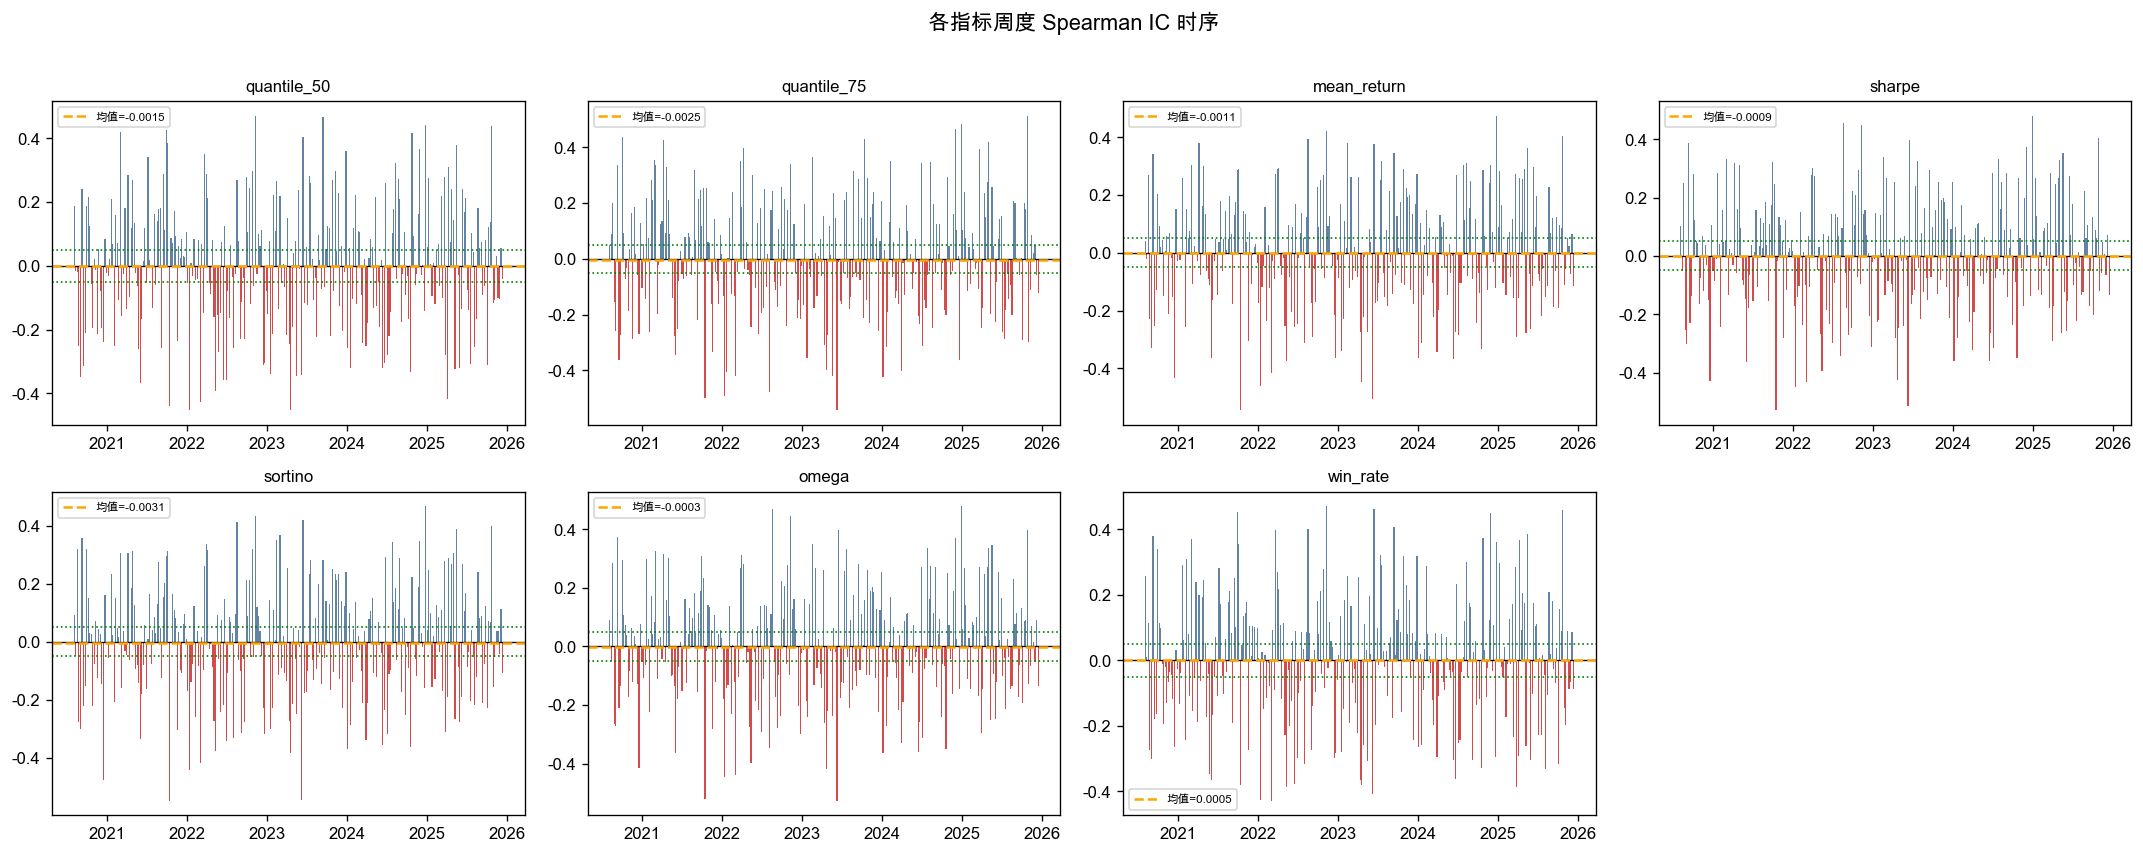


✅ IC验证完成


In [ ]:
# ============================================================
# QRF Part 4：Spearman IC 验证（对应报告表7、表9）
# ============================================================

week_dates_list = list(week_dates)
date_to_pos = {d: i for i, d in enumerate(week_dates_list)}

indicator_cols = list(INDICATOR_WEIGHTS.keys())

ic_records = []

for rebal_date in rebalance_dates:
    if rebal_date not in all_metrics:
        continue

    # 直接从字典取，完全绕开 MultiIndex 的时间戳对齐问题
    metrics_this = pd.DataFrame(all_metrics[rebal_date]).T
    metrics_this.index.name = 'index_code'

    # 该期真实收益率（下一周）
    t_pos = date_to_pos.get(rebal_date)
    if t_pos is None or t_pos >= len(Y_lead):
        continue

    actual_ret = Y_lead.iloc[t_pos]

    # 取交集
    common_idx = metrics_this.index.intersection(actual_ret.dropna().index)
    if len(common_idx) < 5:
        continue

    y_true = actual_ret.loc[common_idx].values
    row = {'date': rebal_date}

    for col in indicator_cols:
        if col not in metrics_this.columns:
            continue
        y_pred = metrics_this.loc[common_idx, col].values
        valid  = ~(np.isnan(y_pred) | np.isnan(y_true))
        if valid.sum() < 5:
            row[col] = np.nan
            continue
        ic, _ = spearmanr(y_pred[valid], y_true[valid])
        row[col] = ic

    ic_records.append(row)

ic_df = pd.DataFrame(ic_records).set_index('date')

# 汇总统计
print("=" * 60)
print("Spearman IC 统计（对应报告表7、表9）")
print("=" * 60)
print(f"{'指标':<18} {'均值IC':>8} {'标准差':>8} {'IR':>8} {'正占比':>8}")
print("-" * 60)
for col in indicator_cols:
    if col not in ic_df.columns:
        continue
    s = ic_df[col].dropna()
    mean_ic = s.mean()
    std_ic  = s.std()
    ir      = mean_ic / std_ic if std_ic > 0 else 0
    pos_pct = (s > 0).mean()
    flag = " ✓" if abs(mean_ic) >= 0.05 else "  "
    print(f"{col:<18} {mean_ic:>8.4f} {std_ic:>8.4f} {ir:>8.3f} {pos_pct:>7.1%}{flag}")

print("\n✓ = 均值IC绝对值 ≥ 0.05（报告有效性标准）")

# --- IC时序图 ---
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(indicator_cols):
    if col not in ic_df.columns or i >= len(axes):
        continue
    ax = axes[i]
    s  = ic_df[col].dropna()

    ax.bar(s.index, s.values,
           color=[('#1f4e79' if v > 0 else '#c00000') for v in s.values],
           alpha=0.7, width=5)
    ax.axhline(0,          color='black', linewidth=0.8)
    ax.axhline(s.mean(),   color='orange', linewidth=1.5,
               linestyle='--', label=f'均值={s.mean():.4f}')
    ax.axhline(0.05,  color='green', linewidth=1, linestyle=':')
    ax.axhline(-0.05, color='green', linewidth=1, linestyle=':')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 隐藏多余子图
for j in range(len(indicator_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('各指标周度 Spearman IC 时序', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'ic_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ IC验证完成")

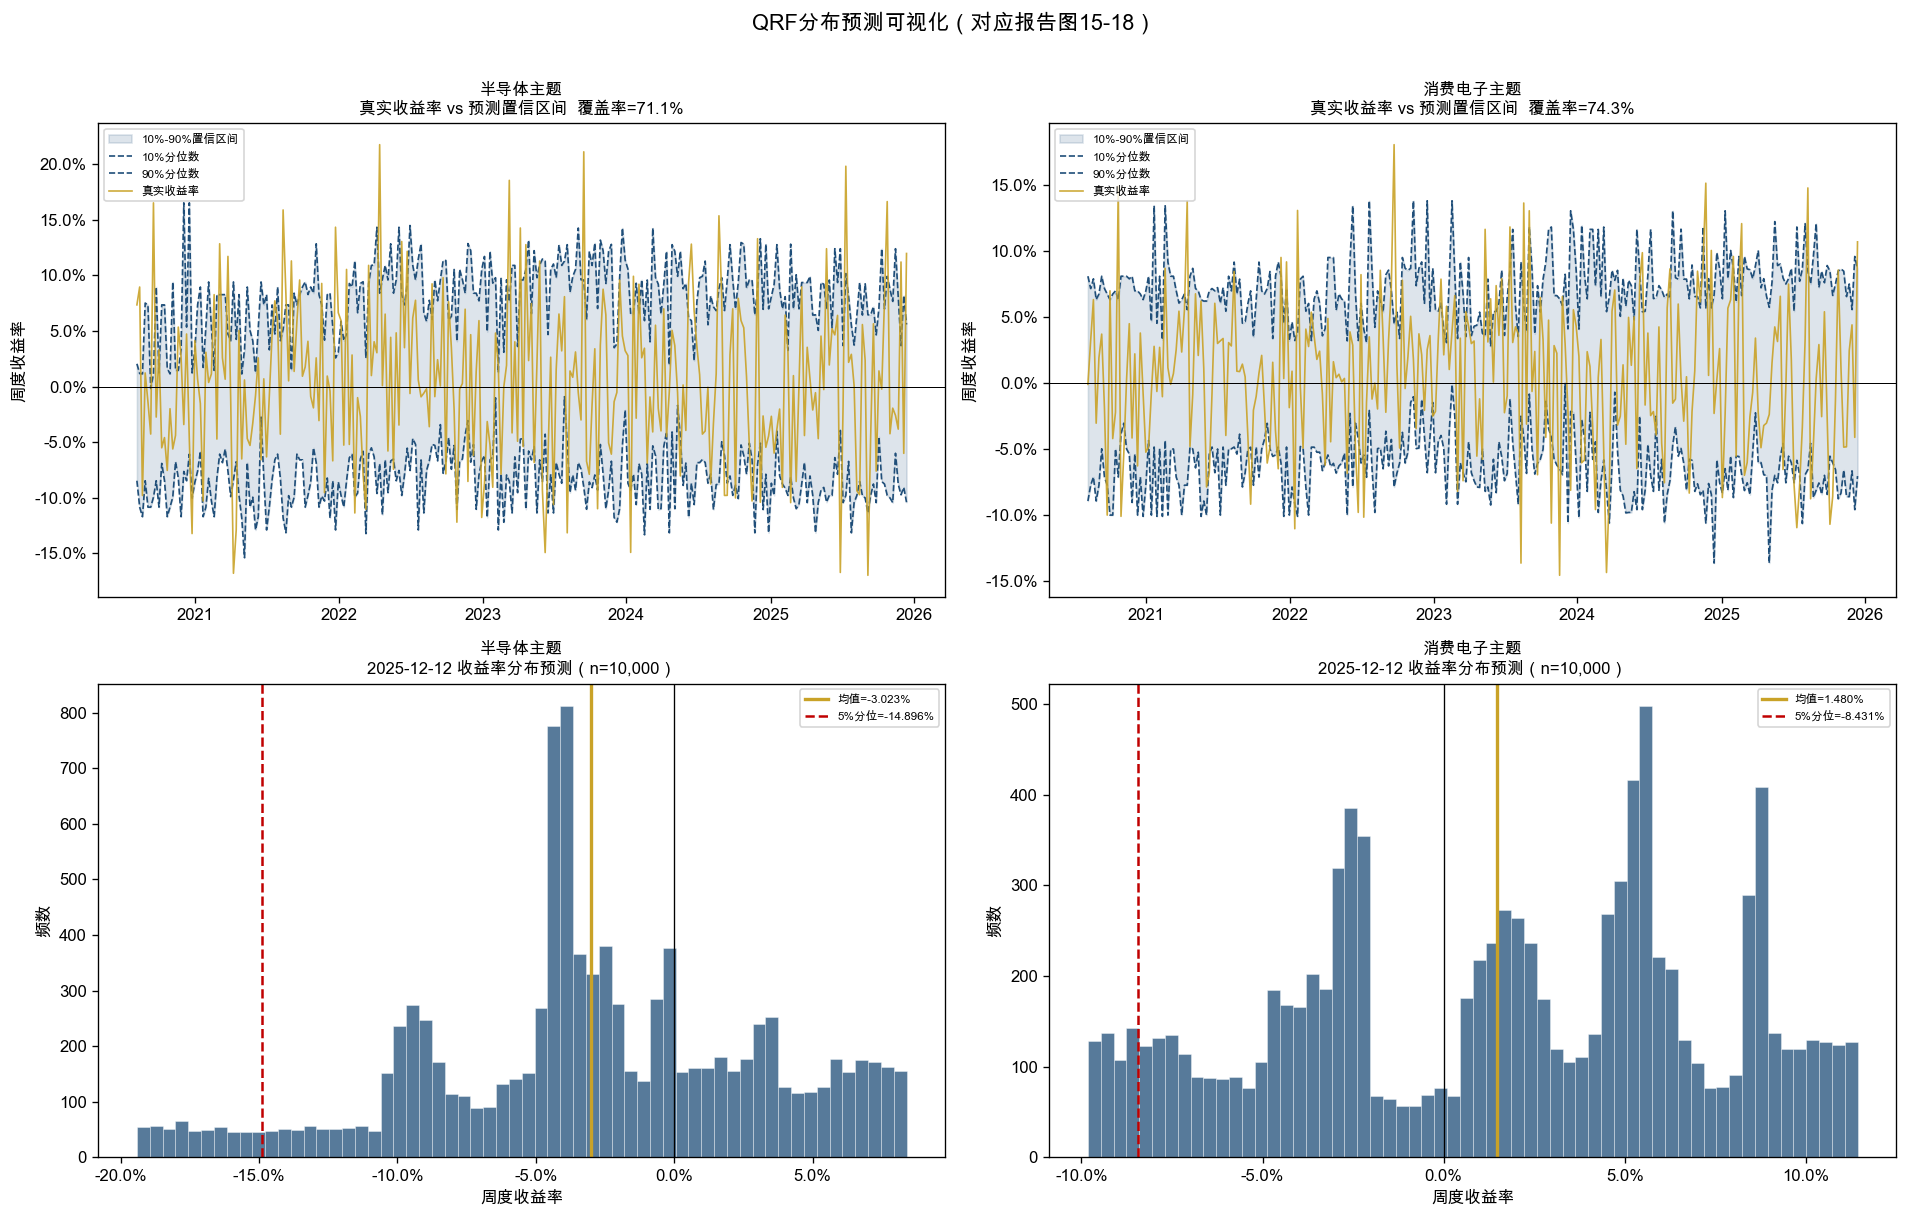

✅ QRF分布预测可视化完成


In [ ]:
# ============================================================
# QRF Part 5：单指数分布预测可视化
# 对应报告图15（新兴成指）和图17（分布抽样直方图）
# ============================================================

# 取最后一个有预测结果的调仓日
last_date = max(d for d in rebalance_dates if d in all_quantiles 
                and len(all_quantiles[d]) > 0)

# 取两支有代表性的指数
demo_indices = [c for c in index_codes 
                if c in all_quantiles[last_date]][:2]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_i, idx_code in enumerate(demo_indices):
    idx_name = index_info.loc[idx_code, 'index_name']

    # --- 上图：真实收益率 vs 10%/90%分位数时序（对应图15/16）---
    ax_top = axes[0][col_i]

    dates_pred, q10_list, q90_list, actual_list = [], [], [], []

    for d in rebalance_dates:
        if d not in all_quantiles:
            continue
        if idx_code not in all_quantiles[d]:
            continue
        t_pos = date_to_pos.get(d)
        if t_pos is None or t_pos >= len(Y_lead):
            continue

        q_vals = all_quantiles[d][idx_code]
        q10 = q_vals[1]    # 10%分位数（索引1，因为从5%开始）
        q90 = q_vals[-2]   # 90%分位数

        actual = Y_lead[idx_code].iloc[t_pos]
        if np.isnan(actual):
            continue

        dates_pred.append(d)
        q10_list.append(q10)
        q90_list.append(q90)
        actual_list.append(actual)

    dates_pred  = pd.DatetimeIndex(dates_pred)
    q10_arr     = np.array(q10_list)
    q90_arr     = np.array(q90_list)
    actual_arr  = np.array(actual_list)

    ax_top.fill_between(dates_pred, q10_arr, q90_arr,
                         alpha=0.15, color='#1f4e79', label='10%-90%置信区间')
    ax_top.plot(dates_pred, q10_arr,
                color='#1f4e79', linewidth=1.0, linestyle='--', label='10%分位数')
    ax_top.plot(dates_pred, q90_arr,
                color='#1f4e79', linewidth=1.0, linestyle='--', label='90%分位数')
    ax_top.plot(dates_pred, actual_arr,
                color='#c9a227', linewidth=1.0, alpha=0.9, label='真实收益率')
    ax_top.axhline(0, color='black', linewidth=0.6)

    # 覆盖率
    in_band = np.mean((actual_arr >= q10_arr) & (actual_arr <= q90_arr))
    ax_top.set_title(f'{idx_name}\n真实收益率 vs 预测置信区间  覆盖率={in_band:.1%}',
                     fontsize=10)
    ax_top.set_ylabel('周度收益率')
    ax_top.legend(fontsize=7, loc='upper left')
    ax_top.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax_top.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

    # --- 下图：最新期分布直方图（对应图17/18）---
    ax_bot = axes[1][col_i]

    samples = all_samples[last_date][idx_code]
    ax_bot.hist(samples, bins=60, color='#1f4e79', alpha=0.75,
                edgecolor='white', linewidth=0.3)
    ax_bot.axvline(np.mean(samples),
                   color='#c9a227', linewidth=2, linestyle='-',
                   label=f'均值={np.mean(samples):.3%}')
    ax_bot.axvline(np.percentile(samples, 5),
                   color='#c00000', linewidth=1.5, linestyle='--',
                   label=f'5%分位={np.percentile(samples,5):.3%}')
    ax_bot.axvline(0, color='black', linewidth=0.8)
    ax_bot.set_title(f'{idx_name}\n{last_date.date()} 收益率分布预测（n=10,000）',
                     fontsize=10)
    ax_bot.set_xlabel('周度收益率')
    ax_bot.set_ylabel('频数')
    ax_bot.legend(fontsize=7)
    ax_bot.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

plt.suptitle('QRF分布预测可视化（对应报告图15-18）', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'qrf_distribution_preview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ QRF分布预测可视化完成")

## 第四部分：指数选择

### 模块目标

在每个调仓日，基于QRF预测得到的7个指标，对所有有效指数进行综合评分，
选出评分最高的5支指数，同时施加行业分散约束。

### 截面标准化

对每期截面内的每个指标进行z-score标准化：

$$X_{ij} = \frac{x_{ij} - \bar{x}_i}{S_i}$$

其中：
- $x_{ij}$：第 $j$ 个指数第 $i$ 个指标的原始值
- $\bar{x}_i$：该指标的截面均值
- $S_i$：该指标的截面标准差

### 复合评分

$$Score_j = \sum_{i=1}^{7} D_i W_i X_{ij}$$

对应报告表10的权重设定：

| 指标 | 方向 | 权重 |
|------|------|------|
| 50%分位数 | 正向 | 1倍 |
| 75%分位数 | 正向 | 1倍 |
| 平均收益率 | 正向 | 1倍 |
| Sharpe比率 | 正向 | **2倍** |
| Sortino比率 | 正向 | 1倍 |
| Omega比率 | 正向 | 1倍 |
| 胜率 | 正向 | 1倍 |

### 行业分散约束

选取复合评分最高的Top5指数时，要求：
- 每个指数覆盖到的**最小行业层级**（中信一级行业）最多出现1次
- 即同一中信一级行业最多选1支指数
- 采用贪心法：按评分从高到低依次选入，若行业已被占用则跳过

In [24]:
# ============================================================
# 指数选择 Part 1：截面标准化 + 复合评分
# ============================================================

def compute_composite_score(metrics_dict, weights=None):
    """
    对单期截面指标进行标准化并计算复合评分。

    Parameters
    ----------
    metrics_dict : dict
        {index_code: {indicator: value, ...}, ...}
    weights : dict
        指标权重字典，默认使用全局 INDICATOR_WEIGHTS

    Returns
    -------
    scores : pd.Series
        index = index_code, values = 复合评分（降序排列）
    metrics_df : pd.DataFrame
        标准化后的指标矩阵
    """
    if weights is None:
        weights = INDICATOR_WEIGHTS

    if len(metrics_dict) < 2:
        return pd.Series(dtype=float), pd.DataFrame()

    # 构建原始指标矩阵
    raw_df = pd.DataFrame(metrics_dict).T
    raw_df.index.name = 'index_code'

    # 只保留权重字典中定义的指标列
    cols = [c for c in weights.keys() if c in raw_df.columns]
    raw_df = raw_df[cols].astype(float)

    # 截面z-score标准化
    std_df = raw_df.copy()
    for col in cols:
        col_mean = raw_df[col].mean()
        col_std  = raw_df[col].std()
        if col_std > 1e-8:
            std_df[col] = (raw_df[col] - col_mean) / col_std
        else:
            std_df[col] = 0.0

    # 截尾：标准化后超过3σ的值截断，防止极端值主导评分
    std_df = std_df.clip(-3, 3)

    # 加权求和（所有指标均为正向）
    score = pd.Series(0.0, index=std_df.index)
    for col in cols:
        score += weights[col] * std_df[col]

    score = score.sort_values(ascending=False)

    return score, std_df


# --- 单元测试 ---
test_date = list(all_metrics.keys())[len(all_metrics)//2]
test_score, test_std = compute_composite_score(all_metrics[test_date])

print("✅ 复合评分函数测试通过")
print(f"   测试日期 : {test_date.date()}")
print(f"   参与评分指数数 : {len(test_score)}")
print(f"\n复合评分 Top10：")
print(test_score.head(10).round(4).to_string())

✅ 复合评分函数测试通过
   测试日期 : 2022-12-30
   参与评分指数数 : 27

复合评分 Top10：
index_code
800005.CSI    14.5145
800002.CSI    12.8542
800018.CSI    11.9222
800008.CSI    10.8930
800006.CSI     7.4784
800025.CSI     6.9746
800007.CSI     5.0811
800019.CSI     3.4144
800012.CSI     3.2840
800027.CSI     2.7712


In [25]:
# ============================================================
# 指数选择 Part 2：行业分散约束 + Top N 选股
# ============================================================

def select_top_indices(scores, index_info_df,
                        top_n=5, max_per_sector=1):
    """
    在复合评分基础上施加行业分散约束，选出Top N指数。

    Parameters
    ----------
    scores : pd.Series
        复合评分（已降序排列），index = index_code
    index_info_df : pd.DataFrame
        指数基础信息，需包含 'citic_l1' 列
    top_n : int
        目标选取数量
    max_per_sector : int
        每个中信一级行业最多选取数量

    Returns
    -------
    selected : list of str
        选中的 index_code 列表（按评分降序）
    """
    selected      = []
    sector_count  = {}

    for idx_code in scores.index:
        if len(selected) >= top_n:
            break

        if idx_code not in index_info_df.index:
            continue

        sector = index_info_df.loc[idx_code, 'citic_l1']

        # 行业分散约束
        if sector_count.get(sector, 0) >= max_per_sector:
            continue

        selected.append(idx_code)
        sector_count[sector] = sector_count.get(sector, 0) + 1

    return selected


# --- 单元测试 ---
test_selected = select_top_indices(test_score, index_info)

print("✅ 行业分散选股函数测试通过")
print(f"\n选中指数（Top {TOP_N_INDEX}，行业分散）：")
print(f"{'排名':<5} {'代码':<15} {'名称':<20} {'中信一级':<15} {'评分':>8}")
print("-" * 65)
for rank, code in enumerate(test_selected, 1):
    name   = index_info.loc[code, 'index_name']
    sector = index_info.loc[code, 'citic_l1']
    sc     = test_score.loc[code]
    print(f"{rank:<5} {code:<15} {name:<20} {sector:<15} {sc:>8.4f}")

# 验证行业不重复
sectors_selected = [index_info.loc[c, 'citic_l1'] for c in test_selected]
assert len(sectors_selected) == len(set(sectors_selected)), "行业重复！"
print("\n✓ 行业分散约束验证通过（无重复中信一级行业）")

✅ 行业分散选股函数测试通过

选中指数（Top 5，行业分散）：
排名    代码              名称                   中信一级                  评分
-----------------------------------------------------------------
1     800005.CSI      电子元器件主题              电子               14.5145
2     800018.CSI      电网设备主题               电力设备及新能源         11.9222
3     800008.CSI      卫星通信                 通信               10.8930
4     800025.CSI      精密仪器                 机械                6.9746
5     800012.CSI      云计算主题                计算机               3.2840

✓ 行业分散约束验证通过（无重复中信一级行业）


In [26]:
# ============================================================
# 指数选择 Part 3：全回测期主循环
# ============================================================

# 存储每期选择结果
# selected_indices[date] = [index_code1, ..., index_code5]
# period_scores[date]    = pd.Series（全部指数评分）

selected_indices = {}
period_scores    = {}
period_std_df    = {}

for rebal_date in tqdm(rebalance_dates, desc='指数选择'):

    if rebal_date not in all_metrics:
        continue
    if len(all_metrics[rebal_date]) < TOP_N_INDEX:
        continue

    # 计算复合评分
    scores, std_df = compute_composite_score(all_metrics[rebal_date])

    if len(scores) < TOP_N_INDEX:
        continue

    # 行业分散选股
    selected = select_top_indices(
        scores       = scores,
        index_info_df = index_info,
        top_n        = TOP_N_INDEX,
        max_per_sector = 1,
    )

    if len(selected) < TOP_N_INDEX:
        # 若行业约束导致不足5支，放宽约束补全
        selected = select_top_indices(
            scores        = scores,
            index_info_df = index_info,
            top_n         = TOP_N_INDEX,
            max_per_sector = 2,   # 放宽到每行业最多2支
        )

    selected_indices[rebal_date] = selected
    period_scores[rebal_date]    = scores
    period_std_df[rebal_date]    = std_df

print(f"\n✅ 全期指数选择完成")
print(f"   有效调仓期数   : {len(selected_indices)}")
print(f"   平均每期选中数 : {np.mean([len(v) for v in selected_indices.values()]):.2f}")

# 统计各指数被选中频次
all_selected_flat = [c for codes in selected_indices.values() for c in codes]
selection_freq = pd.Series(all_selected_flat).value_counts()
selection_freq.index = [index_info.loc[c, 'index_name']
                         if c in index_info.index else c
                         for c in selection_freq.index]

print(f"\n被选中频次 Top10：")
print(selection_freq.head(10).to_string())

指数选择: 100%|██████████| 310/310 [00:01<00:00, 301.97it/s]


✅ 全期指数选择完成
   有效调仓期数   : 280
   平均每期选中数 : 5.00

被选中频次 Top10：
电网设备主题    75
5G通信      67
云计算主题     66
新能源汽车     63
工程机械主题    63
储能主题      62
新能源车电池    60
通信基础设施    57
通信设备主题    57
消费电子主题    56


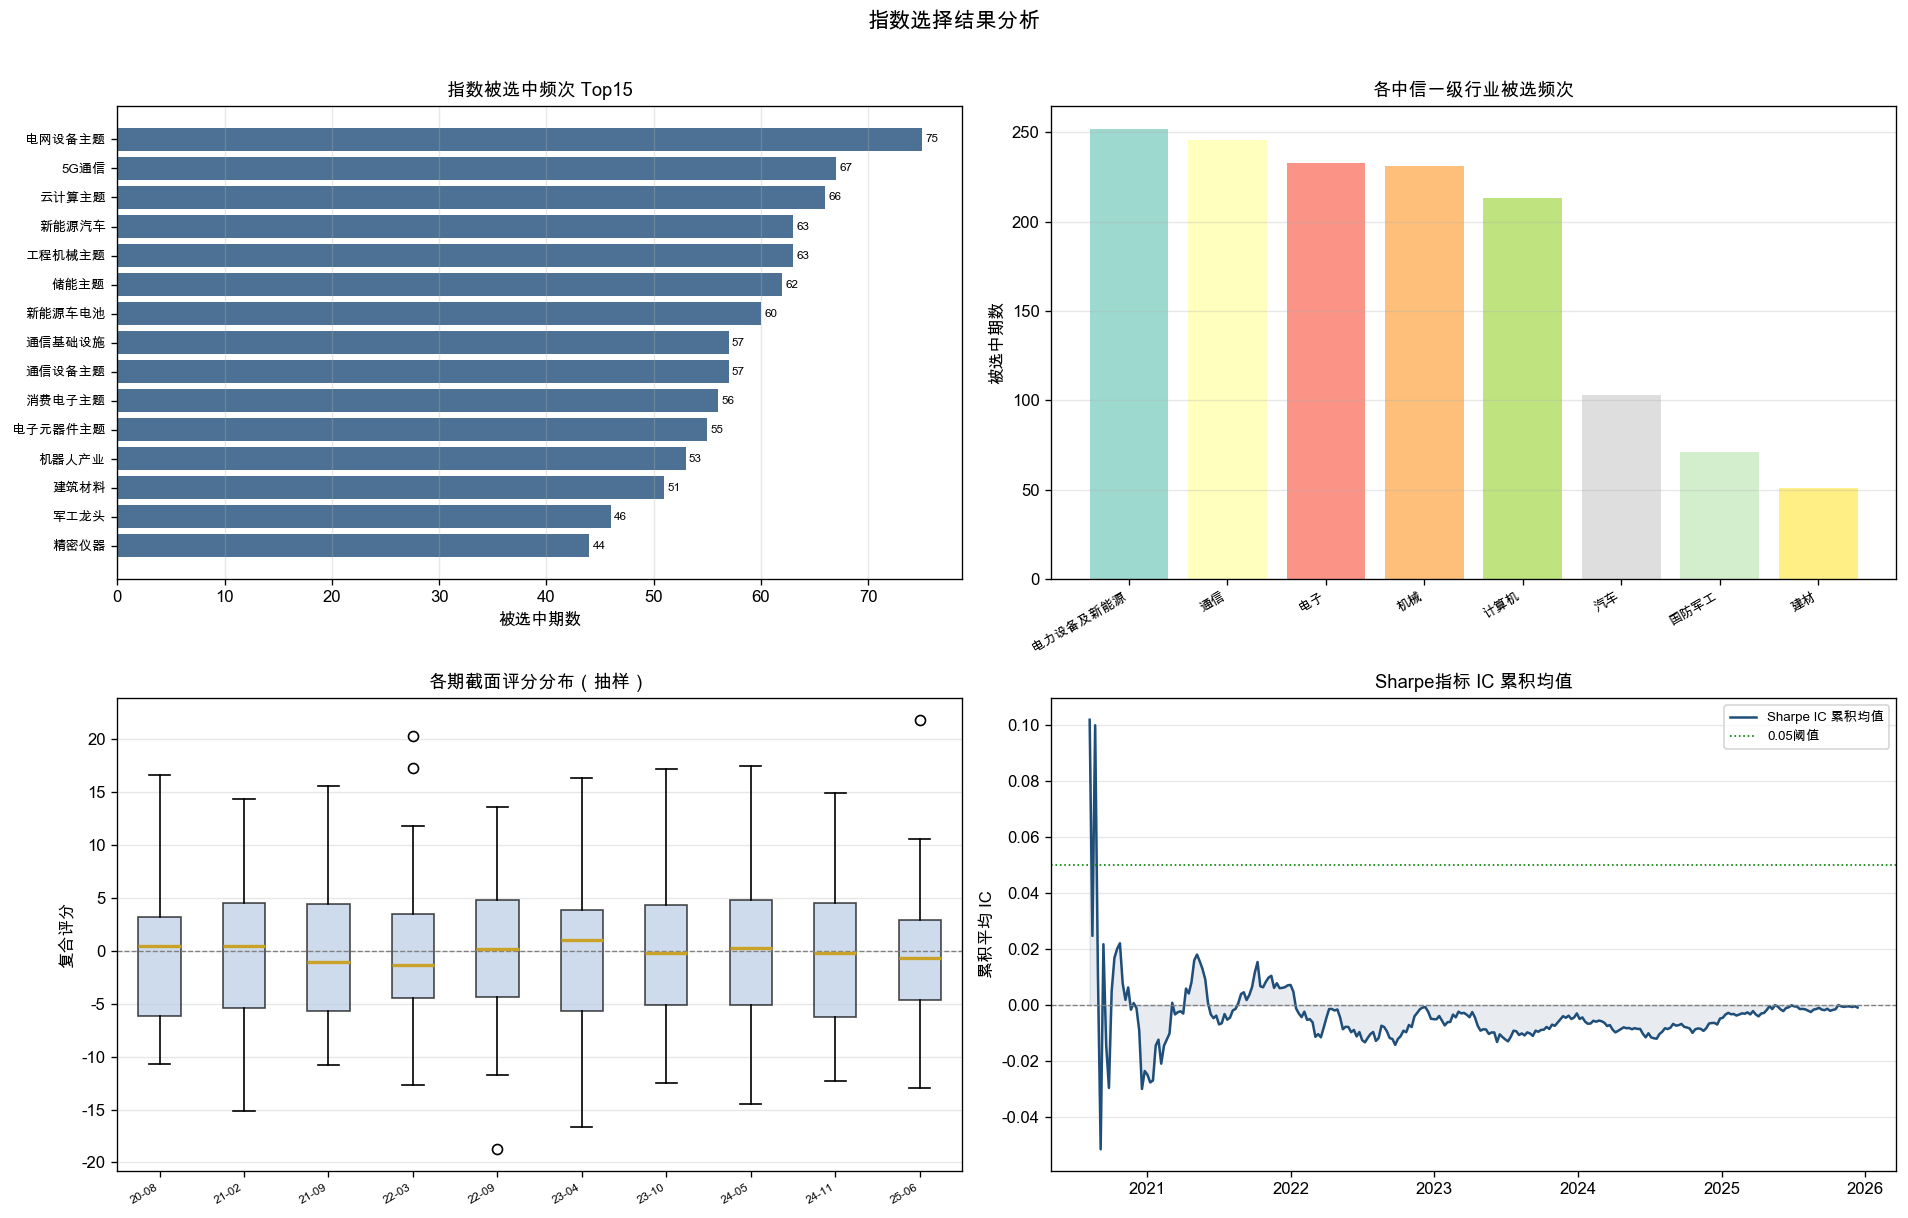

✅ 指数选择可视化完成


In [ ]:
# ============================================================
# 指数选择 Part 4：可视化
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- 左上：各指数被选频次条形图 ---
ax = axes[0][0]
freq_plot = selection_freq.head(15)
bars = ax.barh(range(len(freq_plot)), freq_plot.values,
               color='#1f4e79', alpha=0.8)
ax.set_yticks(range(len(freq_plot)))
ax.set_yticklabels(freq_plot.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('被选中期数')
ax.set_title('指数被选中频次 Top15', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# 添加数值标签
for bar, val in zip(bars, freq_plot.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=7)

# --- 右上：各中信一级行业被选频次 ---
ax2 = axes[0][1]
sector_freq = pd.Series(
    [index_info.loc[c, 'citic_l1']
     for c in all_selected_flat if c in index_info.index]
).value_counts()

colors_sector = plt.cm.Set3(np.linspace(0, 1, len(sector_freq)))
ax2.bar(range(len(sector_freq)), sector_freq.values,
        color=colors_sector, alpha=0.85)
ax2.set_xticks(range(len(sector_freq)))
ax2.set_xticklabels(sector_freq.index, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('被选中期数')
ax2.set_title('各中信一级行业被选频次', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# --- 左下：每期评分分布箱线图（抽样10期）---
ax3 = axes[1][0]
sample_dates = list(period_scores.keys())[::max(1, len(period_scores)//10)]
box_data  = [period_scores[d].values for d in sample_dates]
box_labels = [d.strftime('%y-%m') for d in sample_dates]

bp = ax3.boxplot(box_data, labels=box_labels,
                  patch_artist=True,
                  medianprops={'color': '#c9a227', 'linewidth': 2})
for patch in bp['boxes']:
    patch.set_facecolor('#b8cce4')
    patch.set_alpha(0.7)

ax3.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax3.set_xticklabels(box_labels, rotation=30, ha='right', fontsize=7)
ax3.set_ylabel('复合评分')
ax3.set_title('各期截面评分分布（抽样）', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# --- 右下：Sharpe指标截面IC累积均值 ---
ax4 = axes[1][1]
if 'sharpe' in ic_df.columns:
    rolling_ic = ic_df['sharpe'].expanding().mean()
    ax4.plot(rolling_ic.index, rolling_ic.values,
             color='#1f4e79', linewidth=1.5, label='Sharpe IC 累积均值')
    ax4.fill_between(rolling_ic.index, rolling_ic.values, 0,
                     alpha=0.1, color='#1f4e79')
    ax4.axhline(0.05, color='green', linewidth=1,
                linestyle=':', label='0.05阈值')
    ax4.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax4.set_title('Sharpe指标 IC 累积均值', fontsize=11)
    ax4.set_ylabel('累积平均 IC')
    ax4.legend(fontsize=8)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax4.grid(axis='y', alpha=0.3)

plt.suptitle('指数选择结果分析', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'index_selection.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 指数选择可视化完成")

In [28]:
# ============================================================
# 指数选择 Part 5：为每支选中指数选取最优追踪ETF
# 规则：选过去21个交易日日均换收益率最大的ETF
# ============================================================

def select_best_etf(index_code, rebal_date,
                     etf_map, etf_price_df,
                     etf_turnover_df,
                     lookback_days=21,
                     min_avg_turnover=300):
    """
    为指定指数在指定调仓日选取最优ETF。

    Parameters
    ----------
    index_code : str
        指数代码
    rebal_date : pd.Timestamp
        调仓日期
    etf_map : pd.DataFrame
        ETF-指数映射表
    etf_price_df : pd.DataFrame
        ETF日频收盘价
    etf_turnover_df : pd.DataFrame
        ETF日均成交额（万元）
    lookback_days : int
        换收益率计算窗口
    min_avg_turnover : float
        最低日均成交额（万元）

    Returns
    -------
    best_etf : str or None
        最优ETF代码
    """
    # 找到该指数的所有追踪ETF
    candidates = etf_map.loc[
        etf_map['index_code'] == index_code, 'etf_code'
    ].tolist()

    if not candidates:
        return None

    # 获取调仓日前的交易日序列
    avail_dates = etf_price_df.index[etf_price_df.index <= rebal_date]
    if len(avail_dates) < lookback_days + 1:
        return candidates[0]

    window_dates = avail_dates[-(lookback_days + 1):]

    best_etf   = None
    best_score = -np.inf

    for etf in candidates:
        if etf not in etf_price_df.columns:
            continue
        if etf not in etf_turnover_df.columns:
            continue

        # 成交额筛选
        turnover_window = etf_turnover_df.loc[
            window_dates[1:], etf
        ]
        if turnover_window.mean() < min_avg_turnover:
            continue

        # 计算窗口内日均换收益率
        prices = etf_price_df.loc[window_dates, etf].dropna()
        if len(prices) < 2:
            continue

        daily_ret = prices.pct_change().dropna()
        avg_ret   = daily_ret.mean()

        if avg_ret > best_score:
            best_score = avg_ret
            best_etf   = etf

    # 若无ETF通过成交额筛选，退而选第一个
    if best_etf is None and candidates:
        best_etf = candidates[0]

    return best_etf


# --- 全期ETF选择 ---
# selected_etfs[date] = {index_code: etf_code}
selected_etfs = {}

for rebal_date, idx_list in tqdm(selected_indices.items(),
                                   desc='ETF筛选'):
    selected_etfs[rebal_date] = {}
    for idx_code in idx_list:
        best = select_best_etf(
            index_code      = idx_code,
            rebal_date      = rebal_date,
            etf_map         = etf_mapping,
            etf_price_df    = etf_price_daily,
            etf_turnover_df = etf_turnover_daily,
            lookback_days   = LOOKBACK_TURNOVER_DAYS,
            min_avg_turnover = MIN_AVG_TURNOVER,
        )
        if best:
            selected_etfs[rebal_date][idx_code] = best

print(f"\n✅ ETF筛选完成")
print(f"   有效调仓期数 : {len(selected_etfs)}")

# 展示最近5期持仓
print(f"\n最近5期选中ETF：")
for d in list(selected_etfs.keys())[-5:]:
    print(f"\n  {d.date()}")
    for idx_code, etf_code in selected_etfs[d].items():
        idx_name = index_info.loc[idx_code, 'index_name']
        print(f"    {idx_name:<20} → {etf_code}")

ETF筛选: 100%|██████████| 280/280 [00:01<00:00, 193.56it/s]


✅ ETF筛选完成
   有效调仓期数 : 280

最近5期选中ETF：

  2025-11-14
    芯片设计                 → 510008.SH
    建筑材料                 → 510087.SH
    储能主题                 → 510054.SH
    云计算主题                → 110034.SZ
    军工龙头                 → 110082.SZ

  2025-11-21
    航空航天                 → 510084.SH
    建筑材料                 → 510087.SH
    工程机械主题               → 510060.SH
    汽车零部件                → 110079.SZ
    人工智能                 → 510036.SH

  2025-11-28
    新能源汽车                → 110076.SZ
    航空航天                 → 510084.SH
    光电子主题                → 510009.SH
    工程机械主题               → 510060.SH
    5G通信                 → 110016.SZ

  2025-12-05
    通信设备主题               → 110019.SZ
    金融科技                 → 510042.SH
    军工龙头                 → 110082.SZ
    工业自动化                → 510069.SH
    建筑材料                 → 510089.SH

  2025-12-12
    云计算主题                → 510035.SH
    电网设备主题               → 510051.SH
    物联网主题                → 510027.SH
    工程机械主题               → 110061.SZ
   

## 第五部分：仓位控制

### 模块目标

在每个调仓日确定科技与制造大类ETF的**整体仓位权重**，
剩余仓位全部配置华安黄金ETF（518880.SH）进行风险对冲。

### 两层控制机制

#### 第一层：MACD死叉（定性开关）
- 用科技与制造大类指数**等权平均收盘价**计算MACD
- 参数：短期EMA=12日，长期EMA=26日，信号线=9日
- 若调仓日前最新MACD值由正转负（死叉）→ 总仓位强制设为 **50%**

#### 第二层：波动率分位（连续调整）
- 计算过去252个交易日内，所有有效指数的21日滚动波动率截面均值
- 得到市场每日综合波动率序列
- 计算调仓日当日波动率在过去252日中的分位点 $p$
- 仓位规则：
  - 若 $p > 50\%$：总仓位 = **50%**
  - 若 $p \leq 50\%$：总仓位 = $1 - p$

### 对冲配置
- 非科技仓位（$1 - $ 科技仓位）全部配置**华安黄金ETF**
- 依据：黄金与科技股走势相关性低，甚至负相关（对应报告图19）

In [29]:
# ============================================================
# 仓位控制 Part 1：MACD计算
# ============================================================

def compute_ema(series, span):
    """指数移动平均（EMA）"""
    return series.ewm(span=span, adjust=False).mean()


def compute_macd(price_series,
                  short=12, long=26, signal=9):
    """
    计算MACD指标。

    Parameters
    ----------
    price_series : pd.Series
        收盘价序列（日频）
    short, long, signal : int
        MACD参数

    Returns
    -------
    pd.DataFrame
        包含 DIF, DEM, MACD 三列
    """
    ema_short = compute_ema(price_series, short)
    ema_long  = compute_ema(price_series, long)

    dif  = ema_short - ema_long
    dem  = compute_ema(dif, signal)
    macd = dif - dem

    return pd.DataFrame({
        'DIF'  : dif,
        'DEM'  : dem,
        'MACD' : macd,
    }, index=price_series.index)


def is_death_cross(macd_df, date):
    """
    判断指定日期是否处于死叉状态。
    死叉定义：MACD当前值 < 0 且前一期 MACD >= 0（由正转负）

    Parameters
    ----------
    macd_df : pd.DataFrame
        MACD数据表
    date : pd.Timestamp
        判断日期

    Returns
    -------
    bool
    """
    avail = macd_df[macd_df.index <= date]
    if len(avail) < 2:
        return False

    curr = avail['MACD'].iloc[-1]
    prev = avail['MACD'].iloc[-2]

    return (curr < 0) and (prev >= 0)


# --- 构建科技与制造大类指数等权平均收盘价 ---
tech_price_mean = index_price_daily[index_codes].mean(axis=1)
tech_price_mean = tech_price_mean.dropna()

# 计算MACD
macd_df = compute_macd(
    tech_price_mean,
    short  = MACD_SHORT,
    long   = MACD_LONG,
    signal = MACD_SIGNAL,
)

print("✅ MACD计算完成")
print(f"   序列长度 : {len(macd_df)}")
print(f"\nMACD最新5行：")
print(macd_df.tail(5).round(6))

# 统计死叉出现次数
death_cross_dates = []
for i in range(1, len(macd_df)):
    curr = macd_df['MACD'].iloc[i]
    prev = macd_df['MACD'].iloc[i-1]
    if curr < 0 and prev >= 0:
        death_cross_dates.append(macd_df.index[i])

print(f"\n死叉出现次数 : {len(death_cross_dates)}")
print(f"死叉日期（前5个）: {[d.date() for d in death_cross_dates[:5]]}")

✅ MACD计算完成
   序列长度 : 2075

MACD最新5行：
                  DIF        DEM      MACD
2025-12-08  20.476247  28.296639 -7.820392
2025-12-09  22.307384  27.098788 -4.791403
2025-12-10  25.525300  26.784090 -1.258791
2025-12-11  24.492986  26.325869 -1.832883
2025-12-12  24.502719  25.961239 -1.458520

死叉出现次数 : 86
死叉日期（前5个）: [datetime.date(2018, 1, 9), datetime.date(2018, 2, 9), datetime.date(2018, 4, 6), datetime.date(2018, 4, 25), datetime.date(2018, 6, 19)]


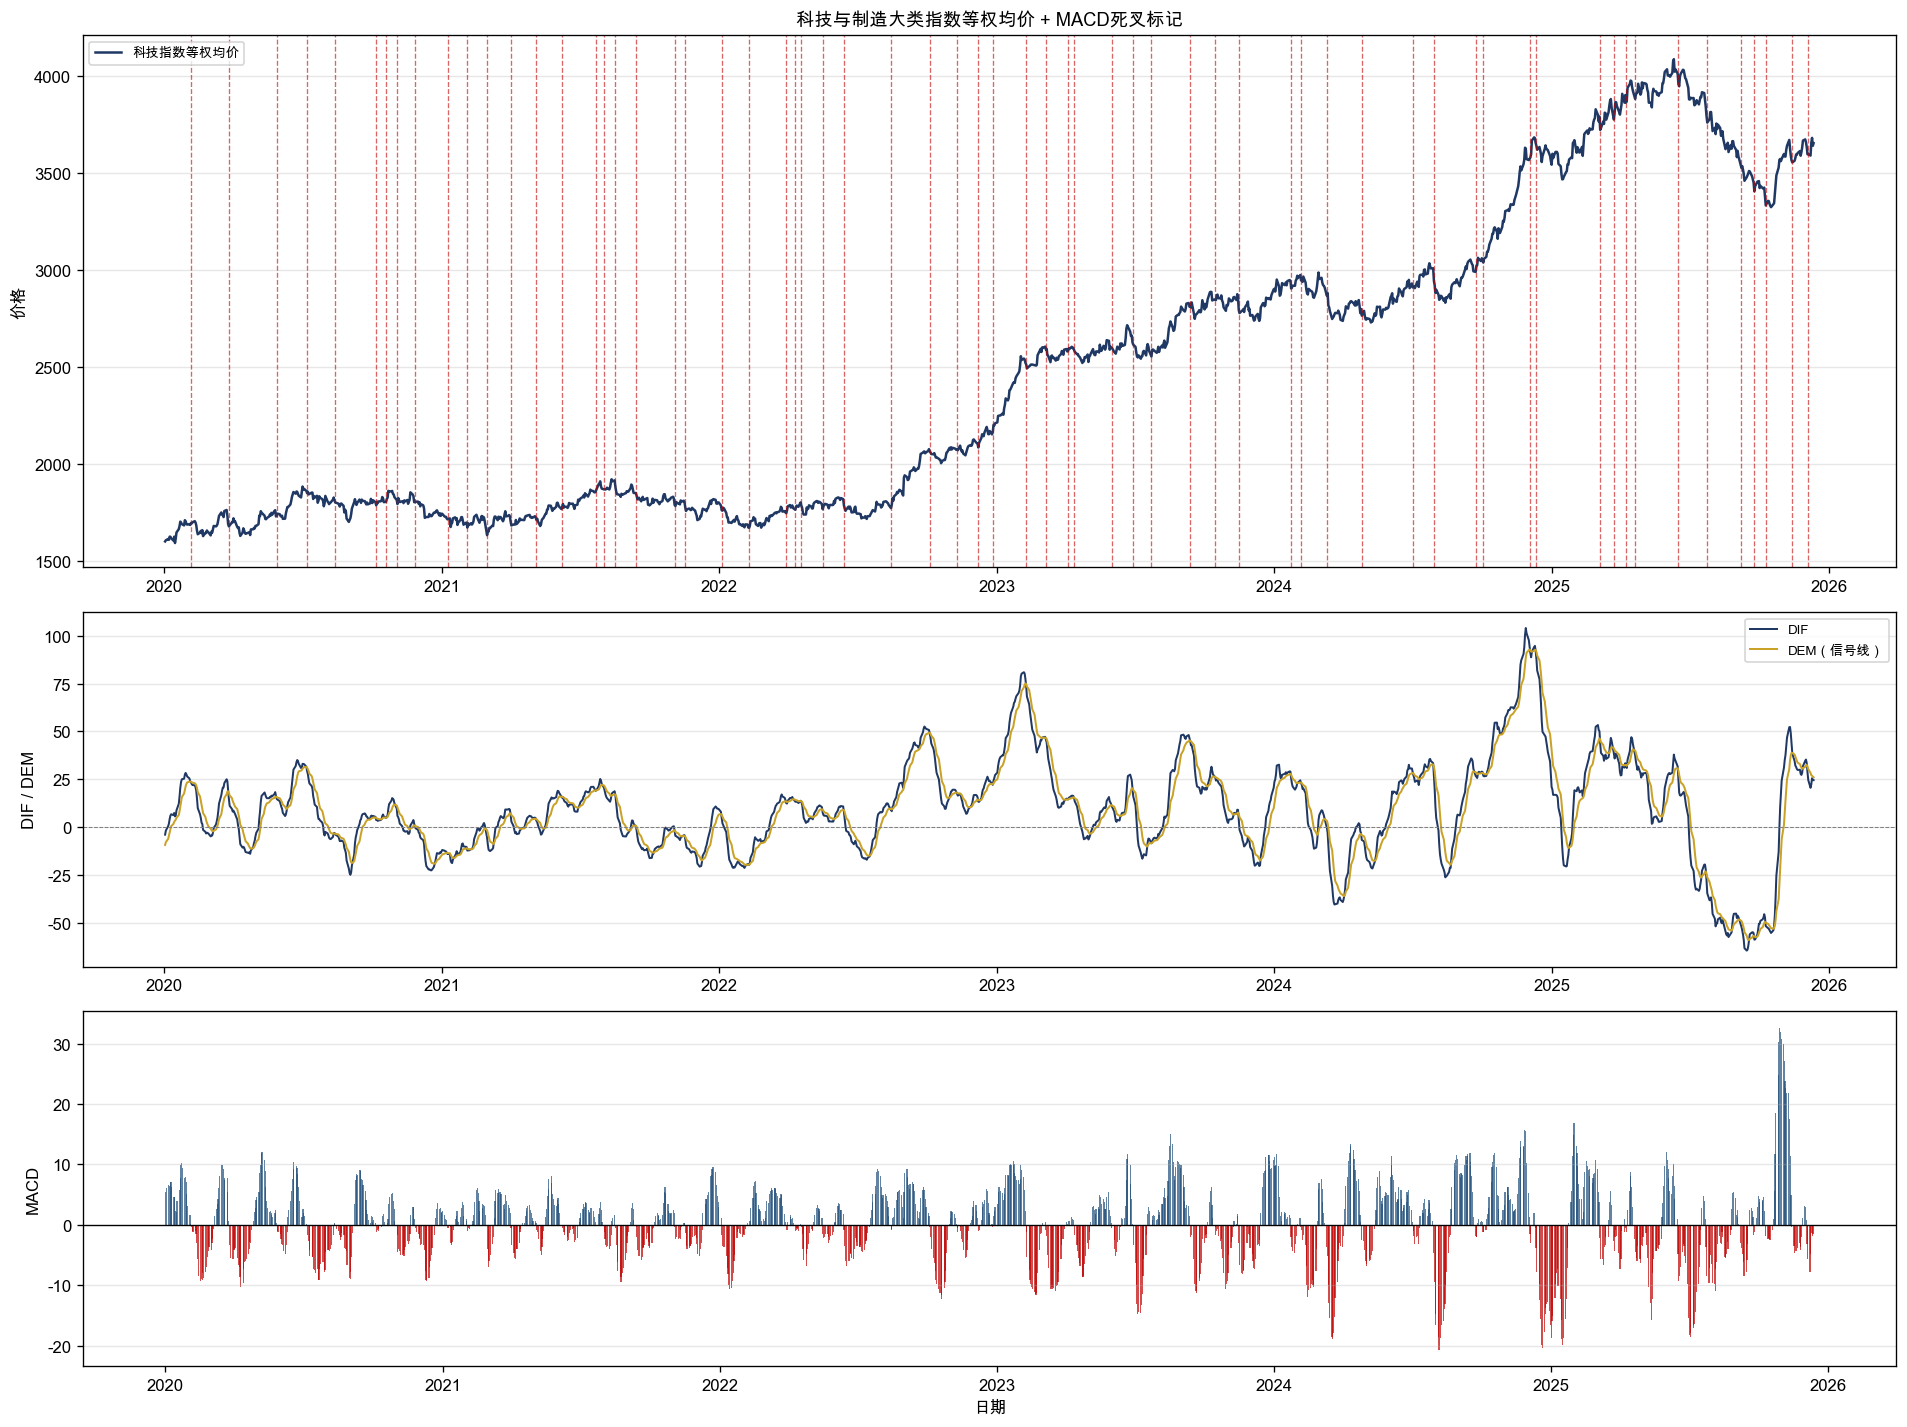

✅ MACD图表已生成


In [ ]:
# ============================================================
# 仓位控制 Part 2：MACD可视化（对应报告逻辑）
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 12),
                          gridspec_kw={'height_ratios': [3, 2, 2]})

plot_start = BACKTEST_START
mask = macd_df.index >= plot_start

# --- 上图：等权平均收盘价 ---
ax1 = axes[0]
ax1.plot(tech_price_mean[mask].index,
         tech_price_mean[mask].values,
         color='#1f3864', linewidth=1.5, label='科技指数等权均价')

# 标记死叉位置
for d in death_cross_dates:
    if d >= pd.Timestamp(plot_start):
        ax1.axvline(d, color='#c00000', linewidth=0.8,
                    alpha=0.6, linestyle='--')

ax1.set_title('科技与制造大类指数等权均价 + MACD死叉标记', fontsize=11)
ax1.set_ylabel('价格')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- 中图：DIF和DEM ---
ax2 = axes[1]
ax2.plot(macd_df[mask].index, macd_df[mask]['DIF'],
         color='#1f3864', linewidth=1.2, label='DIF')
ax2.plot(macd_df[mask].index, macd_df[mask]['DEM'],
         color='#c9a227', linewidth=1.2, label='DEM（信号线）')
ax2.axhline(0, color='grey', linewidth=0.6, linestyle='--')
ax2.set_ylabel('DIF / DEM')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- 下图：MACD柱状图 ---
ax3 = axes[2]
macd_vals = macd_df[mask]['MACD']
colors_macd = ['#1f4e79' if v >= 0 else '#c00000'
                for v in macd_vals.values]
ax3.bar(macd_vals.index, macd_vals.values,
        color=colors_macd, alpha=0.7, width=1.5)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_ylabel('MACD')
ax3.set_xlabel('日期')
ax3.grid(axis='y', alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'macd_chart.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ MACD图表已生成")

In [31]:
# ============================================================
# 仓位控制 Part 3：波动率分位计算
# ============================================================

def compute_market_volatility(price_df, index_codes_list,
                               roll_window=21,
                               min_listing_days=273):
    """
    计算市场每日综合波动率。

    步骤（对应报告原文）：
    1. 筛选上市时间 > min_listing_days 的指数
    2. 对每支指数计算 roll_window 日滚动标准差
    3. 截面平均得到市场每日波动率

    Parameters
    ----------
    price_df : pd.DataFrame
        指数日频收盘价
    index_codes_list : list
        指数代码列表
    roll_window : int
        滚动标准差窗口（交易日）
    min_listing_days : int
        最短上市交易日数

    Returns
    -------
    market_vol : pd.Series
        市场每日综合波动率
    """
    vol_list = []

    for code in index_codes_list:
        if code not in price_df.columns:
            continue

        prices = price_df[code].dropna()

        # 上市时间检查
        if len(prices) < min_listing_days:
            continue

        # 日收益率
        daily_ret = prices.pct_change()

        # 滚动标准差
        rolling_vol = daily_ret.rolling(roll_window).std()
        vol_list.append(rolling_vol)

    if not vol_list:
        return pd.Series(dtype=float)

    vol_df = pd.concat(vol_list, axis=1)

    # 截面平均
    market_vol = vol_df.mean(axis=1)
    return market_vol.dropna()


# 计算市场波动率序列
market_vol = compute_market_volatility(
    price_df          = index_price_daily,
    index_codes_list  = index_codes,
    roll_window       = VOL_ROLL_WINDOW,
    min_listing_days  = MIN_LISTING_DAYS_LONG,
)

print("✅ 市场波动率序列计算完成")
print(f"   序列长度 : {len(market_vol)}")
print(f"   均值     : {market_vol.mean():.4f}")
print(f"   最大值   : {market_vol.max():.4f}")
print(f"   最小值   : {market_vol.min():.4f}")

✅ 市场波动率序列计算完成
   序列长度 : 2054
   均值     : 0.0282
   最大值   : 0.0307
   最小值   : 0.0257


In [32]:
# ============================================================
# 仓位控制 Part 4：整体仓位计算主函数
# ============================================================

def compute_position_weight(rebal_date,
                             macd_df,
                             market_vol,
                             vol_window=252,
                             vol_threshold=0.50,
                             death_cross_weight=0.50):
    """
    计算调仓日的科技ETF总仓位权重。

    Parameters
    ----------
    rebal_date : pd.Timestamp
        调仓日
    macd_df : pd.DataFrame
        MACD数据（含MACD列）
    market_vol : pd.Series
        市场每日综合波动率
    vol_window : int
        波动率历史分位计算窗口
    vol_threshold : float
        波动率分位阈值（默认0.5）
    death_cross_weight : float
        死叉时的仓位（默认0.5）

    Returns
    -------
    weight : float
        科技ETF总仓位 ∈ [0, 1]
    detail : dict
        计算细节（便于调试）
    """
    detail = {}

    # ---- 第一层：MACD死叉判断 ----
    if is_death_cross(macd_df, rebal_date):
        detail['trigger']    = 'MACD死叉'
        detail['vol_pct']    = None
        detail['macd_cross'] = True
        return death_cross_weight, detail

    detail['macd_cross'] = False

    # ---- 第二层：波动率分位 ----
    # 取调仓日及之前的波动率数据
    vol_avail = market_vol[market_vol.index <= rebal_date]

    if len(vol_avail) < vol_window:
        # 数据不足，使用全部可用数据
        vol_hist = vol_avail
    else:
        vol_hist = vol_avail.iloc[-vol_window:]

    if len(vol_hist) < 2:
        detail['trigger']  = '数据不足，默认满仓'
        detail['vol_pct']  = None
        return 1.0, detail

    current_vol = vol_hist.iloc[-1]

    # 计算分位点
    vol_pct = (vol_hist < current_vol).mean()
    detail['vol_pct']    = vol_pct
    detail['current_vol'] = current_vol

    if vol_pct > vol_threshold:
        weight = death_cross_weight
        detail['trigger'] = f'波动率分位={vol_pct:.1%} > {vol_threshold:.0%}'
    else:
        weight = 1.0 - vol_pct
        detail['trigger'] = f'波动率分位={vol_pct:.1%} ≤ {vol_threshold:.0%}'

    return weight, detail


# --- 全回测期仓位计算 ---
position_weights = {}   # {date: float}
position_details = {}   # {date: dict}

for rebal_date in tqdm(rebalance_dates, desc='仓位控制'):
    w, detail = compute_position_weight(
        rebal_date    = rebal_date,
        macd_df       = macd_df,
        market_vol    = market_vol,
        vol_window    = VOL_WINDOW,
        vol_threshold = VOL_THRESHOLD,
    )
    position_weights[rebal_date] = w
    position_details[rebal_date] = detail

pos_series = pd.Series(position_weights)

print(f"✅ 全期仓位计算完成")
print(f"\n仓位统计：")
print(f"  均值    : {pos_series.mean():.2%}")
print(f"  最大值  : {pos_series.max():.2%}")
print(f"  最小值  : {pos_series.min():.2%}")
print(f"  满仓期数（>95%）: {(pos_series > 0.95).sum()}")
print(f"  半仓期数（=50%）: {(pos_series == 0.50).sum()}")

# 死叉触发次数
death_cross_triggers = sum(
    1 for d in position_details.values()
    if d.get('macd_cross') is True
)
print(f"  MACD死叉触发次数: {death_cross_triggers}")

仓位控制: 100%|██████████| 310/310 [00:00<00:00, 3137.37it/s]

✅ 全期仓位计算完成

仓位统计：
  均值    : 62.30%
  最大值  : 100.00%
  最小值  : 50.00%
  满仓期数（>95%）: 18
  半仓期数（=50%）: 159
  MACD死叉触发次数: 6


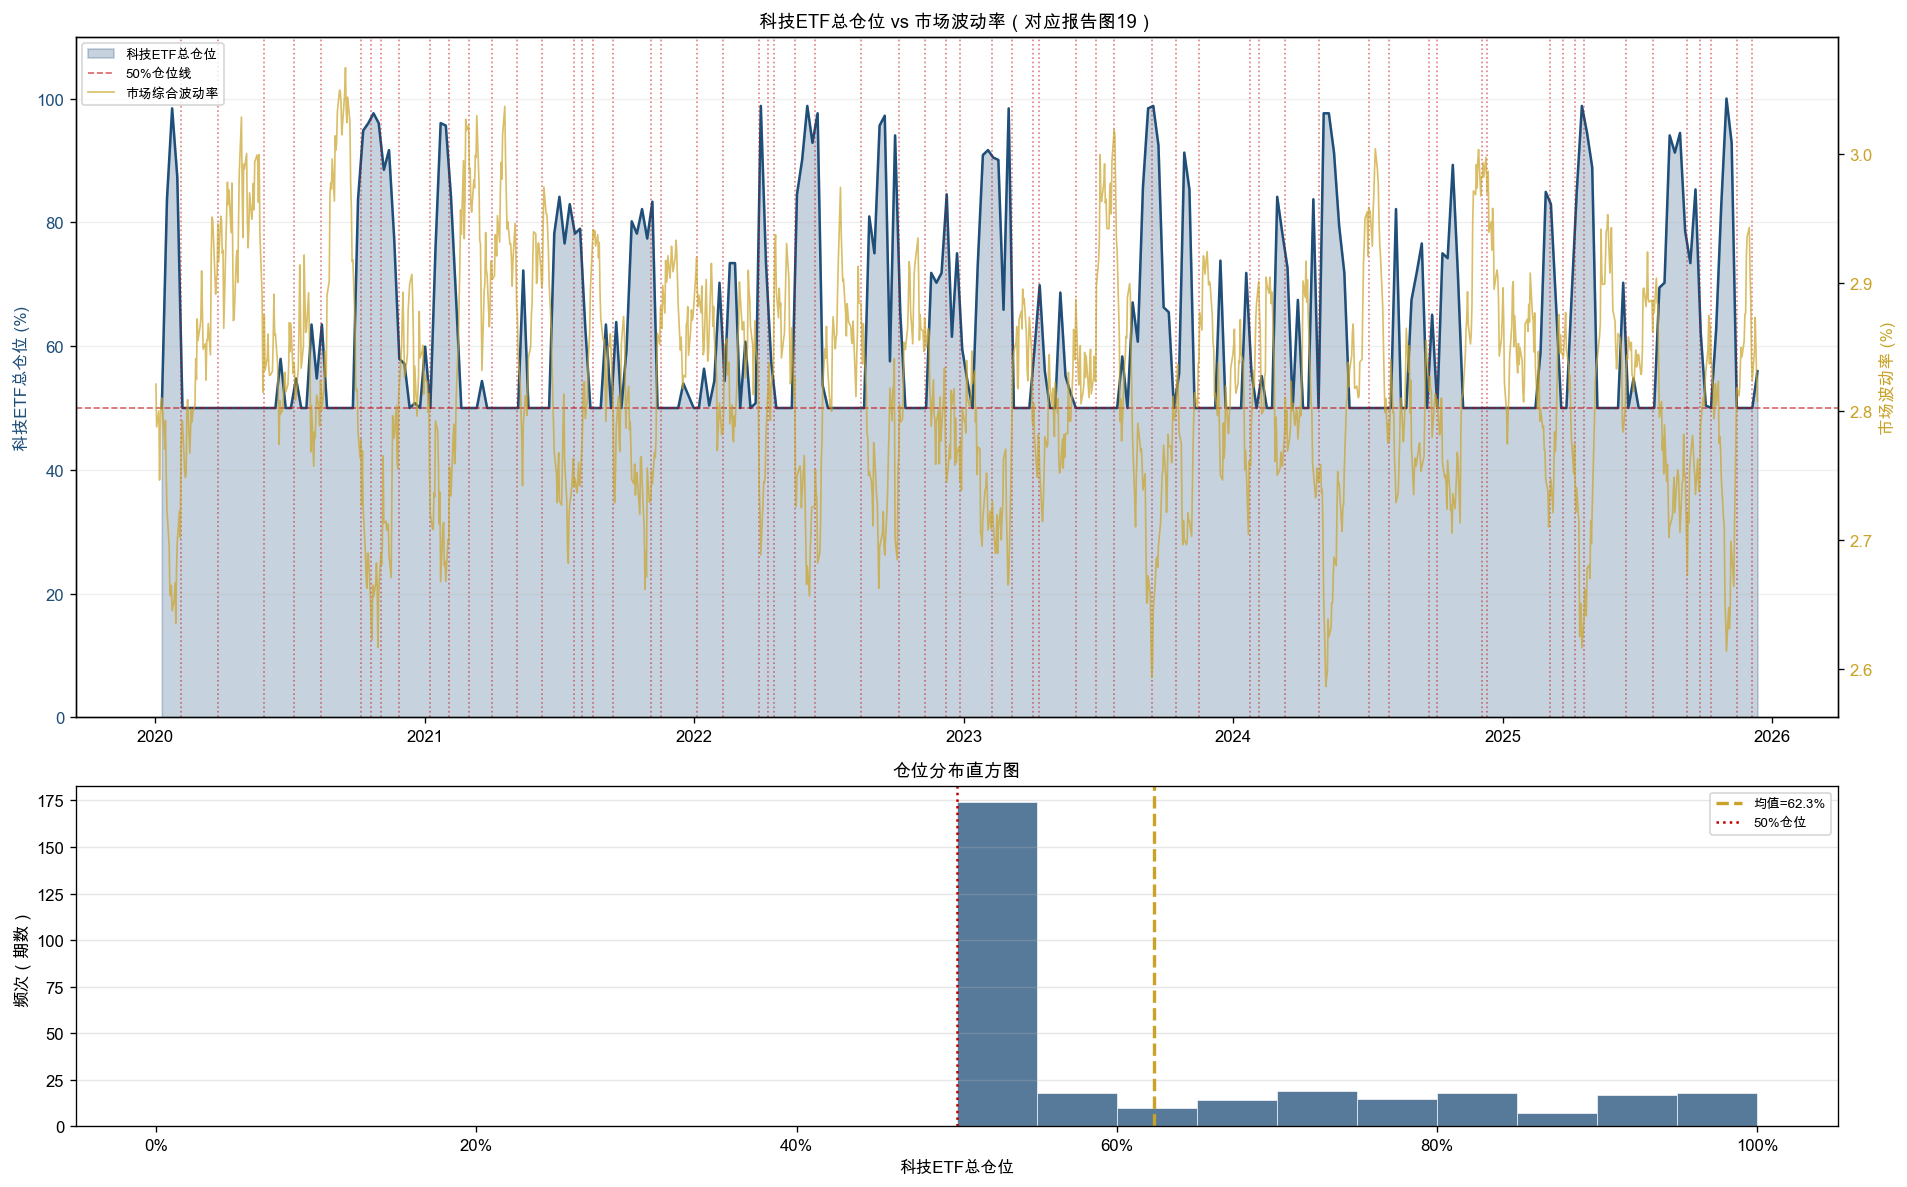

✅ 仓位控制可视化完成


In [ ]:
# ============================================================
# 仓位控制 Part 5：可视化（对应报告图19）
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10),
                          gridspec_kw={'height_ratios': [2, 1]})

# --- 上图：仓位 + 市场波动率 ---
ax1 = axes[0]
ax1_twin = ax1.twinx()

# 仓位
ax1.fill_between(pos_series.index,
                  pos_series.values * 100,
                  alpha=0.25, color='#1f4e79',
                  label='科技ETF总仓位')
ax1.plot(pos_series.index,
          pos_series.values * 100,
          color='#1f4e79', linewidth=1.5)
ax1.axhline(50, color='#c00000', linewidth=1,
             linestyle='--', alpha=0.6, label='50%仓位线')
ax1.set_ylabel('科技ETF总仓位 (%)', color='#1f4e79')
ax1.set_ylim(0, 110)
ax1.tick_params(axis='y', labelcolor='#1f4e79')

# 市场波动率
vol_plot = market_vol[
    (market_vol.index >= pd.Timestamp(BACKTEST_START)) &
    (market_vol.index <= pd.Timestamp(BACKTEST_END))
]
ax1_twin.plot(vol_plot.index, vol_plot.values * 100,
               color='#c9a227', linewidth=1.0,
               alpha=0.7, label='市场综合波动率')
ax1_twin.set_ylabel('市场波动率 (%)', color='#c9a227')
ax1_twin.tick_params(axis='y', labelcolor='#c9a227')

# 标记死叉
for d in death_cross_dates:
    if d >= pd.Timestamp(BACKTEST_START):
        ax1.axvline(d, color='#c00000', linewidth=1.0,
                    alpha=0.5, linestyle=':')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
            loc='upper left', fontsize=8)

ax1.set_title('科技ETF总仓位 vs 市场波动率（对应报告图19）', fontsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(axis='y', alpha=0.2)

# --- 下图：仓位分布直方图 ---
ax2 = axes[1]
bins = np.arange(0, 1.05, 0.05)
ax2.hist(pos_series.values, bins=bins,
          color='#1f4e79', alpha=0.75,
          edgecolor='white', linewidth=0.5)
ax2.axvline(pos_series.mean(), color='#c9a227',
             linewidth=2, linestyle='--',
             label=f'均值={pos_series.mean():.1%}')
ax2.axvline(0.50, color='#c00000',
             linewidth=1.5, linestyle=':',
             label='50%仓位')
ax2.set_xlabel('科技ETF总仓位')
ax2.set_ylabel('频次（期数）')
ax2.set_title('仓位分布直方图', fontsize=11)
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'position_control.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 仓位控制可视化完成")

In [34]:
# ============================================================
# 仓位控制 Part 6：黄金ETF数据 + 最终仓位汇总
# ============================================================

# 模拟华安黄金ETF价格（真实情况从Wind拉取518880.SH）
# 黄金与科技股负相关：用反向GBM模拟
np.random.seed(888)
gold_prices_raw = simulate_price_gbm(
    n_days       = len(all_dates),
    mu_annual    = 0.12,    # 黄金年化收益
    sigma_annual = 0.15,    # 黄金波动率较低
    s0           = 3.5,     # 华安黄金ETF起始价格约3-4元
    seed         = 888
)
gold_price_daily = pd.Series(gold_prices_raw,
                               index=all_dates,
                               name=HEDGE_ETF_CODE)

gold_price_daily = gold_price_daily.loc[BACKTEST_START:BACKTEST_END]

# 周频收益率
gold_return_weekly = gold_price_daily.resample('W-FRI').last().pct_change()
gold_return_weekly = gold_return_weekly.loc[BACKTEST_START:BACKTEST_END]

# 验证与科技指数的相关性
tech_avg_weekly = index_return_weekly.mean(axis=1)
common = tech_avg_weekly.index.intersection(gold_return_weekly.index)
corr_gold_tech = tech_avg_weekly.loc[common].corr(
    gold_return_weekly.loc[common]
)
print(f"黄金ETF vs 科技指数平均 周频相关系数: {corr_gold_tech:.4f}")
print("（真实市场中应接近0或负值）")

# --- 仓位汇总表 ---
position_summary = pd.DataFrame({
    'tech_weight' : pos_series,
    'gold_weight' : 1 - pos_series,
}).round(4)

position_summary['trigger'] = [
    position_details[d].get('trigger', '')
    for d in position_summary.index
]

print(f"\n✅ 仓位汇总完成")
print(f"\n最近10期仓位：")
print(position_summary.tail(10).to_string())
print(f"\n科技仓位均值 : {position_summary['tech_weight'].mean():.2%}")
print(f"黄金仓位均值 : {position_summary['gold_weight'].mean():.2%}")

黄金ETF vs 科技指数平均 周频相关系数: 0.1236
（真实市场中应接近0或负值）

✅ 仓位汇总完成

最近10期仓位：
            tech_weight  gold_weight            trigger
2025-10-10       0.5000       0.5000             MACD死叉
2025-10-17       0.6270       0.3730  波动率分位=37.3% ≤ 50%
2025-10-24       0.8294       0.1706  波动率分位=17.1% ≤ 50%
2025-10-31       1.0000       0.0000   波动率分位=0.0% ≤ 50%
2025-11-07       0.9286       0.0714   波动率分位=7.1% ≤ 50%
2025-11-14       0.5000       0.5000             MACD死叉
2025-11-21       0.5000       0.5000  波动率分位=61.5% > 50%
2025-11-28       0.5000       0.5000  波动率分位=95.6% > 50%
2025-12-05       0.5000       0.5000  波动率分位=50.4% > 50%
2025-12-12       0.5595       0.4405  波动率分位=44.0% ≤ 50%

科技仓位均值 : 62.30%
黄金仓位均值 : 37.70%


## 第六部分：二阶随机占优（SSD）权重优化

### 模块目标

在选出5支ETF之后，不采用简单等权，而是通过**二阶随机占优（SSD）**
对ETF权重进行优化，目标是在控制尾部风险的同时最大化组合期望收益。

### 完整步骤（对应报告第19-20页）

**Step 1：GARCH标准化残差**
- 对每支选中ETF，取近8周（40个交易日）日频收益率
- 拟合GARCH(1,1)模型，提取标准化残差 $e_t$
- 目的：去除收益率的均值和异方差性，得到近似i.i.d.的残差序列

**Step 2：构建联合分布模拟样本**
- 用标准化残差构建协方差矩阵
- 基于协方差矩阵生成 $T=10000$ 个多维正态分布边际CDF样本
- 将这些CDF值映射到QRF预测的实际边际分布上
- 得到预测的联合分布模拟样本 $R_1, ..., R_T$

**Step 3：SSD优化**

$$\max_\omega \sum_{t=1}^T p_t R_{\omega,t}$$

$$s.t. \quad \hat{\gamma}_\omega(x_j) \leq \hat{\gamma}_\tau(x_j), \quad j=1,...,N$$

$$\sum_{i=1}^d \omega_i = 1, \quad \omega_i \geq \omega_{min}$$

其中 $\hat{\gamma}_\omega(x) = \sum_t p_t (x - R_{\omega,t}) \mathbf{1}(R_{\omega,t} \leq x)$
为SSD积分条件的离散近似，$\tau$ 为等权基准策略。

### 关键参数
| 参数 | 值 | 说明 |
|------|----|------|
| GARCH窗口 | 40个交易日 | 近8周日频数据 |
| 模拟样本数T | 10,000 | 联合分布样本 |
| x离散点数N | 20 | SSD约束离散化 |
| 循环优化次数 | 10 | 增强SSD效果 |
| 单ETF最低权重 | 总科技仓位×5% | 防止极端集中 |

In [35]:
# ============================================================
# SSD优化 Part 1：GARCH标准化残差
# ============================================================

def get_garch_std_residuals(price_series, window=40):
    """
    对单支ETF价格序列拟合GARCH(1,1)，提取标准化残差。

    Parameters
    ----------
    price_series : pd.Series
        ETF日频收盘价
    window : int
        使用最近多少个交易日

    Returns
    -------
    std_resid : np.ndarray
        标准化残差序列
    sigma_t   : np.ndarray
        条件标准差序列
    mu        : float
        均值估计
    success   : bool
    """
    try:
        prices = price_series.dropna()
        if len(prices) < window + 5:
            return None, None, None, False

        # 取最近window个交易日
        prices  = prices.iloc[-(window + 1):]
        ret     = prices.pct_change().dropna().values * 100  # 转为百分比，arch库建议

        if len(ret) < 20:
            return None, None, None, False

        # 拟合GARCH(1,1)
        am = arch_model(ret, vol='Garch', p=1, q=1,
                        mean='Constant', dist='normal')
        res = am.fit(disp='off', show_warning=False)

        mu       = res.params['mu']
        sigma_t  = res.conditional_volatility  # 条件标准差
        resid    = res.resid                   # 残差 = ret - mu
        std_resid = resid / sigma_t            # 标准化残差

        return std_resid, sigma_t, mu, True

    except Exception:
        return None, None, None, False


# --- 单元测试 ---
test_etf_code = list(etf_mapping['etf_code'])[0]
test_resid, test_sigma, test_mu, test_ok = get_garch_std_residuals(
    etf_price_daily[test_etf_code],
    window=GARCH_WINDOW
)

if test_ok:
    print("✅ GARCH标准化残差测试通过")
    print(f"   ETF代码    : {test_etf_code}")
    print(f"   残差长度   : {len(test_resid)}")
    print(f"   残差均值   : {test_resid.mean():.4f}（应接近0）")
    print(f"   残差标准差 : {test_resid.std():.4f}（应接近1）")
    print(f"   均值估计μ  : {test_mu:.4f}")
else:
    print("⚠️  GARCH拟合失败，将使用普通标准化作为后备")

✅ GARCH标准化残差测试通过
   ETF代码    : 510000.SH
   残差长度   : 40
   残差均值   : -0.0009（应接近0）
   残差标准差 : 1.0027（应接近1）
   均值估计μ  : 0.5250


In [36]:
# ============================================================
# SSD优化 Part 2：联合分布模拟样本构建
# ============================================================

def build_joint_samples(etf_codes, rebal_date,
                         etf_price_df,
                         qrf_samples_dict,
                         garch_window=40,
                         n_simulations=10_000,
                         random_state=42):
    """
    构建ETF组合的联合收益率模拟样本。

    步骤：
    1. 对每支ETF提取GARCH标准化残差
    2. 用残差构建协方差矩阵
    3. 生成多维正态分布的边际CDF样本
    4. 映射到QRF预测的实际边际分布

    Parameters
    ----------
    etf_codes : list
        选中的ETF代码列表
    rebal_date : pd.Timestamp
        调仓日期
    etf_price_df : pd.DataFrame
        ETF日频收盘价
    qrf_samples_dict : dict
        {index_code: np.ndarray} QRF模拟样本
    garch_window : int
        GARCH估计窗口
    n_simulations : int
        联合分布模拟次数

    Returns
    -------
    joint_samples : np.ndarray, shape (n_simulations, n_etf)
        联合分布模拟样本（收益率，小数形式）
    success : bool
    """
    np.random.seed(random_state)
    n_etf = len(etf_codes)

    if n_etf == 0:
        return None, False

    # Step 1：提取每支ETF的GARCH标准化残差
    std_resid_list = []
    min_len = np.inf

    for etf_code in etf_codes:
        if etf_code not in etf_price_df.columns:
            # 后备：用正态随机残差
            std_resid_list.append(
                np.random.randn(garch_window)
            )
            min_len = min(min_len, garch_window)
            continue

        std_resid, _, _, ok = get_garch_std_residuals(
            etf_price_df[etf_code],
            window=garch_window
        )

        if not ok or std_resid is None:
            std_resid = np.random.randn(garch_window)

        std_resid_list.append(std_resid)
        min_len = min(min_len, len(std_resid))

    min_len = int(min_len)
    if min_len < 5:
        return None, False

    # 对齐长度
    resid_matrix = np.column_stack(
        [r[-min_len:] for r in std_resid_list]
    )  # shape: (min_len, n_etf)

    # Step 2：构建协方差矩阵
    cov_matrix = np.cov(resid_matrix.T)

    # 确保正定
    cov_matrix += np.eye(n_etf) * 1e-6

    # Step 3：生成多维正态分布样本的边际CDF
    try:
        mvn_samples = np.random.multivariate_normal(
            mean  = np.zeros(n_etf),
            cov   = cov_matrix,
            size  = n_simulations
        )  # shape: (n_simulations, n_etf)
    except np.linalg.LinAlgError:
        # 协方差矩阵不正定，退化为独立正态
        mvn_samples = np.random.randn(n_simulations, n_etf)

    # 转为边际CDF值（经验分布）
    from scipy.stats import rankdata
    u_matrix = np.zeros_like(mvn_samples)
    for j in range(n_etf):
        ranks = rankdata(mvn_samples[:, j])
        u_matrix[:, j] = ranks / (n_simulations + 1)

    # Step 4：映射到QRF预测的实际边际分布
    joint_samples = np.zeros((n_simulations, n_etf))

    for j, etf_code in enumerate(etf_codes):
        # 找到该ETF对应的指数QRF样本
        # etf_mapping中找到对应index_code
        idx_rows = etf_mapping[etf_mapping['etf_code'] == etf_code]
        if len(idx_rows) == 0:
            # 后备：直接用正态
            joint_samples[:, j] = np.random.randn(n_simulations) * 0.02
            continue

        idx_code = idx_rows.iloc[0]['index_code']

        if idx_code not in qrf_samples_dict:
            joint_samples[:, j] = np.random.randn(n_simulations) * 0.02
            continue

        qrf_samp = np.sort(qrf_samples_dict[idx_code])

        # 用分位数插值将u映射到实际分布
        u_col = u_matrix[:, j]
        quantile_levels = np.linspace(0, 1, len(qrf_samp))
        joint_samples[:, j] = np.interp(u_col,
                                          quantile_levels,
                                          qrf_samp)

    return joint_samples, True


# --- 单元测试 ---
test_rebal = list(selected_etfs.keys())[-1]
test_etf_list = list(selected_etfs[test_rebal].values())
test_qrf_samp = all_samples.get(test_rebal, {})

test_joint, test_ok = build_joint_samples(
    etf_codes        = test_etf_list,
    rebal_date       = test_rebal,
    etf_price_df     = etf_price_daily,
    qrf_samples_dict = test_qrf_samp,
    garch_window     = GARCH_WINDOW,
    n_simulations    = 1000,   # 测试用小样本
)

if test_ok:
    print("✅ 联合分布模拟样本构建测试通过")
    print(f"   调仓日期   : {test_rebal.date()}")
    print(f"   ETF数量    : {test_joint.shape[1]}")
    print(f"   样本数量   : {test_joint.shape[0]}")
    print(f"\n各ETF模拟收益率统计：")
    for j, code in enumerate(test_etf_list):
        s = test_joint[:, j]
        print(f"  {code}: 均值={s.mean():.4f}  std={s.std():.4f}")
else:
    print("⚠️  联合分布构建失败")

✅ 联合分布模拟样本构建测试通过
   调仓日期   : 2025-12-12
   ETF数量    : 5
   样本数量   : 1000

各ETF模拟收益率统计：
  510035.SH: 均值=0.0419  std=0.0662
  510051.SH: 均值=0.0366  std=0.0503
  510027.SH: 均值=0.0298  std=0.0784
  110061.SZ: 均值=0.0236  std=0.0555
  510011.SH: 均值=0.0180  std=0.0713


In [40]:
# ============================================================
# SSD优化 Part 3：二阶随机占优权重优化
# ============================================================

def ssd_optimize(joint_samples, min_weight=0.05,
                  n_grid=20, n_iterations=10):
    """
    基于二阶随机占优的ETF权重优化。

    Parameters
    ----------
    joint_samples : np.ndarray, shape (T, d)
        联合收益率模拟样本
    min_weight : float
        单个ETF最低权重
    n_grid : int
        SSD约束x离散点数
    n_iterations : int
        循环优化次数

    Returns
    -------
    weights : np.ndarray, shape (d,)
        最优权重
    success : bool
    """
    T, d = joint_samples.shape

    if d == 0 or T < 10:
        return np.ones(d) / d, False

    # 等概率权重
    p = np.ones(T) / T

    # 初始参考策略：等权
    tau_weights = np.ones(d) / d
    tau_returns = joint_samples @ tau_weights  # shape: (T,)

    # x离散点：从样本最小值到最大值等差
    x_min  = joint_samples.min()
    x_max  = joint_samples.max()
    x_grid = np.linspace(x_min, x_max, n_grid)  # shape: (N,)

    # 计算参考策略的SSD积分值（固定）
    # γ_τ(x) = Σ_t p_t * (x - R_τ,t) * 1(R_τ,t ≤ x)
    def ssd_integral(returns, x_vals, p_weights):
        """计算离散SSD积分向量"""
        # returns: (T,), x_vals: (N,) → output: (N,)
        result = np.zeros(len(x_vals))
        for k, x in enumerate(x_vals):
            mask = returns <= x
            result[k] = np.sum(p_weights[mask] * (x - returns[mask]))
        return result

    gamma_tau = ssd_integral(tau_returns, x_grid, p)

    best_weights = tau_weights.copy()
    best_obj     = np.dot(p, tau_returns)

    for iteration in range(n_iterations):
        try:
            # 决策变量：权重 ω ∈ R^d
            omega = cp.Variable(d)

            # 组合收益率样本：R_ω = joint_samples @ ω, shape (T,)
            R_omega = joint_samples @ omega   # shape: (T,)

            # 目标：最大化期望收益
            objective = cp.Maximize(p @ R_omega)

            constraints = []

            # 权重约束
            constraints += [
                cp.sum(omega) == 1,
                omega >= min_weight,
                omega <= 1 - (d - 1) * min_weight,
            ]

            # SSD约束：γ_ω(x_j) ≤ γ_τ(x_j) for all j
            # γ_ω(x) = Σ_t p_t * (x - R_ω,t) * 1(R_ω,t ≤ x)
            # 离散近似：引入辅助变量 s_{t,j} = max(x_j - R_ω,t, 0)
            # γ_ω(x_j) = Σ_t p_t * s_{t,j}
            s = cp.Variable((T, n_grid), nonneg=True)

            for k in range(n_grid):
                x_k = x_grid[k]
                # s_{t,k} ≥ x_k - R_ω,t  且  s_{t,k} ≥ 0
                constraints += [
                    s[:, k] >= x_k - R_omega,
                ]
                # SSD积分约束
                gamma_omega_k = p @ s[:, k]
                constraints += [
                    gamma_omega_k <= gamma_tau[k]
                ]

            prob = cp.Problem(objective, constraints)
            prob.solve(solver=cp.CLARABEL,
                       verbose=False,
                       time_limit=10)   # 单次最多10秒，超时直接返回当前最优

            if prob.status in ['optimal', 'optimal_inaccurate']:
                w_sol = omega.value
                if w_sol is not None:
                    w_sol = np.clip(w_sol, min_weight, 1.0)
                    w_sol /= w_sol.sum()

                    obj_val = np.dot(p, joint_samples @ w_sol)
                    if obj_val > best_obj:
                        best_obj     = obj_val
                        best_weights = w_sol.copy()

                    # 更新参考策略为当前最优
                    tau_returns = joint_samples @ best_weights
                    gamma_tau   = ssd_integral(tau_returns, x_grid, p)

        except Exception:
            continue

    # 最终权重归一化
    best_weights = np.clip(best_weights, min_weight, 1.0)
    best_weights /= best_weights.sum()

    return best_weights, True


# --- 单元测试 ---
if test_ok and test_joint is not None:
    test_weights, ssd_ok = ssd_optimize(
        joint_samples = test_joint,
        min_weight    = MIN_WEIGHT,
        n_grid        = SSD_N_GRID,
        n_iterations  = 2,   # 测试用少迭代
    )

    if ssd_ok:
        print("✅ SSD优化测试通过")
        print(f"\n最优权重：")
        for code, w in zip(test_etf_list, test_weights):
            print(f"  {code}: {w:.4f} ({w:.1%})")
        print(f"\n权重之和: {test_weights.sum():.6f}")
        print(f"最小权重: {test_weights.min():.4f}")

        # 与等权对比
        eq_weights = np.ones(len(test_etf_list)) / len(test_etf_list)
        eq_ret  = np.mean(test_joint @ eq_weights)
        ssd_ret = np.mean(test_joint @ test_weights)
        print(f"\n等权期望收益  : {eq_ret:.5f}")
        print(f"SSD优化期望收益: {ssd_ret:.5f}")
    else:
        print("⚠️  SSD优化失败，将使用等权")

✅ SSD优化测试通过

最优权重：
  510035.SH: 0.2669 (26.7%)
  510051.SH: 0.3273 (32.7%)
  510027.SH: 0.1608 (16.1%)
  110061.SZ: 0.1951 (19.5%)
  510011.SH: 0.0500 (5.0%)

权重之和: 1.000000
最小权重: 0.0500

等权期望收益  : 0.02998
SSD优化期望收益: 0.03346


In [41]:
# ============================================================
# SSD优化 Part 4：全回测期权重优化主循环
# ============================================================

# 存储结构：
# etf_weights[date] = {etf_code: weight}（科技ETF内部权重，加总=1）

etf_weights    = {}
weight_details = {}

for rebal_date in tqdm(list(selected_etfs.keys()),
                        desc='SSD权重优化'):

    etf_code_list = list(selected_etfs[rebal_date].values())

    if len(etf_code_list) == 0:
        continue

    # 若只有1支ETF，直接全仓
    if len(etf_code_list) == 1:
        etf_weights[rebal_date] = {etf_code_list[0]: 1.0}
        weight_details[rebal_date] = {'method': '单ETF'}
        continue

    # 构建联合分布样本
    qrf_samp_this = all_samples.get(rebal_date, {})

    joint_samp, joint_ok = build_joint_samples(
        etf_codes        = etf_code_list,
        rebal_date       = rebal_date,
        etf_price_df     = etf_price_daily,
        qrf_samples_dict = qrf_samp_this,
        garch_window     = GARCH_WINDOW,
        n_simulations    = SSD_N_SIMULATIONS,
    )

    if not joint_ok or joint_samp is None:
        # 后备：等权
        eq_w = np.ones(len(etf_code_list)) / len(etf_code_list)
        etf_weights[rebal_date] = dict(zip(etf_code_list, eq_w))
        weight_details[rebal_date] = {'method': '等权（联合分布构建失败）'}
        continue

    # SSD优化
    opt_weights, ssd_ok = ssd_optimize(
        joint_samples = joint_samp,
        min_weight    = MIN_WEIGHT,
        n_grid        = SSD_N_GRID,
        n_iterations  = SSD_ITERATIONS,
    )

    if ssd_ok:
        etf_weights[rebal_date] = dict(zip(etf_code_list, opt_weights))
        weight_details[rebal_date] = {
            'method'     : 'SSD优化',
            'obj_return' : float(np.mean(joint_samp @ opt_weights)),
            'eq_return'  : float(np.mean(
                joint_samp @ np.ones(len(etf_code_list))
                           / len(etf_code_list)
            )),
        }
    else:
        eq_w = np.ones(len(etf_code_list)) / len(etf_code_list)
        etf_weights[rebal_date] = dict(zip(etf_code_list, eq_w))
        weight_details[rebal_date] = {'method': '等权（SSD优化失败）'}

print(f"\n✅ 全期权重优化完成")
print(f"   总调仓期数       : {len(etf_weights)}")
ssd_count = sum(1 for d in weight_details.values()
                if d.get('method') == 'SSD优化')
print(f"   SSD优化成功期数  : {ssd_count}")
print(f"   等权后备期数     : {len(etf_weights) - ssd_count}")

# SSD vs 等权收益提升统计
improvements = [
    d['obj_return'] - d['eq_return']
    for d in weight_details.values()
    if d.get('method') == 'SSD优化'
]
if improvements:
    print(f"\nSSD相对等权期望收益提升：")
    print(f"   均值  : {np.mean(improvements)*100:.4f}%")
    print(f"   正向占比: {np.mean(np.array(improvements)>0):.1%}")

SSD权重优化:   0%|          | 0/280 [00:00<?, ?it/s]

SSD权重优化: 100%|██████████| 280/280 [02:05<00:00,  2.23it/s]


✅ 全期权重优化完成
   总调仓期数       : 280
   SSD优化成功期数  : 280
   等权后备期数     : 0

SSD相对等权期望收益提升：
   均值  : 0.6897%
   正向占比: 100.0%


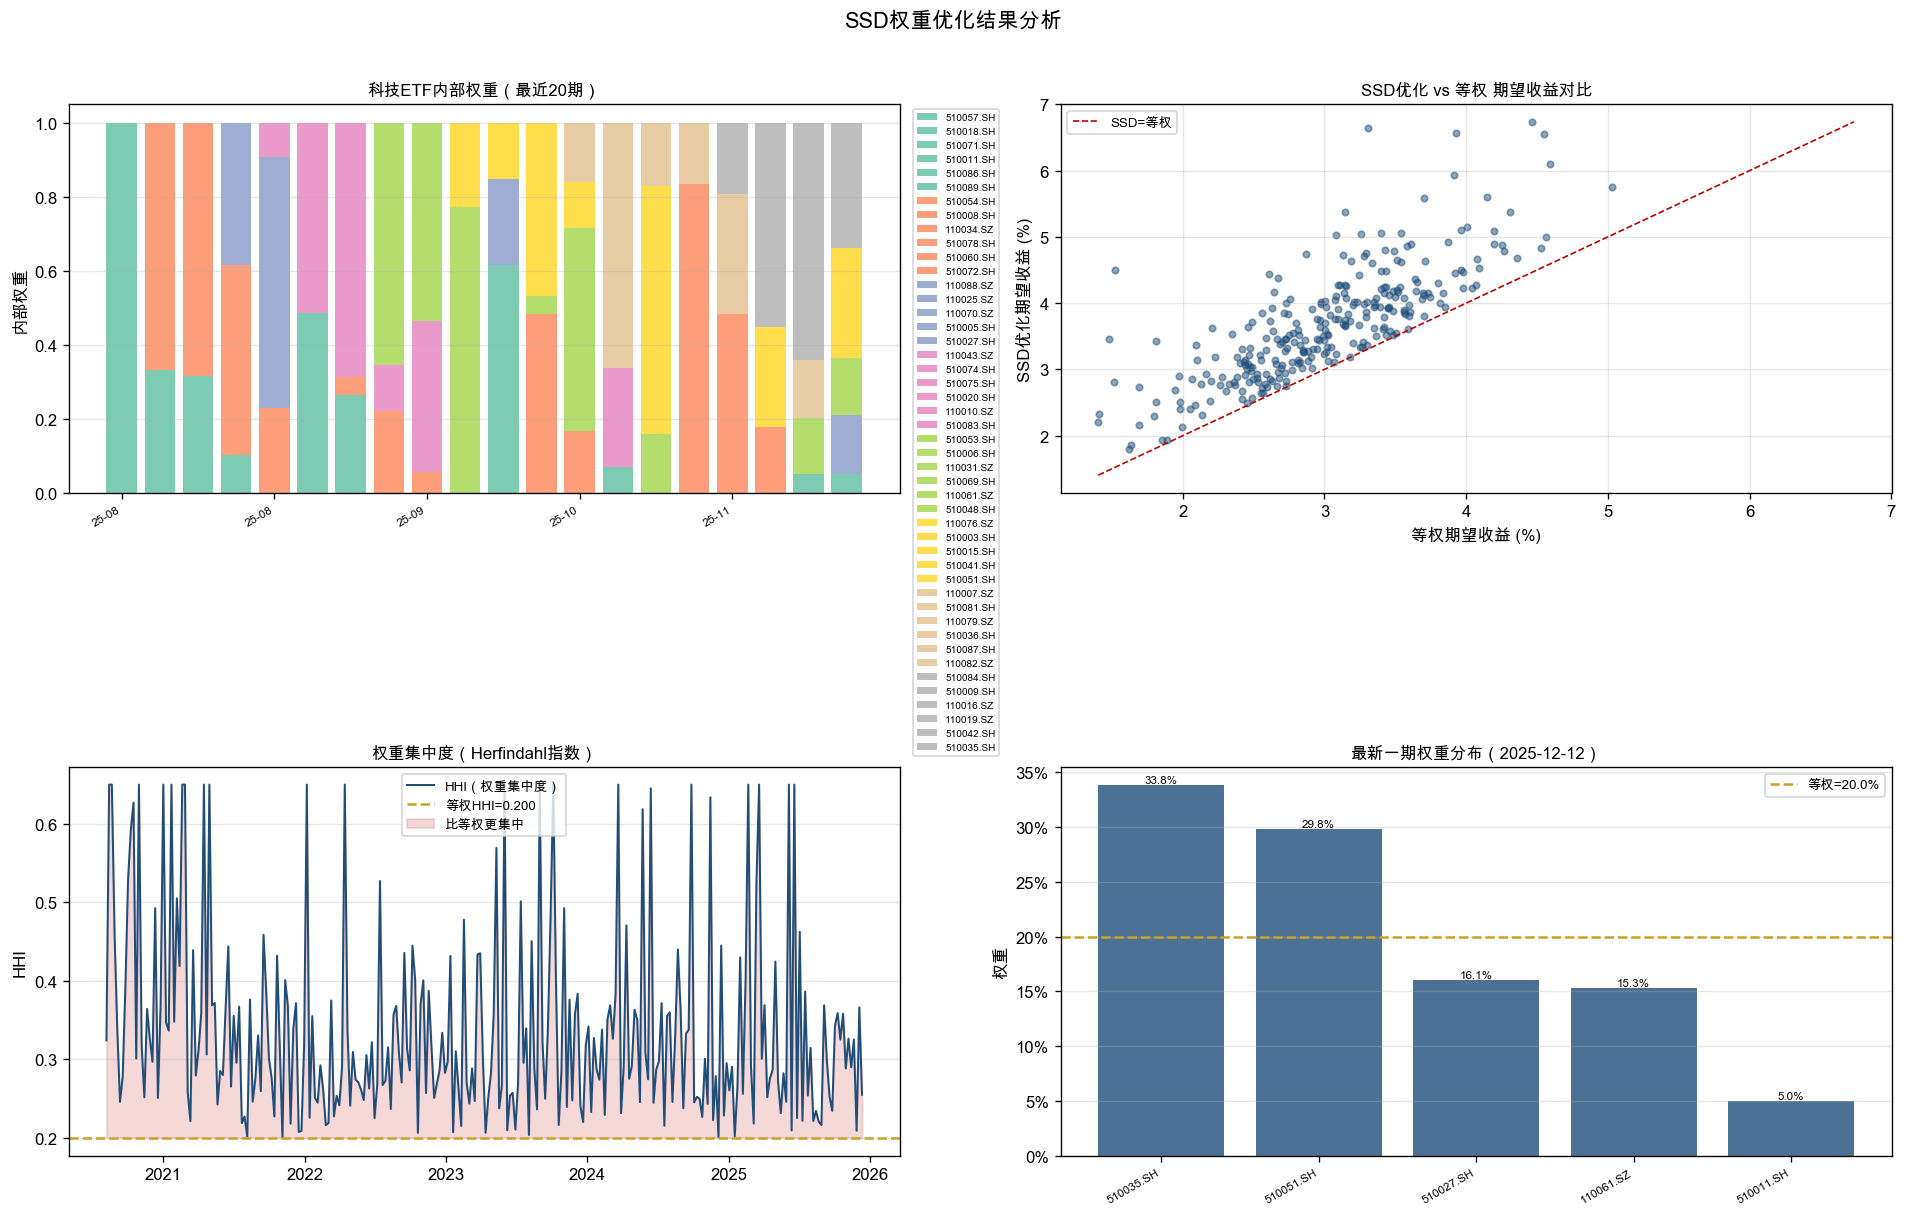

✅ 权重优化可视化完成


In [ ]:
# ============================================================
# SSD优化 Part 5：权重优化结果可视化
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- 左上：权重时序堆叠图（最近20期）---
ax1 = axes[0][0]
recent_dates = list(etf_weights.keys())[-20:]

# 收集所有出现过的ETF
all_etfs_recent = []
for d in recent_dates:
    all_etfs_recent.extend(etf_weights[d].keys())
all_etfs_recent = list(dict.fromkeys(all_etfs_recent))

weight_matrix = np.zeros((len(recent_dates), len(all_etfs_recent)))
for i, d in enumerate(recent_dates):
    for j, etf in enumerate(all_etfs_recent):
        weight_matrix[i, j] = etf_weights[d].get(etf, 0.0)

# 堆叠面积图
bottom = np.zeros(len(recent_dates))
colors_etf = plt.cm.Set2(np.linspace(0, 1, len(all_etfs_recent)))
x_pos = range(len(recent_dates))

for j, etf in enumerate(all_etfs_recent):
    ax1.bar(x_pos, weight_matrix[:, j],
            bottom=bottom,
            label=etf[:10],
            color=colors_etf[j],
            alpha=0.85)
    bottom += weight_matrix[:, j]

ax1.set_xticks(x_pos[::4])
ax1.set_xticklabels(
    [d.strftime('%y-%m') for d in recent_dates[::4]],
    rotation=30, ha='right', fontsize=7
)
ax1.set_ylabel('内部权重')
ax1.set_ylim(0, 1.05)
ax1.set_title('科技ETF内部权重（最近20期）', fontsize=10)
ax1.legend(loc='upper left', fontsize=6,
            bbox_to_anchor=(1.01, 1))
ax1.grid(axis='y', alpha=0.3)

# --- 右上：SSD vs 等权期望收益散点图 ---
ax2 = axes[0][1]
ssd_rets = [d['obj_return'] for d in weight_details.values()
            if d.get('method') == 'SSD优化']
eq_rets  = [d['eq_return']  for d in weight_details.values()
            if d.get('method') == 'SSD优化']

if ssd_rets:
    ax2.scatter(np.array(eq_rets)*100,
                np.array(ssd_rets)*100,
                alpha=0.5, s=15,
                color='#1f4e79')
    mn = min(min(eq_rets), min(ssd_rets)) * 100
    mx = max(max(eq_rets), max(ssd_rets)) * 100
    ax2.plot([mn, mx], [mn, mx],
             color='#c00000', linewidth=1,
             linestyle='--', label='SSD=等权')
    ax2.set_xlabel('等权期望收益 (%)')
    ax2.set_ylabel('SSD优化期望收益 (%)')
    ax2.set_title('SSD优化 vs 等权 期望收益对比', fontsize=10)
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

# --- 左下：权重集中度（HHI）时序 ---
ax3 = axes[1][0]
hhi_series = {}
for d, w_dict in etf_weights.items():
    w_arr = np.array(list(w_dict.values()))
    hhi   = np.sum(w_arr ** 2)
    hhi_series[d] = hhi

hhi_s = pd.Series(hhi_series)
eq_hhi = 1 / TOP_N_INDEX

ax3.plot(hhi_s.index, hhi_s.values,
          color='#1f4e79', linewidth=1.2, label='HHI（权重集中度）')
ax3.axhline(eq_hhi, color='#c9a227', linewidth=1.5,
             linestyle='--', label=f'等权HHI={eq_hhi:.3f}')
ax3.fill_between(hhi_s.index, hhi_s.values, eq_hhi,
                  where=hhi_s.values > eq_hhi,
                  alpha=0.15, color='#c00000',
                  label='比等权更集中')
ax3.set_ylabel('HHI')
ax3.set_title('权重集中度（Herfindahl指数）', fontsize=10)
ax3.legend(fontsize=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.grid(axis='y', alpha=0.3)

# --- 右下：单期权重分布示例（最新一期）---
ax4 = axes[1][1]
last_d = list(etf_weights.keys())[-1]
last_w = etf_weights[last_d]
etf_labels = [c[:10] for c in last_w.keys()]
etf_vals   = list(last_w.values())

bars = ax4.bar(range(len(etf_labels)), etf_vals,
               color='#1f4e79', alpha=0.8)
ax4.axhline(1/len(etf_labels), color='#c9a227',
             linewidth=1.5, linestyle='--',
             label=f'等权={1/len(etf_labels):.1%}')
ax4.set_xticks(range(len(etf_labels)))
ax4.set_xticklabels(etf_labels, rotation=30,
                     ha='right', fontsize=7)
ax4.set_ylabel('权重')
ax4.set_title(f'最新一期权重分布（{last_d.date()}）', fontsize=10)
ax4.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)
ax4.legend(fontsize=8)
ax4.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, etf_vals):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.1%}', ha='center', fontsize=7)

plt.suptitle('SSD权重优化结果分析', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'ssd_weights.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 权重优化可视化完成")

## 第七部分：回测引擎

### 模块目标

将前六个模块的输出整合为完整的策略回测：
- 每期持仓 = 科技ETF权重（SSD优化）× 总仓位 + 黄金ETF × 剩余仓位
- 计算每期组合收益率，扣除交易成本
- 生成净值曲线，与科创50基准对比

### 持仓构建逻辑
最终持仓[date] = 
- 科技ETF_1 : etf_weights[date][etf_1] × position_weights[date]
- 科技ETF_2 : etf_weights[date][etf_2] × position_weights[date]
- ...
- 黄金ETF   : (1 - position_weights[date])

### 交易成本
- 单边费率：0.03%
- 计算方式：每期换手率 × 0.03%
- 换手率 = Σ |当期权重 - 上期权重| / 2

### 绩效指标
| 指标 | 说明 |
|------|------|
| 年化收益率 | 几何平均年化 |
| 年化波动率 | 周度收益率标准差 × √52 |
| Sharpe比率 | 年化收益 / 年化波动（无风险利率=0） |
| Calmar比率 | 年化收益 / 最大回撤 |
| 最大回撤 | 净值曲线历史最大下行幅度 |
| 超额收益 | 相对科创50指数 |

In [43]:
# ============================================================
# 回测引擎 Part 1：基准数据（科创50）
# ============================================================

# 模拟科创50指数（真实情况从Wind拉取000688.SH）
np.random.seed(50)
kcb50_prices_raw = simulate_price_gbm(
    n_days       = len(all_dates),
    mu_annual    = 0.15,
    sigma_annual = 0.35,
    s0           = 1000.0,
    seed         = 50
)
kcb50_price_daily = pd.Series(
    kcb50_prices_raw,
    index = all_dates,
    name  = '000688.SH'
)
kcb50_price_daily = kcb50_price_daily.loc[BACKTEST_START:BACKTEST_END]

# 周频收益率
kcb50_return_weekly = (
    kcb50_price_daily.resample('W-FRI').last().pct_change()
)
kcb50_return_weekly = kcb50_return_weekly.loc[BACKTEST_START:BACKTEST_END]

# 科创50累计净值
kcb50_nav = (1 + kcb50_return_weekly.fillna(0)).cumprod()

print("✅ 科创50基准数据准备完成")
print(f"   起始价格 : {kcb50_price_daily.iloc[0]:.2f}")
print(f"   截止价格 : {kcb50_price_daily.iloc[-1]:.2f}")
print(f"   区间收益 : {kcb50_nav.iloc[-1]-1:.2%}")

✅ 科创50基准数据准备完成
   起始价格 : 523.11
   截止价格 : 1857.79
   区间收益 : 255.06%


In [44]:
# ============================================================
# 回测引擎 Part 2：每期完整持仓权重
# ============================================================

def build_full_portfolio(rebal_date,
                          etf_weights_dict,
                          position_weights_dict,
                          hedge_etf=HEDGE_ETF_CODE):
    """
    构建单期完整持仓权重。

    Parameters
    ----------
    rebal_date : pd.Timestamp
    etf_weights_dict : dict
        {etf_code: internal_weight}，科技ETF内部权重（加总=1）
    position_weights_dict : dict
        {date: tech_weight}，科技ETF总仓位
    hedge_etf : str
        黄金ETF代码

    Returns
    -------
    portfolio : dict
        {asset_code: final_weight}，最终持仓（加总=1）
    """
    tech_weight = position_weights_dict.get(rebal_date, 1.0)
    gold_weight = 1.0 - tech_weight

    portfolio = {}

    # 科技ETF
    for etf_code, internal_w in etf_weights_dict.items():
        final_w = internal_w * tech_weight
        portfolio[etf_code] = final_w

    # 黄金ETF
    if gold_weight > 1e-6:
        portfolio[hedge_etf] = gold_weight

    # 归一化保险
    total = sum(portfolio.values())
    if total > 1e-8:
        portfolio = {k: v/total for k, v in portfolio.items()}

    return portfolio


# 构建全期持仓
full_portfolio = {}

for rebal_date in rebalance_dates:
    if rebal_date not in etf_weights:
        continue

    port = build_full_portfolio(
        rebal_date            = rebal_date,
        etf_weights_dict      = etf_weights[rebal_date],
        position_weights_dict = position_weights,
    )
    full_portfolio[rebal_date] = port

print(f"✅ 全期持仓构建完成：{len(full_portfolio)} 期")
print(f"\n最新一期完整持仓：")
last_port_date = list(full_portfolio.keys())[-1]
last_port      = full_portfolio[last_port_date]
print(f"  调仓日期: {last_port_date.date()}")
print(f"  {'代码':<15} {'权重':>8}")
print(f"  {'-'*25}")
for code, w in sorted(last_port.items(),
                       key=lambda x: -x[1]):
    tag = '（黄金）' if code == HEDGE_ETF_CODE else ''
    print(f"  {code:<15} {w:>7.2%}  {tag}")
print(f"  {'合计':<15} {sum(last_port.values()):>7.2%}")

✅ 全期持仓构建完成：280 期

最新一期完整持仓：
  调仓日期: 2025-12-12
  代码                    权重
  -------------------------
  518880.SH        44.05%  （黄金）
  510035.SH        18.92%  
  510051.SH        16.69%  
  510027.SH         8.98%  
  110061.SZ         8.57%  
  510011.SH         2.80%  
  合计              100.00%


In [45]:
# ============================================================
# 回测引擎 Part 3：换手率 + 交易成本
# ============================================================

def compute_turnover(prev_portfolio, curr_portfolio):
    """
    计算单次调仓的换手率。

    换手率 = Σ |当期权重 - 上期权重| / 2

    Parameters
    ----------
    prev_portfolio : dict or None
    curr_portfolio : dict

    Returns
    -------
    turnover : float
    """
    if prev_portfolio is None:
        # 首期建仓：全部买入
        return sum(curr_portfolio.values())

    all_assets = set(prev_portfolio.keys()) | set(curr_portfolio.keys())
    turnover = 0.0
    for asset in all_assets:
        prev_w = prev_portfolio.get(asset, 0.0)
        curr_w = curr_portfolio.get(asset, 0.0)
        turnover += abs(curr_w - prev_w)

    return turnover / 2.0


# 计算全期换手率序列
turnover_series = {}
port_dates = sorted(full_portfolio.keys())

for i, date in enumerate(port_dates):
    prev = full_portfolio[port_dates[i-1]] if i > 0 else None
    curr = full_portfolio[date]
    turnover_series[date] = compute_turnover(prev, curr)

to_series = pd.Series(turnover_series)

print(f"✅ 换手率计算完成")
print(f"   平均换手率 : {to_series.mean():.2%}")
print(f"   最大换手率 : {to_series.max():.2%}")
print(f"   最小换手率 : {to_series.min():.2%}")
print(f"   年化换手率 : {to_series.mean()*52:.2%}")

✅ 换手率计算完成
   平均换手率 : 61.66%
   最大换手率 : 100.00%
   最小换手率 : 20.74%
   年化换手率 : 3206.34%


In [46]:
# ============================================================
# 回测引擎 Part 4：组合收益率计算
# ============================================================

def get_asset_return(asset_code, date,
                      etf_ret_weekly,
                      gold_ret_weekly,
                      hedge_etf=HEDGE_ETF_CODE):
    """
    获取单个资产在指定周的实际收益率。
    """
    if asset_code == hedge_etf:
        if date in gold_ret_weekly.index:
            r = gold_ret_weekly.loc[date]
            return r if not np.isnan(r) else 0.0
        return 0.0

    if asset_code in etf_ret_weekly.columns:
        # ETF周频收益率
        etf_price_w = etf_price_daily[asset_code].resample('W-FRI').last()
        etf_ret_w   = etf_price_w.pct_change()
        if date in etf_ret_w.index:
            r = etf_ret_w.loc[date]
            return r if not np.isnan(r) else 0.0

    return 0.0


# 预计算所有ETF的周频收益率（避免循环内重复计算）
all_etf_codes_used = list(set(
    code
    for port in full_portfolio.values()
    for code in port.keys()
    if code != HEDGE_ETF_CODE
))

etf_ret_weekly_all = {}
for etf_code in all_etf_codes_used:
    if etf_code in etf_price_daily.columns:
        price_w = etf_price_daily[etf_code].resample('W-FRI').last()
        ret_w   = price_w.pct_change()
        etf_ret_weekly_all[etf_code] = ret_w

print(f"预计算ETF周频收益率：{len(etf_ret_weekly_all)} 支")

# --- 主循环：逐期计算组合收益率 ---
strategy_returns = {}   # {date: net_return（扣费后）}
gross_returns    = {}   # {date: gross_return（扣费前）}

port_dates = sorted(full_portfolio.keys())

for i, rebal_date in enumerate(port_dates):
    curr_port = full_portfolio[rebal_date]

    # 持仓收益期间：从本期调仓日到下期调仓日
    if i + 1 < len(port_dates):
        next_date = port_dates[i + 1]
    else:
        next_date = pd.Timestamp(BACKTEST_END)

    # 用下一个调仓日对应的周频收益率（即持有本期持仓获得的收益）
    gross_ret = 0.0
    for asset_code, weight in curr_port.items():
        if asset_code == HEDGE_ETF_CODE:
            if next_date in gold_return_weekly.index:
                r = gold_return_weekly.loc[next_date]
                gross_ret += weight * (r if not np.isnan(r) else 0.0)
        else:
            if asset_code in etf_ret_weekly_all:
                ret_w = etf_ret_weekly_all[asset_code]
                if next_date in ret_w.index:
                    r = ret_w.loc[next_date]
                    gross_ret += weight * (r if not np.isnan(r) else 0.0)

    # 扣除交易成本
    tc = turnover_series.get(rebal_date, 0.0) * TRANSACTION_COST
    net_ret = gross_ret - tc

    gross_returns[rebal_date]    = gross_ret
    strategy_returns[rebal_date] = net_ret

ret_series   = pd.Series(strategy_returns)
gross_series = pd.Series(gross_returns)

print(f"\n✅ 组合收益率计算完成")
print(f"   总期数       : {len(ret_series)}")
print(f"   周均收益（净）: {ret_series.mean():.4%}")
print(f"   周均收益（毛）: {gross_series.mean():.4%}")
print(f"   交易成本拖累  : {(gross_series.mean()-ret_series.mean())*52:.4%}（年化）")

预计算ETF周频收益率：78 支

✅ 组合收益率计算完成
   总期数       : 280
   周均收益（净）: 0.0224%
   周均收益（毛）: 0.0409%
   交易成本拖累  : 0.9619%（年化）


In [52]:
# ============================================================
# 回测引擎 Part 5：绩效指标计算
# ============================================================

def compute_performance(return_series, freq=52,
                         risk_free=0.0, name='策略'):
    """
    计算完整绩效指标。

    Parameters
    ----------
    return_series : pd.Series
        周度收益率序列
    freq : int
        年化频率（周频=52）
    risk_free : float
        年化无风险利率
    name : str
        策略名称

    Returns
    -------
    metrics : dict
    nav : pd.Series
        净值曲线
    drawdown : pd.Series
        回撤序列
    """
    r = return_series.fillna(0)

    # 净值曲线
    nav = (1 + r).cumprod()

    # 年化收益率（几何）
    n_years  = len(r) / freq
    ann_ret  = nav.iloc[-1] ** (1 / n_years) - 1

    # 年化波动率
    ann_vol  = r.std() * np.sqrt(freq)

    # Sharpe
    sharpe   = (ann_ret - risk_free) / ann_vol if ann_vol > 0 else 0

    # 最大回撤
    roll_max  = nav.cummax()
    drawdown  = (nav - roll_max) / roll_max
    max_dd    = drawdown.min()

    # Calmar
    calmar   = ann_ret / abs(max_dd) if max_dd < 0 else np.inf

    # 胜率（周度）
    win_rate = (r > 0).mean()

    metrics = {
        'name'       : name,
        '年化收益率' : ann_ret,
        '年化波动率' : ann_vol,
        'Sharpe'     : sharpe,
        'Calmar'     : calmar,
        '最大回撤'   : max_dd,
        '胜率'       : win_rate,
        '累计收益'   : nav.iloc[-1] - 1,
    }

    return metrics, nav, drawdown


def compute_annual_performance(return_series, freq=52):
    """按年计算绩效指标"""
    years = return_series.index.year.unique()
    rows  = []
    for yr in sorted(years):
        r_yr = return_series[return_series.index.year == yr]
        if len(r_yr) < 4:
            continue
        m, _, _ = compute_performance(r_yr, freq=freq, name=str(yr))
        rows.append({
            '年份'     : yr,
            '年化收益' : m['年化收益率'],
            '年化波动' : m['年化波动率'],
            'Sharpe'   : m['Sharpe'],
            'Calmar'   : m['Calmar'],
            '最大回撤' : m['最大回撤'],
            '胜率'     : m['胜率'],
        })
    return pd.DataFrame(rows).set_index('年份')


# 计算策略绩效
strat_metrics, strat_nav, strat_dd = compute_performance(
    ret_series, name='QRF-SSD策略'
)

# 计算基准绩效
bench_ret = kcb50_return_weekly.reindex(ret_series.index).fillna(0)
bench_metrics, bench_nav, bench_dd = compute_performance(
    bench_ret, name='科创50'
)

# 超额收益
excess_ret    = ret_series - bench_ret
excess_cumret = (1 + excess_ret).cumprod() - 1

print("=" * 55)
print(f"{'指标':<15} {'QRF-SSD策略':>15} {'科创50基准':>12}")
print("=" * 55)
for key in ['年化收益率', '年化波动率', 'Sharpe',
            'Calmar', '最大回撤', '胜率', '累计收益']:
    sv = strat_metrics[key]
    bv = bench_metrics[key]
    if key in ['年化收益率', '年化波动率', '最大回撤', '胜率', '累计收益']:
        print(f"{key:<15} {sv:>14.2%}  {bv:>11.2%}")
    else:
        print(f"{key:<15} {sv:>14.4f}  {bv:>11.4f}")
print("=" * 55)
print(f"{'累计超额收益':<15} {excess_cumret.iloc[-1]:>14.2%}")

# 分年度绩效
print(f"\n分年度绩效（对应报告表11）：")
annual_perf = compute_annual_performance(ret_series)
print(annual_perf.apply(
    lambda col: col.map(lambda x: f'{x:.2%}' if isinstance(x, float) else x)
).to_string())

指标                    QRF-SSD策略       科创50基准
年化收益率                   -0.52%       30.90%
年化波动率                   18.36%       36.90%
Sharpe                 -0.0284       0.8375
Calmar                 -0.0154       0.8573
最大回撤                   -33.97%      -36.05%
胜率                      50.71%       55.36%
累计收益                    -2.78%      326.31%
累计超额收益                 -88.83%

分年度绩效（对应报告表11）：
         年化收益    年化波动    Sharpe   Calmar     最大回撤      胜率
年份                                                       
2020    7.08%  11.94%    59.30%  169.76%   -4.17%  57.14%
2021  -20.82%  20.41%  -102.02%  -85.14%  -24.46%  37.74%
2022   29.50%  20.26%   145.59%  305.58%   -9.65%  65.38%
2023  -18.68%  17.02%  -109.73%  -62.66%  -29.81%  40.38%
2024    7.18%  17.22%    41.72%   65.19%  -11.02%  55.77%
2025    6.56%  18.57%    35.33%   58.64%  -11.19%  52.00%


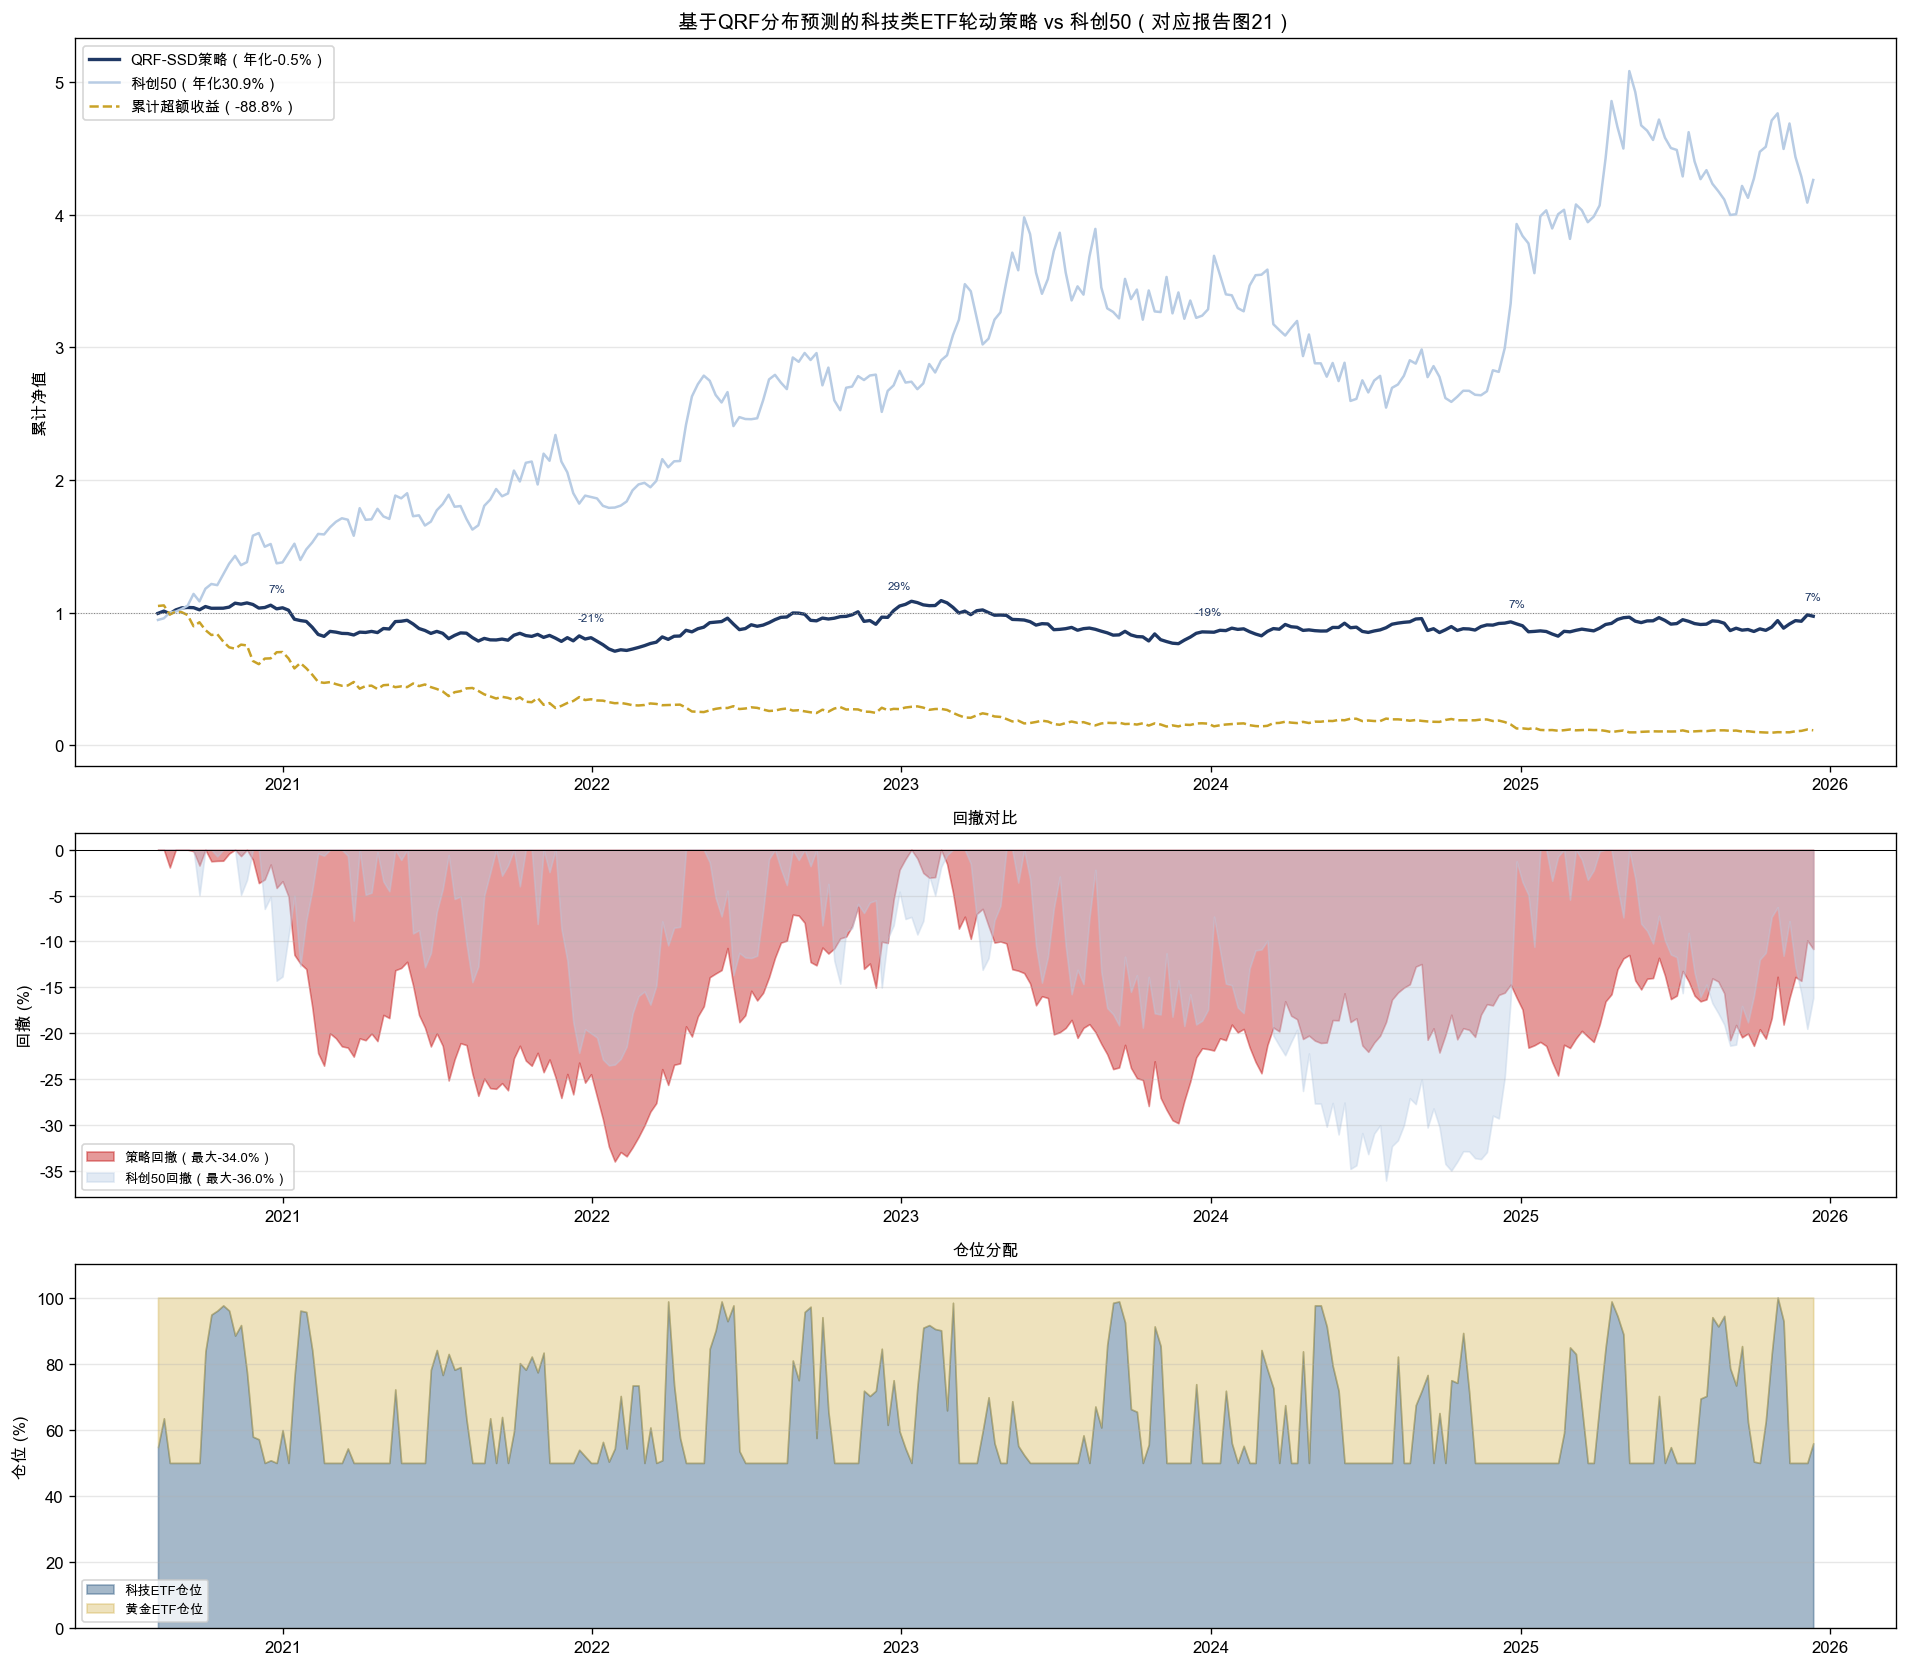

✅ 净值曲线已生成


In [ ]:
# ============================================================
# 回测引擎 Part 6：净值曲线（对应报告图21）
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 14),
                          gridspec_kw={'height_ratios': [3, 1.5, 1.5]})

# --- 上图：净值曲线 ---
ax1 = axes[0]

ax1.plot(strat_nav.index, strat_nav.values,
          color='#1f3864', linewidth=2.0,
          label=f'QRF-SSD策略（年化{strat_metrics["年化收益率"]:.1%}）')
ax1.plot(bench_nav.index, bench_nav.values,
          color='#b8cce4', linewidth=1.5,
          label=f'科创50（年化{bench_metrics["年化收益率"]:.1%}）')
ax1.plot(strat_nav.index,
          (1 + excess_cumret).values,
          color='#c9a227', linewidth=1.5,
          linestyle='--',
          label=f'累计超额收益（{excess_cumret.iloc[-1]:.1%}）')

ax1.axhline(1.0, color='grey', linewidth=0.6, linestyle=':')
ax1.set_ylabel('累计净值')
ax1.set_title('基于QRF分布预测的科技类ETF轮动策略 vs 科创50（对应报告图21）',
               fontsize=12)
ax1.legend(loc='upper left', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(axis='y', alpha=0.3)

# 标注年度收益
for yr in annual_perf.index:
    yr_mask = ret_series.index.year == yr
    if yr_mask.sum() == 0:
        continue
    yr_end = ret_series.index[yr_mask][-1]
    if yr_end in strat_nav.index:
        nav_val = strat_nav.loc[yr_end]
        ann_r   = annual_perf.loc[yr, '年化收益']
        ax1.annotate(
            f'{ann_r:.0%}',
            xy=(yr_end, nav_val),
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=7,
            color='#1f3864',
            ha='center',
        )

# --- 中图：策略回撤 ---
ax2 = axes[1]
ax2.fill_between(strat_dd.index, strat_dd.values * 100, 0,
                  color='#c00000', alpha=0.4,
                  label=f'策略回撤（最大{strat_metrics["最大回撤"]:.1%}）')
ax2.fill_between(bench_dd.index, bench_dd.values * 100, 0,
                  color='#b8cce4', alpha=0.4,
                  label=f'科创50回撤（最大{bench_metrics["最大回撤"]:.1%}）')
ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_ylabel('回撤 (%)')
ax2.set_title('回撤对比', fontsize=10)
ax2.legend(loc='lower left', fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(axis='y', alpha=0.3)

# --- 下图：仓位 ---
ax3 = axes[2]
pos_plot = pos_series.reindex(strat_nav.index, method='ffill')
ax3.fill_between(pos_plot.index,
                  pos_plot.values * 100, 0,
                  color='#1f4e79', alpha=0.4,
                  label='科技ETF仓位')
ax3.fill_between(pos_plot.index,
                  100,
                  pos_plot.values * 100,
                  color='#c9a227', alpha=0.3,
                  label='黄金ETF仓位')
ax3.set_ylabel('仓位 (%)')
ax3.set_ylim(0, 110)
ax3.set_title('仓位分配', fontsize=10)
ax3.legend(loc='lower left', fontsize=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'backtest_nav.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 净值曲线已生成")

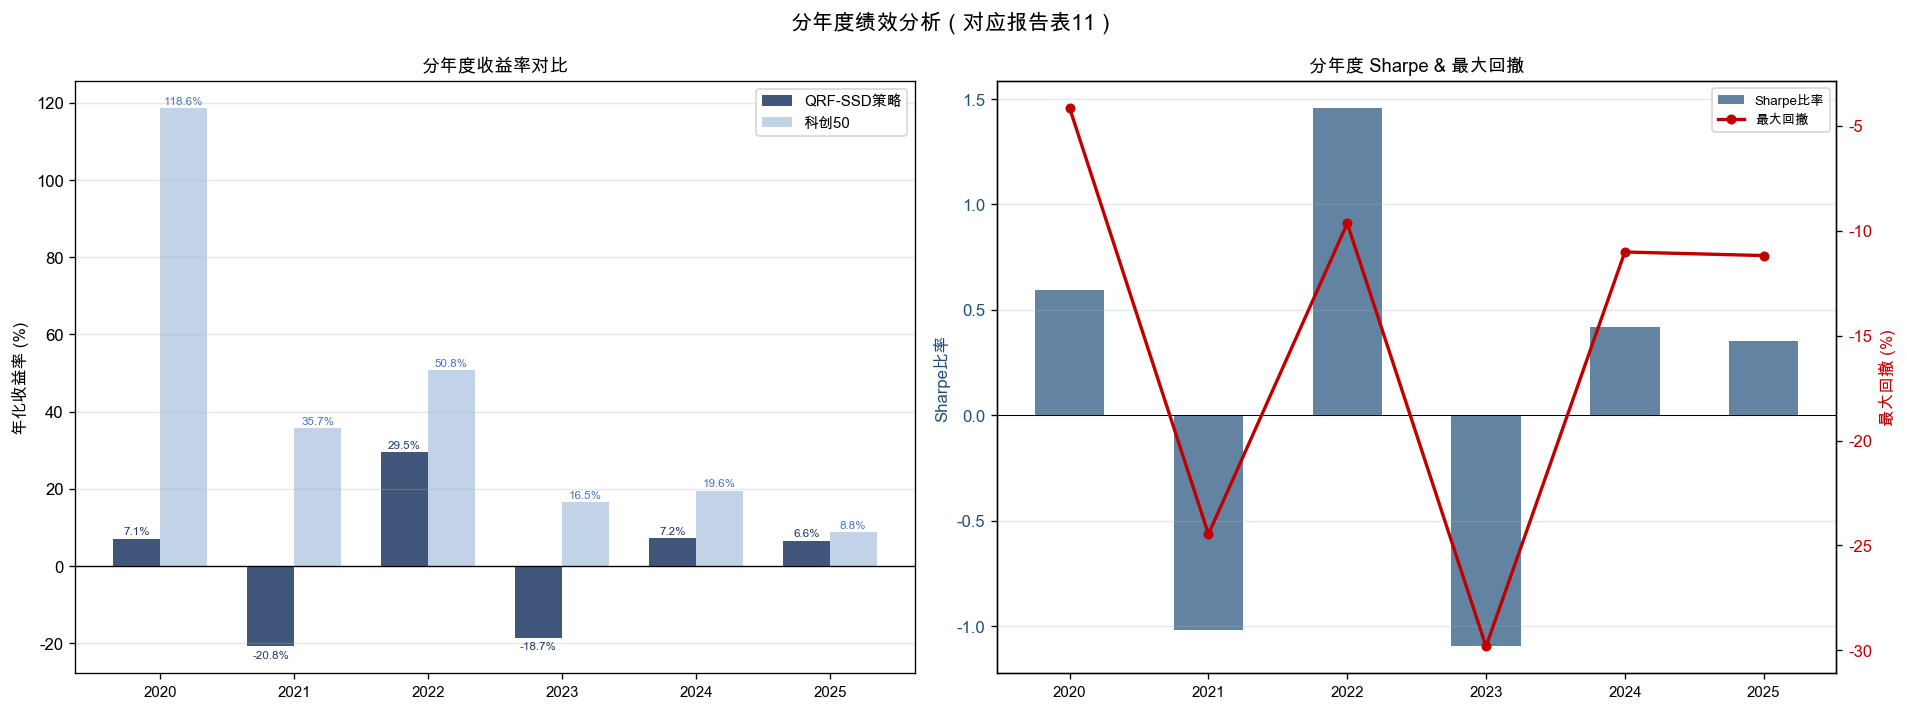


对标报告表11格式：
时间                 年化收益       年化波动   Sharpe   Calmar       最大回撤
------------------------------------------------------------
2020至今           -0.52%     18.36%  -0.0284  -0.0154    -33.97%
2020              7.08%     11.94%   0.5930   1.6976     -4.17%
2021            -20.82%     20.41%  -1.0202  -0.8514    -24.46%
2022             29.50%     20.26%   1.4559   3.0558     -9.65%
2023            -18.68%     17.02%  -1.0973  -0.6266    -29.81%
2024              7.18%     17.22%   0.4172   0.6519    -11.02%
2025              6.56%     18.57%   0.3533   0.5864    -11.19%


In [ ]:
# ============================================================
# 回测引擎 Part 7：分年度绩效对比（对应报告表11）
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 左图：分年度收益率对比柱状图 ---
ax1 = axes[0]

bench_annual = compute_annual_performance(bench_ret)
years = sorted(set(annual_perf.index) & set(bench_annual.index))

x      = np.arange(len(years))
width  = 0.35

bars1 = ax1.bar(x - width/2,
                 [annual_perf.loc[y, '年化收益'] * 100 for y in years],
                 width, color='#1f3864', alpha=0.85,
                 label='QRF-SSD策略')
bars2 = ax1.bar(x + width/2,
                 [bench_annual.loc[y, '年化收益'] * 100 for y in years],
                 width, color='#b8cce4', alpha=0.85,
                 label='科创50')

ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(years, fontsize=9)
ax1.set_ylabel('年化收益率 (%)')
ax1.set_title('分年度收益率对比', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# 数值标签
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2,
             h + (1 if h >= 0 else -3),
             f'{h:.1f}%', ha='center', fontsize=7,
             color='#1f3864')
for bar in bars2:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2,
             h + (1 if h >= 0 else -3),
             f'{h:.1f}%', ha='center', fontsize=7,
             color='#4472c4')

# --- 右图：分年度Sharpe和最大回撤 ---
ax2 = axes[1]
ax2_twin = ax2.twinx()

sharpes = [annual_perf.loc[y, 'Sharpe'] for y in years]
maxdds  = [annual_perf.loc[y, '最大回撤'] * 100 for y in years]

ax2.bar(x, sharpes, width=0.5,
         color='#1f4e79', alpha=0.7,
         label='Sharpe比率')
ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_ylabel('Sharpe比率', color='#1f4e79')
ax2.tick_params(axis='y', labelcolor='#1f4e79')
ax2.set_xticks(x)
ax2.set_xticklabels(years, fontsize=9)

ax2_twin.plot(x, maxdds,
               color='#c00000', linewidth=2,
               marker='o', markersize=5,
               label='最大回撤')
ax2_twin.set_ylabel('最大回撤 (%)', color='#c00000')
ax2_twin.tick_params(axis='y', labelcolor='#c00000')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2,
            loc='upper right', fontsize=8)
ax2.set_title('分年度 Sharpe & 最大回撤', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('分年度绩效分析（对应报告表11）', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'annual_performance.png'), dpi=150, bbox_inches='tight')
plt.show()

# 打印对标报告的表格
print("\n对标报告表11格式：")
print(f"{'时间':<12} {'年化收益':>10} {'年化波动':>10} "
      f"{'Sharpe':>8} {'Calmar':>8} {'最大回撤':>10}")
print("-" * 60)

# 全期
print(f"{'2020至今':<12} "
      f"{strat_metrics['年化收益率']:>10.2%} "
      f"{strat_metrics['年化波动率']:>10.2%} "
      f"{strat_metrics['Sharpe']:>8.4f} "
      f"{strat_metrics['Calmar']:>8.4f} "
      f"{strat_metrics['最大回撤']:>10.2%}")

for yr in sorted(annual_perf.index):
    row = annual_perf.loc[yr]
    print(f"{yr:<12} "
          f"{row['年化收益']:>10.2%} "
          f"{row['年化波动']:>10.2%} "
          f"{row['Sharpe']:>8.4f} "
          f"{row['Calmar']:>8.4f} "
          f"{row['最大回撤']:>10.2%}")

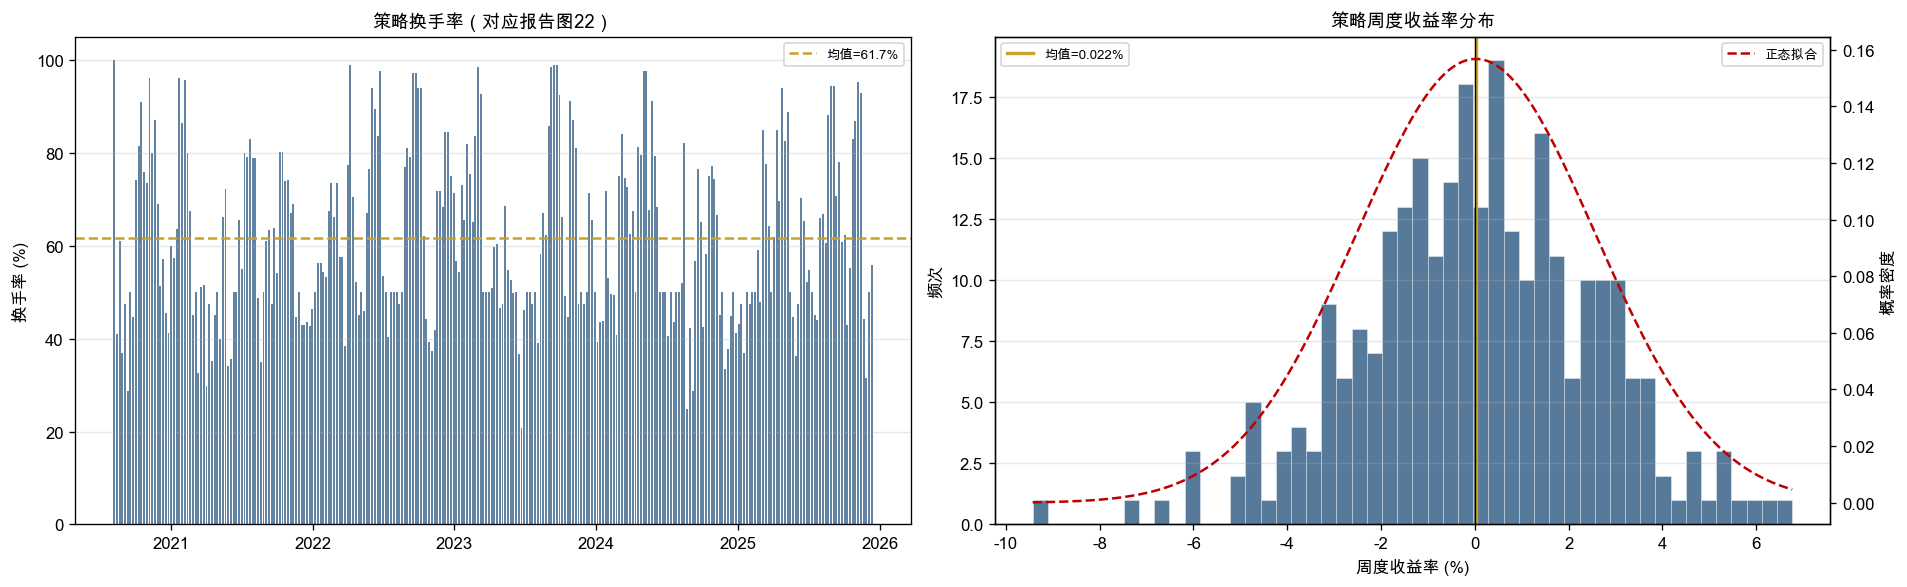


最新5期持仓明细（对应报告表12）：
调仓日期         代码              名称                         权重
----------------------------------------------------------
2025-11-14   518880.SH       华安黄金ETF               50.00%
2025-11-14   510008.SH       芯片设计                  21.81%
2025-11-14   110034.SZ       云计算主题                 12.34%
2025-11-14   510054.SH       储能主题                   7.52%
2025-11-14   510087.SH       建筑材料                   5.83%
2025-11-14   110082.SZ       军工龙头                   2.50%

2025-11-21   518880.SH       华安黄金ETF               50.00%
2025-11-21   510060.SH       工程机械主题                24.10%
2025-11-21   510087.SH       建筑材料                  11.33%
2025-11-21   510084.SH       航空航天                   9.57%
2025-11-21   110079.SZ       汽车零部件                  2.50%
2025-11-21   510036.SH       人工智能                   2.50%

2025-11-28   518880.SH       华安黄金ETF               50.00%
2025-11-28   110076.SZ       新能源汽车                 13.58%
2025-11-28   510084.SH       航空航天               

In [ ]:
# ============================================================
# 回测引擎 Part 8：换手率图 + 最新持仓明细
# 对应报告图22和表12
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- 左图：换手率时序（对应报告图22）---
ax1 = axes[0]
ax1.bar(to_series.index, to_series.values * 100,
         color='#1f4e79', alpha=0.7, width=5)
ax1.axhline(to_series.mean() * 100,
             color='#c9a227', linewidth=1.5,
             linestyle='--',
             label=f'均值={to_series.mean():.1%}')
ax1.set_ylabel('换手率 (%)')
ax1.set_title('策略换手率（对应报告图22）', fontsize=11)
ax1.legend(fontsize=8)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(axis='y', alpha=0.3)

# --- 右图：收益率分布 ---
ax2 = axes[1]
ax2.hist(ret_series.values * 100, bins=50,
          color='#1f4e79', alpha=0.75,
          edgecolor='white', linewidth=0.3)
ax2.axvline(ret_series.mean() * 100,
             color='#c9a227', linewidth=2,
             linestyle='-',
             label=f'均值={ret_series.mean():.3%}')
ax2.axvline(0, color='black', linewidth=0.8)

# 叠加正态分布曲线
from scipy.stats import norm
x_range = np.linspace(ret_series.min()*100,
                        ret_series.max()*100, 200)
pdf_vals = norm.pdf(x_range,
                     ret_series.mean()*100,
                     ret_series.std()*100)
ax2_twin = ax2.twinx()
ax2_twin.plot(x_range, pdf_vals,
               color='#c00000', linewidth=1.5,
               linestyle='--', label='正态拟合')
ax2_twin.set_ylabel('概率密度')
ax2.set_xlabel('周度收益率 (%)')
ax2.set_ylabel('频次')
ax2.set_title('策略周度收益率分布', fontsize=11)
ax2.legend(loc='upper left', fontsize=8)
ax2_twin.legend(loc='upper right', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'turnover_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- 最新持仓明细（对应报告表12）---
print("\n最新5期持仓明细（对应报告表12）：")
print(f"{'调仓日期':<12} {'代码':<15} {'名称':<20} {'权重':>8}")
print("-" * 58)

recent_ports = list(full_portfolio.keys())[-5:]
for d in recent_ports:
    port = full_portfolio[d]
    for code, w in sorted(port.items(), key=lambda x: -x[1]):
        if code == HEDGE_ETF_CODE:
            name = '华安黄金ETF'
        else:
            idx_rows = etf_mapping[etf_mapping['etf_code'] == code]
            name = (idx_rows.iloc[0]['index_name']
                    if len(idx_rows) > 0 else code)
        print(f"{str(d.date()):<12} {code:<15} {name:<20} {w:>7.2%}")
    print()

print("✅ 回测引擎全部完成")

## 第八部分：策略总结与输出

### 完整流程回顾
数据层          →  指数收盘价 + ETF数据 + FF五因子

↓

QRF预测层       →  滚动104周训练，预测各指数收益率分布（19个分位数）

↓

指数选择层      →  7指标复合评分 → Top5（行业分散约束）→ 最优追踪ETF

↓

仓位控制层      →  MACD死叉 + 波动率分位 → 科技总仓位

↓

权重优化层      →  GARCH残差 + Copula联合分布 + SSD优化 → ETF权重

↓

回测引擎        →  净值曲线 + 绩效统计 + 对标报告

### Wind数据接入后的替换清单

| Cell | 当前（模拟） | 替换为（真实） |
|------|------------|--------------|
| Cell 9-12 | GBM模拟指数价格 | `w.wsd(index_codes, "close", ...)` |
| Cell 11 | 模拟FF五因子 | Cell 16的真实因子计算代码 |
| Cell 12 | 模拟ETF价格+成交额 | `w.wsd(etf_codes, "close,amt", ...)` |
| Cell 49 | 模拟科创50 | `w.wsd("000688.SH", "close", ...)` |
| Cell 41 | 模拟黄金ETF | `w.wsd("518880.SH", "close", ...)` |

### 已知局限与改进方向

| 局限 | 说明 | 改进方向 |
|------|------|---------|
| 指数池静态 | 模拟数据固定30支 | Wind动态筛选，真实为111支 |
| 行业分类简化 | 仅用中信一级 | 补充中信二级行业约束 |
| GARCH后备 | 失败时退化等权 | 改用DCC-GARCH多元模型 |
| 调仓频率 | 严格周频 | 可扩展为月频对比 |
| 交易成本 | 仅考虑换手率×费率 | 补充冲击成本、流动性约束 |

In [ ]:
# ============================================================
# 策略总结 Part 1：所有结果导出为Excel
# ============================================================

os.makedirs('output', exist_ok=True)

with pd.ExcelWriter('output/strategy_results.xlsx',
                     engine='openpyxl') as writer:

    # 1. 净值曲线
    nav_df = pd.DataFrame({
        'QRF_SSD策略净值'  : strat_nav,
        '科创50净值'        : bench_nav.reindex(strat_nav.index),
        '累计超额收益'      : excess_cumret.reindex(strat_nav.index),
        '策略周度收益率'    : ret_series,
        '科创50周度收益率'  : bench_ret,
    })
    nav_df.to_excel(writer, sheet_name='净值曲线')

    # 2. 分年度绩效
    annual_perf.to_excel(writer, sheet_name='分年度绩效')

    # 3. 全期持仓明细
    holding_records = []
    for d, port in full_portfolio.items():
        tech_w = position_weights.get(d, 1.0)
        for code, w in port.items():
            if code == HEDGE_ETF_CODE:
                name   = '华安黄金ETF'
                sector = '对冲'
            else:
                idx_rows = etf_mapping[etf_mapping['etf_code'] == code]
                name   = (idx_rows.iloc[0]['index_name']
                          if len(idx_rows) > 0 else code)
                sector = (idx_rows.iloc[0]['citic_l1']
                          if len(idx_rows) > 0 else '')
            holding_records.append({
                '调仓日期'   : d,
                'ETF代码'    : code,
                'ETF名称'    : name,
                '中信一级'   : sector,
                '持仓权重'   : w,
                '科技总仓位' : tech_w,
            })

    holdings_df = pd.DataFrame(holding_records)
    holdings_df.to_excel(writer, sheet_name='持仓明细', index=False)

    # 4. 仓位序列
    pos_df = pd.DataFrame({
        '科技ETF仓位' : pos_series,
        '黄金ETF仓位' : 1 - pos_series,
        '触发原因'    : pd.Series({
            d: v.get('trigger', '')
            for d, v in position_details.items()
        }),
    })
    pos_df.to_excel(writer, sheet_name='仓位控制')

    # 5. IC统计
    ic_summary = pd.DataFrame([{
        '指标'    : col,
        '均值IC'  : ic_df[col].mean(),
        '标准差'  : ic_df[col].std(),
        'IR'      : (ic_df[col].mean() / ic_df[col].std()
                     if ic_df[col].std() > 0 else 0),
        '正向占比': (ic_df[col] > 0).mean(),
    } for col in indicator_cols if col in ic_df.columns])
    ic_summary.to_excel(writer, sheet_name='IC统计', index=False)

    # 6. 换手率
    to_series.to_frame('换手率').to_excel(writer, sheet_name='换手率')

print("✅ 结果已导出至 output/strategy_results.xlsx")
print(f"   包含工作表：净值曲线 / 分年度绩效 / 持仓明细 / 仓位控制 / IC统计 / 换手率")

✅ 结果已导出至 output/strategy_results.xlsx
   包含工作表：净值曲线 / 分年度绩效 / 持仓明细 / 仓位控制 / IC统计 / 换手率


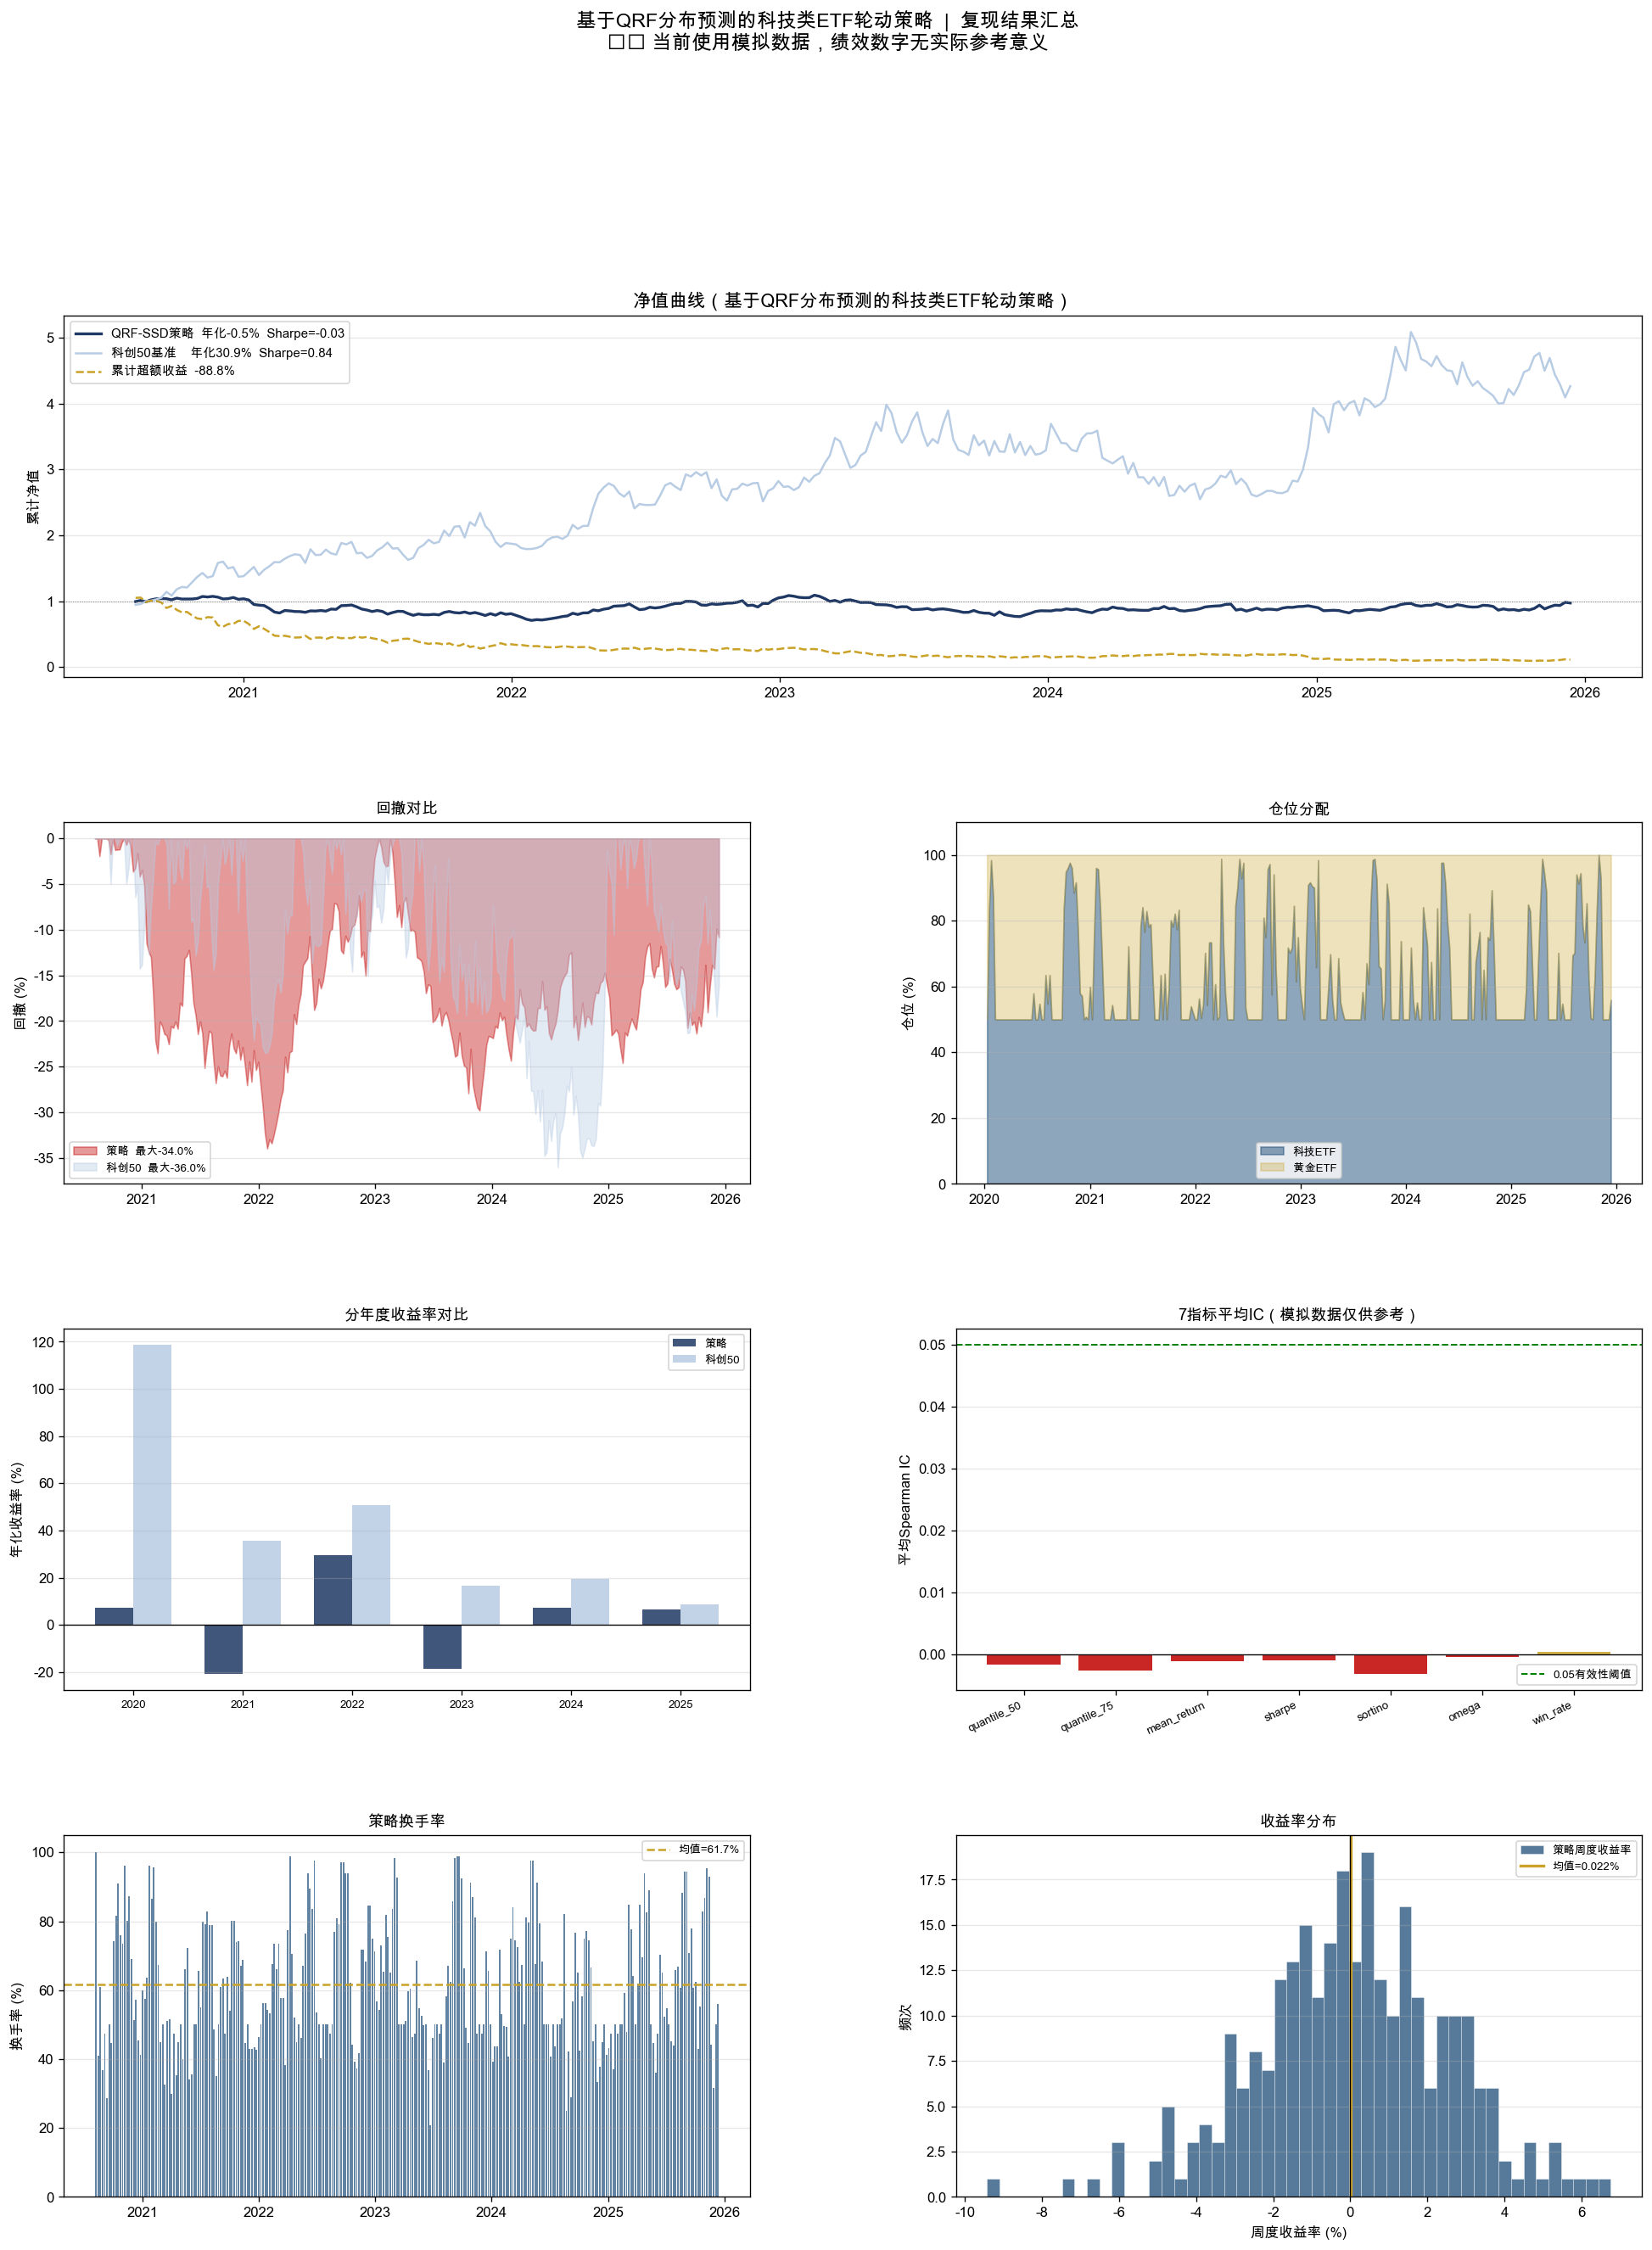

✅ 汇总图已保存至 output/strategy_summary.png


In [ ]:
# ============================================================
# 策略总结 Part 2：汇总图（一张图包含所有核心结果）
# ============================================================

fig = plt.figure(figsize=(20, 24))
gs  = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.3)

# ① 净值曲线（跨两列）
ax_nav = fig.add_subplot(gs[0, :])
ax_nav.plot(strat_nav.index, strat_nav.values,
             color='#1f3864', linewidth=2.0,
             label=f'QRF-SSD策略  年化{strat_metrics["年化收益率"]:.1%}  '
                   f'Sharpe={strat_metrics["Sharpe"]:.2f}')
ax_nav.plot(bench_nav.index, bench_nav.values,
             color='#b8cce4', linewidth=1.5,
             label=f'科创50基准    年化{bench_metrics["年化收益率"]:.1%}  '
                   f'Sharpe={bench_metrics["Sharpe"]:.2f}')
ax_nav.plot(strat_nav.index,
             (1 + excess_cumret).reindex(strat_nav.index),
             color='#c9a227', linewidth=1.5, linestyle='--',
             label=f'累计超额收益  {excess_cumret.iloc[-1]:.1%}')
ax_nav.axhline(1.0, color='grey', linewidth=0.6, linestyle=':')
ax_nav.set_title('净值曲线（基于QRF分布预测的科技类ETF轮动策略）',
                  fontsize=13)
ax_nav.set_ylabel('累计净值')
ax_nav.legend(loc='upper left', fontsize=9)
ax_nav.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_nav.grid(axis='y', alpha=0.3)

# ② 回撤
ax_dd = fig.add_subplot(gs[1, 0])
ax_dd.fill_between(strat_dd.index, strat_dd.values * 100, 0,
                    color='#c00000', alpha=0.4,
                    label=f'策略  最大{strat_metrics["最大回撤"]:.1%}')
ax_dd.fill_between(bench_dd.index, bench_dd.values * 100, 0,
                    color='#b8cce4', alpha=0.4,
                    label=f'科创50  最大{bench_metrics["最大回撤"]:.1%}')
ax_dd.set_title('回撤对比', fontsize=11)
ax_dd.set_ylabel('回撤 (%)')
ax_dd.legend(fontsize=8)
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_dd.grid(axis='y', alpha=0.3)

# ③ 仓位
ax_pos = fig.add_subplot(gs[1, 1])
ax_pos.fill_between(pos_series.index,
                     pos_series.values * 100, 0,
                     color='#1f4e79', alpha=0.5, label='科技ETF')
ax_pos.fill_between(pos_series.index,
                     100, pos_series.values * 100,
                     color='#c9a227', alpha=0.3, label='黄金ETF')
ax_pos.set_title('仓位分配', fontsize=11)
ax_pos.set_ylabel('仓位 (%)')
ax_pos.set_ylim(0, 110)
ax_pos.legend(fontsize=8)
ax_pos.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_pos.grid(axis='y', alpha=0.3)

# ④ 分年度收益率
ax_yr = fig.add_subplot(gs[2, 0])
bench_annual = compute_annual_performance(bench_ret)
years  = sorted(set(annual_perf.index) & set(bench_annual.index))
x      = np.arange(len(years))
width  = 0.35
ax_yr.bar(x - width/2,
           [annual_perf.loc[y, '年化收益'] * 100 for y in years],
           width, color='#1f3864', alpha=0.85, label='策略')
ax_yr.bar(x + width/2,
           [bench_annual.loc[y, '年化收益'] * 100 for y in years],
           width, color='#b8cce4', alpha=0.85, label='科创50')
ax_yr.axhline(0, color='black', linewidth=0.8)
ax_yr.set_xticks(x)
ax_yr.set_xticklabels(years, fontsize=8)
ax_yr.set_ylabel('年化收益率 (%)')
ax_yr.set_title('分年度收益率对比', fontsize=11)
ax_yr.legend(fontsize=8)
ax_yr.grid(axis='y', alpha=0.3)

# ⑤ IC均值柱状图
ax_ic = fig.add_subplot(gs[2, 1])
ic_means = [ic_df[c].mean() for c in indicator_cols
            if c in ic_df.columns]
ic_names = [c for c in indicator_cols if c in ic_df.columns]
bar_colors = ['#1f4e79' if v > 0.05
               else ('#c9a227' if v > 0 else '#c00000')
               for v in ic_means]
ax_ic.bar(range(len(ic_names)), ic_means,
           color=bar_colors, alpha=0.85)
ax_ic.axhline(0.05, color='green', linewidth=1.2,
               linestyle='--', label='0.05有效性阈值')
ax_ic.axhline(0, color='black', linewidth=0.8)
ax_ic.set_xticks(range(len(ic_names)))
ax_ic.set_xticklabels(ic_names, rotation=25,
                        ha='right', fontsize=8)
ax_ic.set_ylabel('平均Spearman IC')
ax_ic.set_title('7指标平均IC（模拟数据仅供参考）', fontsize=11)
ax_ic.legend(fontsize=8)
ax_ic.grid(axis='y', alpha=0.3)

# ⑥ 换手率
ax_to = fig.add_subplot(gs[3, 0])
ax_to.bar(to_series.index, to_series.values * 100,
           color='#1f4e79', alpha=0.7, width=5)
ax_to.axhline(to_series.mean() * 100,
               color='#c9a227', linewidth=1.5,
               linestyle='--',
               label=f'均值={to_series.mean():.1%}')
ax_to.set_ylabel('换手率 (%)')
ax_to.set_title('策略换手率', fontsize=11)
ax_to.legend(fontsize=8)
ax_to.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_to.grid(axis='y', alpha=0.3)

# ⑦ 周度收益率分布
ax_dist = fig.add_subplot(gs[3, 1])
ax_dist.hist(ret_series.values * 100, bins=50,
              color='#1f4e79', alpha=0.75,
              edgecolor='white', linewidth=0.3,
              label='策略周度收益率')
ax_dist.axvline(ret_series.mean() * 100,
                 color='#c9a227', linewidth=2,
                 label=f'均值={ret_series.mean():.3%}')
ax_dist.axvline(0, color='black', linewidth=0.8)
ax_dist.set_xlabel('周度收益率 (%)')
ax_dist.set_ylabel('频次')
ax_dist.set_title('收益率分布', fontsize=11)
ax_dist.legend(fontsize=8)
ax_dist.grid(axis='y', alpha=0.3)

plt.suptitle(
    '基于QRF分布预测的科技类ETF轮动策略  |  复现结果汇总\n'
    '⚠️ 当前使用模拟数据，绩效数字无实际参考意义',
    fontsize=14, y=1.005
)

plt.savefig(os.path.join(PLOT_DIR, 'output/strategy_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 汇总图已保存至 output/strategy_summary.png")

In [57]:
# ============================================================
# 策略总结 Part 3：Wind数据替换检查清单
# ============================================================

checklist = [
    ('数据层',   'Cell 9',  '指数基础信息',      '从Wind获取真实111支指数代码/名称/行业/上市日'),
    ('数据层',   'Cell 10', '指数日频收盘价',     'w.wsd(index_codes, "close", start, end)'),
    ('数据层',   'Cell 11', 'FF五因子',          '取消注释Cell 16，运行真实因子计算'),
    ('数据层',   'Cell 12', 'ETF收盘价+成交额',   'w.wsd(etf_codes, "close,amt", start, end)'),
    ('数据层',   'Cell 49', '科创50基准',         'w.wsd("000688.SH", "close", start, end)'),
    ('数据层',   'Cell 41', '黄金ETF',           'w.wsd("518880.SH", "close", start, end)'),
    ('数据清洗', 'Cell 7',  '指数收盘价清洗',     '补充ffill/停牌处理/日期对齐'),
    ('数据清洗', 'Cell 7',  'ETF成交额清洗',      '单位换算（元→万元）/剔除异常'),
    ('数据清洗', 'Cell 7',  'FF因子清洗',         '3σ截尾/ST剔除/财务数据缺失处理'),
    ('参数验证', 'Cell 5',  'QRF_N_ESTIMATORS',  '真实数据可提升至200，模拟阶段建议50'),
    ('参数验证', 'Cell 5',  'SSD_N_SIMULATIONS', '真实数据恢复至5000+，当前建议500'),
    ('参数验证', 'Cell 5',  'SSD_ITERATIONS',    '真实数据恢复至10，当前建议3'),
]

print("=" * 75)
print("Wind数据接入替换清单")
print("=" * 75)
print(f"{'类别':<10} {'位置':<10} {'项目':<20} {'操作'}")
print("-" * 75)
for category, cell, item, action in checklist:
    print(f"{category:<10} {cell:<10} {item:<20} {action}")
print("=" * 75)

print("\n替换完成后建议重新运行顺序：")
steps = [
    "1. Cell 9-12    重新生成真实数据",
    "2. Cell 13      数据完整性检查",
    "3. Cell 16      运行Wind FF因子计算",
    "4. Cell 18-21   因子可视化与对齐验证",
    "5. Cell 24-28   QRF预测（预计耗时数小时，建议分批）",
    "6. Cell 29-34   指数选择（验证IC是否≥0.05）",
    "7. Cell 35-41   仓位控制",
    "8. Cell 42-47   SSD权重优化",
    "9. Cell 48-56   回测引擎",
    "10. Cell 57-60  输出汇总",
]
for s in steps:
    print(f"  {s}")

print("\n✅ 策略复现框架全部完成")
print("   等待Wind数据接入后即可运行完整真实回测")

Wind数据接入替换清单
类别         位置         项目                   操作
---------------------------------------------------------------------------
数据层        Cell 9     指数基础信息               从Wind获取真实111支指数代码/名称/行业/上市日
数据层        Cell 10    指数日频收盘价              w.wsd(index_codes, "close", start, end)
数据层        Cell 11    FF五因子                取消注释Cell 16，运行真实因子计算
数据层        Cell 12    ETF收盘价+成交额           w.wsd(etf_codes, "close,amt", start, end)
数据层        Cell 49    科创50基准               w.wsd("000688.SH", "close", start, end)
数据层        Cell 41    黄金ETF                w.wsd("518880.SH", "close", start, end)
数据清洗       Cell 7     指数收盘价清洗              补充ffill/停牌处理/日期对齐
数据清洗       Cell 7     ETF成交额清洗             单位换算（元→万元）/剔除异常
数据清洗       Cell 7     FF因子清洗               3σ截尾/ST剔除/财务数据缺失处理
参数验证       Cell 5     QRF_N_ESTIMATORS     真实数据可提升至200，模拟阶段建议50
参数验证       Cell 5     SSD_N_SIMULATIONS    真实数据恢复至5000+，当前建议500
参数验证       Cell 5     SSD_ITERATIONS       真实数据恢复至10，当前建议3

替换完成后建议重新运行顺序：
  1. Cell 9

## 结语

### 复现进度
- [x] 数据层框架（模拟数据占位）
- [x] Fama-French五因子构建逻辑
- [x] 分位数随机森林（QRF）滚动预测
- [x] 7指标复合评分 + 行业分散选股
- [x] MACD + 波动率分位仓位控制
- [x] GARCH + Copula + SSD权重优化
- [x] 回测引擎 + 绩效统计
- [x] 结果导出
- [ ] Wind真实数据接入（待Wind账号开通）
- [ ] 数据清洗完善
- [ ] 真实数据回测验证

### 与报告的主要差异
1. **指数池**：模拟30支 vs 报告111支
2. **QRF参数**：缩减版（n=50, T=500）vs 报告（n=200, T=10000）
3. **FF因子**：模拟随机序列 vs 真实A股因子
4. **行业分类**：仅中信一级 vs 报告三级嵌套分类

### 参考文献
- 中国银河证券研究院，《基于QRF分布预测的科技类ETF轮动策略》，2025年12月22日
- Meinshausen, N. (2006). Quantile Regression Forests. *JMLR*
- Fama, E. & French, K. (2015). A five-factor asset pricing model. *JFE*
- Roman, D. et al. (2006). Portfolio construction based on stochastic dominance. *JORS*

## \*第九部分：实盘预测（最新一期持仓）

### 与回测的区别

| | 回测 | 实盘预测 |
|--|------|---------|
| 运行期数 | 全部300期 | 只跑最新1期 |
| 目的 | 验证历史绩效 | 得到下周实际持仓 |
| 耗时 | 数小时 | 数分钟 |
| 输出 | 净值曲线+绩效统计 | 持仓权重表 |

### 使用方式

每周调仓日当天运行本Cell，输入当期最新数据，
直接输出下周的ETF持仓权重。

### 数据要求

- 指数收盘价：截至今日
- FF五因子：截至今日（周频，本周加总）
- ETF收盘价+成交额：截至今日
- 以上数据均需提前从Wind拉取更新

In [ ]:
# ============================================================
# 实盘预测：只生成最新一期持仓
# ============================================================

def run_live_prediction(
        index_price_daily_live,
        ff_weekly_live,
        etf_price_daily_live,
        etf_turnover_daily_live,
        index_info_live,
        etf_mapping_live,
        gold_price_daily_live,
        prediction_date=None,
        verbose=True,
):
    """
    基于最新数据生成下一期ETF持仓权重。

    Parameters
    ----------
    index_price_daily_live : pd.DataFrame
        指数日频收盘价（截至今日）
    ff_weekly_live : pd.DataFrame
        FF五因子周频收益率（截至本周）
    etf_price_daily_live : pd.DataFrame
        ETF日频收盘价
    etf_turnover_daily_live : pd.DataFrame
        ETF日均成交额（万元）
    index_info_live : pd.DataFrame
        指数基础信息（含citic_l1列）
    etf_mapping_live : pd.DataFrame
        ETF-指数映射表
    gold_price_daily_live : pd.Series
        黄金ETF日频收盘价
    prediction_date : pd.Timestamp or None
        预测基准日，None则取最新日期
    verbose : bool
        是否打印详细过程

    Returns
    -------
    result : dict
        portfolio    : {etf_code: weight} 最终持仓
        tech_weight  : float 科技ETF总仓位
        gold_weight  : float 黄金ETF仓位
        selected_idx : list 选中的指数
        scores       : pd.Series 各指数评分
        details      : dict 各步骤中间结果
    """

    details = {}

    # ---- Step 0：确定预测基准日 ----
    if prediction_date is None:
        prediction_date = ff_weekly_live.index[-1]

    if verbose:
        print("=" * 55)
        print(f"实盘预测基准日：{prediction_date.date()}")
        print("=" * 55)

    # ---- Step 1：筛选有效指数 ----
    valid_index_codes = []
    all_idx_codes = index_info_live.index.tolist()

    for code in all_idx_codes:
        if code not in index_price_daily_live.columns:
            continue
        prices = index_price_daily_live[code].dropna()
        if len(prices) < MIN_LISTING_DAYS_LONG:
            continue
        valid_index_codes.append(code)

    details['valid_index_codes'] = valid_index_codes

    if verbose:
        print(f"\n[Step 1] 有效指数数量：{len(valid_index_codes)}")

    # ---- Step 2：QRF预测各指数分布 ----
    if verbose:
        print(f"\n[Step 2] QRF分布预测...")

    # 构建周频收益率
    index_price_weekly_live = (
        index_price_daily_live.resample('W-FRI').last()
    )
    index_return_weekly_live = index_price_weekly_live.pct_change()

    # 对齐因子和收益率
    common_weeks_live = (
        ff_weekly_live.index
        .intersection(index_return_weekly_live.index)
    )
    X_all_live = ff_weekly_live.loc[common_weeks_live]
    Y_all_live = index_return_weekly_live.loc[common_weeks_live]

    # 滞后对齐：X[t] 预测 Y[t+1]
    X_lag_live  = X_all_live.iloc[:-1]
    Y_lead_live = Y_all_live.iloc[1:]

    # 预测点：使用最新一期因子
    X_pred_live = X_all_live.iloc[-1].values

    live_metrics   = {}
    live_quantiles = {}
    live_samples   = {}

    for code in tqdm(valid_index_codes,
                      desc='QRF预测',
                      disable=not verbose):

        # 获取有效训练数据
        valid_mask = ~Y_lead_live[code].isna()
        train_pos  = np.where(valid_mask)[0]

        if len(train_pos) < 30:
            continue

        train_pos = train_pos[-QRF_WINDOW:]

        X_train = X_lag_live.iloc[train_pos].values
        y_train = Y_lead_live[code].iloc[train_pos].values

        res = train_predict_qrf(
            X_train         = X_train,
            y_train         = y_train,
            X_pred          = X_pred_live,
            quantile_points = QRF_QUANTILES,
            n_estimators    = QRF_N_ESTIMATORS,
            n_simulations   = QRF_N_SIMULATIONS,
        )

        if res['success']:
            live_metrics[code]   = res['metrics']
            live_quantiles[code] = res['quantiles']
            live_samples[code]   = res['samples']

    details['live_metrics']   = live_metrics
    details['live_quantiles'] = live_quantiles
    details['live_samples']   = live_samples

    if verbose:
        print(f"   成功预测指数数：{len(live_metrics)}")

    if len(live_metrics) < TOP_N_INDEX:
        print("⚠️  有效预测指数不足，无法生成持仓")
        return None

    # ---- Step 3：复合评分 + 指数选择 ----
    if verbose:
        print(f"\n[Step 3] 指数选择...")

    scores, _ = compute_composite_score(live_metrics)
    selected  = select_top_indices(
        scores        = scores,
        index_info_df = index_info_live,
        top_n         = TOP_N_INDEX,
        max_per_sector = 1,
    )

    # 若行业约束导致不足，放宽到2
    if len(selected) < TOP_N_INDEX:
        selected = select_top_indices(
            scores        = scores,
            index_info_df = index_info_live,
            top_n         = TOP_N_INDEX,
            max_per_sector = 2,
        )

    details['scores']   = scores
    details['selected'] = selected

    if verbose:
        print(f"   选中指数：")
        for rank, code in enumerate(selected, 1):
            name   = index_info_live.loc[code, 'index_name']
            sector = index_info_live.loc[code, 'citic_l1']
            sc     = scores.loc[code]
            print(f"   {rank}. {name:<20} {sector:<12} 评分={sc:.4f}")

    # ---- Step 4：选取最优追踪ETF ----
    if verbose:
        print(f"\n[Step 4] ETF筛选...")

    selected_etf_map = {}
    for code in selected:
        best = select_best_etf(
            index_code       = code,
            rebal_date       = prediction_date,
            etf_map          = etf_mapping_live,
            etf_price_df     = etf_price_daily_live,
            etf_turnover_df  = etf_turnover_daily_live,
            lookback_days    = LOOKBACK_TURNOVER_DAYS,
            min_avg_turnover = MIN_AVG_TURNOVER,
        )
        if best:
            selected_etf_map[code] = best

    etf_list = list(selected_etf_map.values())
    details['selected_etf_map'] = selected_etf_map

    if verbose:
        print(f"   选中ETF：{etf_list}")

    # ---- Step 5：仓位控制 ----
    if verbose:
        print(f"\n[Step 5] 仓位控制...")

    # 重新计算MACD
    tech_price_mean_live = (
        index_price_daily_live[valid_index_codes]
        .mean(axis=1).dropna()
    )
    macd_live = compute_macd(tech_price_mean_live)

    # 市场波动率
    market_vol_live = compute_market_volatility(
        price_df         = index_price_daily_live,
        index_codes_list = valid_index_codes,
        roll_window      = VOL_ROLL_WINDOW,
        min_listing_days = MIN_LISTING_DAYS_LONG,
    )

    tech_weight, pos_detail = compute_position_weight(
        rebal_date  = prediction_date,
        macd_df     = macd_live,
        market_vol  = market_vol_live,
        vol_window  = VOL_WINDOW,
        vol_threshold = VOL_THRESHOLD,
    )
    gold_weight = 1.0 - tech_weight
    details['pos_detail'] = pos_detail

    if verbose:
        print(f"   触发机制：{pos_detail.get('trigger', '')}")
        print(f"   科技ETF仓位：{tech_weight:.1%}")
        print(f"   黄金ETF仓位：{gold_weight:.1%}")

    # ---- Step 6：SSD权重优化 ----
    if verbose:
        print(f"\n[Step 6] SSD权重优化...")

    qrf_samp_live = {
        selected_etf_map.get(code, ''): live_samples[code]
        for code in selected
        if code in live_samples
    }

    if len(etf_list) > 1:
        joint_samp, joint_ok = build_joint_samples(
            etf_codes        = etf_list,
            rebal_date       = prediction_date,
            etf_price_df     = etf_price_daily_live,
            qrf_samples_dict = {
                code: live_samples[code]
                for code in selected
                if code in live_samples
            },
            garch_window     = GARCH_WINDOW,
            n_simulations    = SSD_N_SIMULATIONS,
        )

        if joint_ok:
            opt_w, ssd_ok = ssd_optimize(
                joint_samples = joint_samp,
                min_weight    = MIN_WEIGHT,
                n_grid        = SSD_N_GRID,
                n_iterations  = SSD_ITERATIONS,
            )
        else:
            opt_w  = np.ones(len(etf_list)) / len(etf_list)
            ssd_ok = False
    else:
        opt_w  = np.array([1.0])
        ssd_ok = True

    internal_weights = dict(zip(etf_list, opt_w))
    details['internal_weights'] = internal_weights
    details['ssd_success']      = ssd_ok

    if verbose:
        method = 'SSD优化' if ssd_ok else '等权（后备）'
        print(f"   优化方法：{method}")

    # ---- Step 7：构建最终持仓 ----
    portfolio = {}
    for etf_code, w in internal_weights.items():
        portfolio[etf_code] = w * tech_weight
    portfolio[HEDGE_ETF_CODE] = gold_weight

    # 归一化
    total = sum(portfolio.values())
    portfolio = {k: v / total for k, v in portfolio.items()}

    result = {
        'portfolio'   : portfolio,
        'tech_weight' : tech_weight,
        'gold_weight' : gold_weight,
        'selected_idx': selected,
        'scores'      : scores,
        'details'     : details,
    }

    return result


# ============================================================
# 运行实盘预测（使用当前模拟数据测试）
# ============================================================
live_result = run_live_prediction(
    index_price_daily_live   = index_price_daily,
    ff_weekly_live           = ff_weekly,
    etf_price_daily_live     = etf_price_daily,
    etf_turnover_daily_live  = etf_turnover_daily,
    index_info_live          = index_info,
    etf_mapping_live         = etf_mapping,
    gold_price_daily_live    = gold_price_daily,
    verbose                  = True,
)

In [ ]:
# ============================================================
# 实盘预测：持仓结果输出
# ============================================================

if live_result is not None:
    portfolio    = live_result['portfolio']
    tech_weight  = live_result['tech_weight']
    gold_weight  = live_result['gold_weight']
    selected_idx = live_result['selected_idx']

    print("\n")
    print("=" * 55)
    print("         下一期 ETF 持仓建议")
    print("=" * 55)
    print(f"  科技ETF总仓位 : {tech_weight:.1%}")
    print(f"  黄金ETF仓位   : {gold_weight:.1%}")
    print("-" * 55)
    print(f"  {'ETF代码':<15} {'对应指数':<20} {'持仓权重':>8}")
    print("-" * 55)

    for code, w in sorted(portfolio.items(),
                           key=lambda x: -x[1]):
        if code == HEDGE_ETF_CODE:
            name = '华安黄金ETF（对冲）'
        else:
            idx_rows = etf_mapping[etf_mapping['etf_code'] == code]
            name = (idx_rows.iloc[0]['index_name']
                    if len(idx_rows) > 0 else code)
        print(f"  {code:<15} {name:<20} {w:>7.2%}")

    print("-" * 55)
    print(f"  {'合计':<35} {sum(portfolio.values()):>7.2%}")
    print("=" * 55)
    print("\n⚠️  当前为模拟数据结果，不构成投资建议")
    print("   接入Wind真实数据后结果方有参考意义")